# ❗ 2. 의사결정나무 및 인공신경망 커리큘럼 ❗

## 🔧 1. 환경 설정 및 라이브러리 준비

In [1]:
"""사용 라이브러리"""

# ====================
# 기본 라이브러리 import
# ====================

import pandas as pd                 # 데이터 조작 및 분석
import numpy as np                  # 수치 계산
import matplotlib.pyplot as plt     # 시각화
import seaborn as sns               # 시각화
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss # 시계열 분석
from scipy import signal            # 신호 처리
import warnings                     # 경고 메시지 제어
warnings.filterwarnings('ignore')

# ====================
# 머신러닝 라이브러리
# ====================

# 데이터 전처리
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 의사결정나무 및 앙상블
from sklearn.tree import DecisionTreeRegressor, plot_tree

# 모델 평가 및 선택
from sklearn.model_selection import train_test_split

# 성능 지표
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ====================
# 인공신경망 라이브러리 (Pytorch)
# ====================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ====================
# 재현 가능성을 위한 시드 설정
# ====================

torch.manual_seed(42)
np.random.seed(42)

## 📂 2. 데이터 불러오기


### 2.1 데이터 로드

In [2]:
"""CSV 파일 불러오기"""

# # 방법 1: 로컬 파일 업로드
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]

filename = 'PBL_TAT_Set_Data_Label변환용_250627.xlsx'
df = pd.read_excel(filename,
                   skiprows=1,         # 첫 번째 행 건너뛰기
                   header=0,           # 첫 번째 행을 넘긴 후, header로 지정할 행
                   usecols="B:S"
                  )

# 방법 2: Google Drive에서 불러오기
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_excel('/content/drive/MyDrive/your_file.csv')

# 방법 3: 직접 불러오기
# df = pd.read_excel('/content/drive/MyDrive/your_file.csv')

print(f"✅ 데이터 로드 완료: {df.shape}")

✅ 데이터 로드 완료: (28812, 18)


In [3]:
"""불러온 파일 및 변수 분류 확인"""

# 타겟 변수와 설명 변수 분리
target_col = df.columns[-1]  # 마지막 컬럼을 타겟으로 가정
feature_cols = [col for col in df.columns if col != target_col]
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
# Numerical에서 시간 변수 제외
numeric_features.remove('timekey_hr')

categorical_features = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n🎯 변수 분류:")

print(f"   전체 변수: {list(df.columns)}")
print(f"   타겟 변수: {target_col}")
print(f"   수치형 설명 변수 ({len(numeric_features)}개): {numeric_features}")
print(f"   범주형 설명 변수 ({len(categorical_features)}개): {categorical_features}\n")
df.head()


🎯 변수 분류:
   전체 변수: ['timekey_hr', 'lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'y1']
   타겟 변수: y1
   수치형 설명 변수 (9개): ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']
   범주형 설명 변수 (7개): ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']



,timekey_hr,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y1
0,2025062507,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,199,5100,0,0,75,0,2881.0,0.018,Y,0.015565
1,2025062508,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,275,4282,0,0,25,0,2881.0,0.002,Y,0.018498
2,2025062509,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,325,4080,0,0,75,0,2881.0,0.011,Y,0.020275
3,2025062510,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,325,5100,0,25,100,50,2881.0,0.011,Y,0.016809
4,2025062511,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,176,5100,0,25,0,0,2881.0,0.002,Y,0.013434


In [4]:
"""데이터 중복 존재 확인 및 중복 제거"""

def find_duplicate_groups(df):
    """
    중복된 행들을 그룹별로 찾아서 자세히 보여주고, 중복 제거 before/after를 보여주는 함수
    """
    print("=" * 80)
    print("🔍 중복 검사 결과")
    print("=" * 80)
    
    # 1. 중복된 행들만 필터링
    duplicated_mask = df.duplicated(keep=False)
    duplicated_df = df[duplicated_mask].copy()
    
    if duplicated_df.empty:
        print("중복된 행이 없습니다.")
        return df
    
    print(f"중복된 행들 ({len(duplicated_df)}개):")
    print(duplicated_df)
    
    print("\n" + "=" * 80)
    print("🧹 중복 제거 과정")
    print("=" * 80)
    
    # 2. 중복 제거 (첫 번째 행만 유지)
    df_cleaned = df.drop_duplicates()
    
    # 3. 요약 정보
    removed_count = len(df) - len(df_cleaned)
    print(f"\n📈 요약:")
    print(f"• 원본 행 수: {len(df)}")
    print(f"• 중복 제거 후: {len(df_cleaned)}")
    print(f"• 제거된 행 수: {removed_count}")
    
    return df_cleaned

df = find_duplicate_groups(df)

🔍 중복 검사 결과
중복된 행들 (1012개):
       timekey_hr    lot_cd hbm_type stack_type      oper    area      group  \
14122  2025062617  lot_cd_1   type_1    stack_1  oper_260  area_7   group_25   
14123  2025062617  lot_cd_1   type_1    stack_1  oper_260  area_7   group_25   
14147  2025062617  lot_cd_1   type_1    stack_1  oper_232  area_5  group_161   
14148  2025062617  lot_cd_1   type_1    stack_1  oper_232  area_5  group_161   
14172  2025062617  lot_cd_1   type_1    stack_1  oper_217  area_1  group_132   
...           ...       ...      ...        ...       ...     ...        ...   
28748  2025062617  lot_cd_1   type_1    stack_1  oper_296  area_1  group_129   
28772  2025062617  lot_cd_1   type_1    stack_1  oper_294  area_3   group_96   
28773  2025062617  lot_cd_1   type_1    stack_1  oper_294  area_3   group_96   
28797  2025062617  lot_cd_1   type_1    stack_1  oper_297  area_1    group_9   
28798  2025062617  lot_cd_1   type_1    stack_1  oper_297  area_1    group_9   

           x

### 2.2 데이터 변수 분류

In [5]:
# 변수 제외
def exclude_columns(df, exclude_cols):
    """
    모델링에서 제외할 변수들을 제거한 새로운 DataFrame을 반환합니다.

    Parameters:
    ----------
    df : pd.DataFrame
        원본 데이터프레임
    exclude_cols : list of str
        제외할 변수(컬럼) 이름 리스트

    Returns:
    -------
    pd.DataFrame
        제외된 변수들이 제거된 새로운 DataFrame
    """
    if not exclude_cols:
        print("⚠️ 제외할 변수가 지정되지 않았습니다. 원본 DataFrame을 반환합니다.")
        return df.copy()

    existing_cols = [col for col in exclude_cols if col in df.columns]
    missing_cols = [col for col in exclude_cols if col not in df.columns]

    if existing_cols:
        print(f"🧹 제외된 변수: {existing_cols}")
    if missing_cols:
        print(f"⚠️ 존재하지 않는 변수 (제외되지 않음): {missing_cols}")

    return df.drop(columns=existing_cols, errors='ignore')

# 범주형 변수 처리 함수
def encode_categorical_variables(df, target_col, encoding_method='onehot'):
    """
    범주형 변수들을 지정된 방식(onehot 또는 label)으로 인코딩하여 처리합니다.

    Parameters:
    ----------
    df : pd.DataFrame
        전체 입력 데이터프레임
    target_col : str
        예측 대상(타겟) 변수의 컬럼명
    encoding_method : str, default='onehot'
        인코딩 방식. 'onehot' 또는 'label' 중 선택

    Returns:
    -------
    df_processed : pd.DataFrame
        수치형 + 인코딩된 범주형 + 타겟 변수로 구성된 전처리된 데이터프레임
    """
    df_processed = df.copy()
    feature_cols = [c for c in df.columns if c != target_col]

    categorical_features = []
    numerical_features = []

    for col in feature_cols:
        if df[col].dtype.name in ['object', 'category']:
            categorical_features.append(col)
        else:
            numerical_features.append(col)

    print(f"범주형 변수: {categorical_features}")
    print(f"수치형 변수: {numerical_features}\n")
    all_features = categorical_features + numerical_features

    if categorical_features:
        if encoding_method == 'onehot':
            print("One-Hot Encoding 적용...")
            encoder = OneHotEncoder(sparse_output=False, drop='first')
            encoded_features = encoder.fit_transform(df[categorical_features])

            feature_names = []
            for i, col in enumerate(categorical_features):
                categories = encoder.categories_[i][1:]
                for cat in categories:
                    feature_names.append(f"{col}_{cat}")

            encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df.index)
            df_processed = pd.concat([df[numerical_features], encoded_df, df[target_col]], axis=1)

        elif encoding_method == 'label':
            print("Label Encoding 적용...")
            label_encoders = {}
            for col in categorical_features:
                le = LabelEncoder()
                df_processed[col] = le.fit_transform(df[col])
                label_encoders[col] = le
                print(f"  {col}: {list(le.classes_)}")

    return df_processed, categorical_features, numerical_features, all_features

In [6]:
# 제외할 변수 설정 (예: ID, 날짜 등)
to_exclude = ['timekey_hr']

# 원본 데이터프레임에서 제외
df_filtered = exclude_columns(df, to_exclude)

🧹 제외된 변수: ['timekey_hr']


In [7]:
# 범주형 변수 인코딩
df_processed, categorical_features, numerical_features, all_features = encode_categorical_variables(df_filtered, target_col, encoding_method='label')
df_processed.head()

범주형 변수: ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']
수치형 변수: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

Label Encoding 적용...
  lot_cd: ['lot_cd_1']
  hbm_type: ['type_1']
  stack_type: ['stack_1']
  oper: ['oper_1', 'oper_10', 'oper_100', 'oper_101', 'oper_102', 'oper_103', 'oper_104', 'oper_105', 'oper_106', 'oper_107', 'oper_108', 'oper_109', 'oper_11', 'oper_110', 'oper_111', 'oper_112', 'oper_113', 'oper_114', 'oper_115', 'oper_116', 'oper_117', 'oper_118', 'oper_119', 'oper_12', 'oper_120', 'oper_121', 'oper_122', 'oper_123', 'oper_124', 'oper_125', 'oper_126', 'oper_127', 'oper_128', 'oper_129', 'oper_13', 'oper_130', 'oper_131', 'oper_132', 'oper_133', 'oper_134', 'oper_135', 'oper_136', 'oper_137', 'oper_138', 'oper_139', 'oper_14', 'oper_140', 'oper_141', 'oper_142', 'oper_143', 'oper_144', 'oper_145', 'oper_146', 'oper_147', 'oper_148', 'oper_149', 'oper_15', 'oper_150', 'oper_151', 'oper_152', 'oper_153', 'oper_154', 'oper_155', 'oper_156

,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y1
0,0,0,0,136,0,33,4800.0,199,5100,0,0,75,0,2881.0,0.018,0,0.015565
1,0,0,0,136,0,33,4800.0,275,4282,0,0,25,0,2881.0,0.002,0,0.018498
2,0,0,0,136,0,33,4800.0,325,4080,0,0,75,0,2881.0,0.011,0,0.020275
3,0,0,0,136,0,33,4800.0,325,5100,0,25,100,50,2881.0,0.011,0,0.016809
4,0,0,0,136,0,33,4800.0,176,5100,0,25,0,0,2881.0,0.002,0,0.013434


### 2.3 결측치 처리

In [8]:
# 결측치 처리

def handle_missing_values(df, method='drop', fill_value=None, strategy='mean', verbose=True):
    """
    결측치 처리 함수

    Parameters:
    ----------
    df : pd.DataFrame
        처리할 데이터프레임
    method : str, default='drop'
        결측치 처리 방식:
        - 'drop' : 결측치가 포함된 행 제거
        - 'fill' : 특정 값 또는 평균/중앙값/최빈값으로 대체
        - 'interpolate' : 선형 보간법으로 대체
        - 'ffill' : 이전 값으로 대체 (forward fill)
        - 'bfill' : 이후 값으로 대체 (backward fill)
    fill_value : any, optional
        method='fill'일 때 직접 지정할 채움 값
    strategy : str, default='mean'
        fill_value가 지정되지 않은 경우 사용할 전략
        ('mean', 'median', 'mode' 중 선택)

    Returns:
    -------
    pd.DataFrame
        결측치가 처리된 데이터프레임
    """
    if verbose:
        print(f"📊 결측치 개수:\n{df.isnull().sum()}")

    if df.isnull().sum().sum() == 0:
        if verbose:
            print("✅ 결측치 없음")
        return df

    if method == 'drop':
        df = df.dropna()
        if verbose:
            print("🧹 결측치가 포함된 행을 제거했습니다.")

    elif method == 'fill':
        if fill_value is not None:
            df = df.fillna(fill_value)
            if verbose:
                print(f"📐 모든 결측치를 '{fill_value}' 값으로 대체했습니다.")
        else:
            if strategy == 'mean':
                df = df.fillna(df.mean(numeric_only=True))
                if verbose:
                    print("📐 수치형 결측치를 평균으로 대체했습니다.")
            elif strategy == 'median':
                df = df.fillna(df.median(numeric_only=True))
                if verbose:
                    print("📐 수치형 결측치를 중앙값으로 대체했습니다.")
            elif strategy == 'mode':
                df = df.fillna(df.mode().iloc[0])
                if verbose:
                    print("📐 결측치를 최빈값으로 대체했습니다.")
            else:
                raise ValueError(f"지원되지 않는 strategy: {strategy}")

    elif method == 'interpolate':
        df = df.interpolate(method='linear', limit_direction='forward')
        if verbose:
            print("🔁 결측치를 선형 보간법으로 대체했습니다.")

    elif method == 'ffill':
        df = df.fillna(method='ffill')
        if verbose:
            print("🔁 결측치를 이전 값으로 대체했습니다. (forward fill)")

    elif method == 'bfill':
        df = df.fillna(method='bfill')
        if verbose:
            print("🔁 결측치를 이후 값으로 대체했습니다. (backward fill)")

    else:
        raise ValueError(f"지원되지 않는 method: {method}")
    if verbose:
        print(f"📊 처리 후 결측치 개수:\n{df.isnull().sum()}")
    return df

df_processed = handle_missing_values(df_processed, method='ffill')

📊 결측치 개수:
lot_cd           0
hbm_type         0
stack_type       0
oper             0
area             0
group            0
x1               0
x2               0
x3               0
x4               0
x5               0
x6               0
x7               0
x8            1540
x9            1540
x10              0
y1            3466
dtype: int64
🔁 결측치를 이전 값으로 대체했습니다. (forward fill)
📊 처리 후 결측치 개수:
lot_cd        0
hbm_type      0
stack_type    0
oper          0
area          0
group         0
x1            0
x2            0
x3            0
x4            0
x5            0
x6            0
x7            0
x8            0
x9            0
x10           0
y1            0
dtype: int64


---

### 2.4 데이터 시계열성 분석

In [9]:
# ======================
# 시간 변수 파싱 및 sorting
# ======================

# 분석용 DataFrame 생성
df_analysis = handle_missing_values(df, method='ffill', verbose=False)

In [10]:
## 1. 기본 시계열 구조 확인

def basic_time_structure_check(df):
    print("="*60)
    print("1. 기본 시계열 구조 분석")
    print("="*60)

    # timekey_hr을 datetime으로 변환
    df['datetime'] = pd.to_datetime(df['timekey_hr'], format='%Y%m%d%H')
    
    # 시간순 정렬 및 기본 정보
    df_sorted = df.sort_values(['datetime', 'area', 'oper']).reset_index(drop=True)
    print(f"데이터 기간: {df_sorted['datetime'].min()} ~ {df_sorted['datetime'].max()}")
    print(f"총 관측치 수: {len(df_sorted)}")
    
    # 시간 간격 분석
    time_diffs = df_sorted['datetime'].diff().dropna()
    time_range = pd.date_range(start=df_analysis['datetime'].min(), 
                            end=df_analysis['datetime'].max(), 
                            freq='H')
    missing_times = set(time_range) - set(df_analysis['datetime'].unique())
    unique_intervals = time_diffs.unique()
    
    print(f"\n시간 간격 분석:")
    print(f"  최소 간격: {time_diffs.min()}")
    print(f"  최대 간격: {time_diffs.max()}")
    print(f"  고유 간격 수: {len(unique_intervals)}")
    print(f"  결측 시점 개수: {len(missing_times)}")
    print(f"  결측 시점: {sorted(missing_times)}")
        
    # 각 area, oper별 데이터 빈도
    freq_analysis = df_analysis.groupby(['area', 'oper'])['datetime'].agg(['count', 'nunique'])
    
    return df_sorted, freq_analysis

df_sorted, freq_analysis = basic_time_structure_check(df_analysis)
print("\n 각 그룹별 데이터 빈도:")
freq_analysis


1. 기본 시계열 구조 분석
데이터 기간: 2025-06-25 07:00:00 ~ 2025-06-27 06:00:00
총 관측치 수: 28306

시간 간격 분석:
  최소 간격: 0 days 00:00:00
  최대 간격: 0 days 01:00:00
  고유 간격 수: 2
  결측 시점 개수: 0
  결측 시점: []

 각 그룹별 데이터 빈도:


count  nunique
area   oper                    
area_1 oper_102     48       48
       oper_104     48       48
       oper_106     48       48
       oper_108     48       48
       oper_111     48       48
...                ...      ...
area_8 oper_355     49       48
       oper_462     48       48
       oper_537     48       48
       oper_543     48       48
       oper_547     49       48

[588 rows x 2 columns]


2. 시계열 시각화 (찐한 파스텔) - 구간별 분할
📊 플롯 범위: 인덱스 0 ~ 1999 (총 2000개 포인트)


📍 Area 변화 지점: 25개 발견
  1. 인덱스 220: area_1 → area_2 (06-25 07:00)
  2. 인덱스 237: area_2 → area_3 (06-25 07:00)
  3. 인덱스 287: area_3 → area_4 (06-25 07:00)
  4. 인덱스 360: area_4 → area_5 (06-25 07:00)
  5. 인덱스 465: area_5 → area_6 (06-25 07:00)
  6. 인덱스 514: area_6 → area_7 (06-25 07:00)
  7. 인덱스 577: area_7 → area_8 (06-25 07:00)
  8. 인덱스 588: area_8 → area_1 (06-25 08:00)
  9. 인덱스 808: area_1 → area_2 (06-25 08:00)
  10. 인덱스 825: area_2 → area_3 (06-25 08:00)
  11. 인덱스 875: area_3 → area_4 (06-25 08:00)
  12. 인덱스 948: area_4 → area_5 (06-25 08:00)
  13. 인덱스 1053: area_5 → area_6 (06-25 08:00)
  14. 인덱스 1102: area_6 → area_7 (06-25 08:00)
  15. 인덱스 1165: area_7 → area_8 (06-25 08:00)
  16. 인덱스 1176: area_8 → area_1 (06-25 09:00)
  17. 인덱스 1396: area_1 → area_2 (06-25 09:00)
  18. 인덱스 1413: area_2 → area_3 (06-25 09:00)
  19. 인덱스 1463: area_3 → area_4 (06-25 09:00)
  20. 인덱스 1536: area_4 → area_5 (06-25 09:00)
  21. 인덱스 1641: area_5 → area_6 (06-25 09:00)
  22. 인덱스 1690: area_6 → area_7 (0

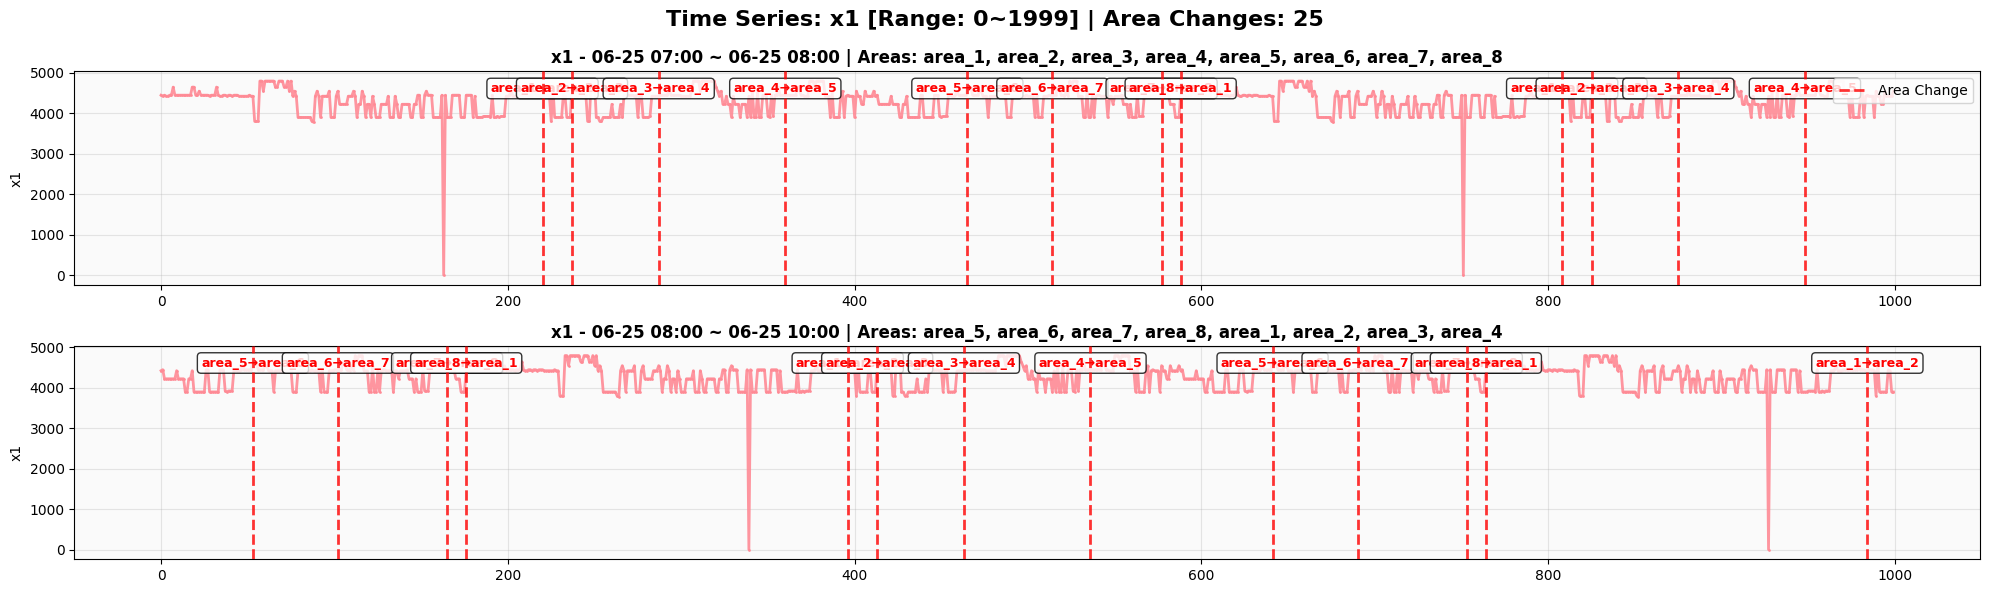

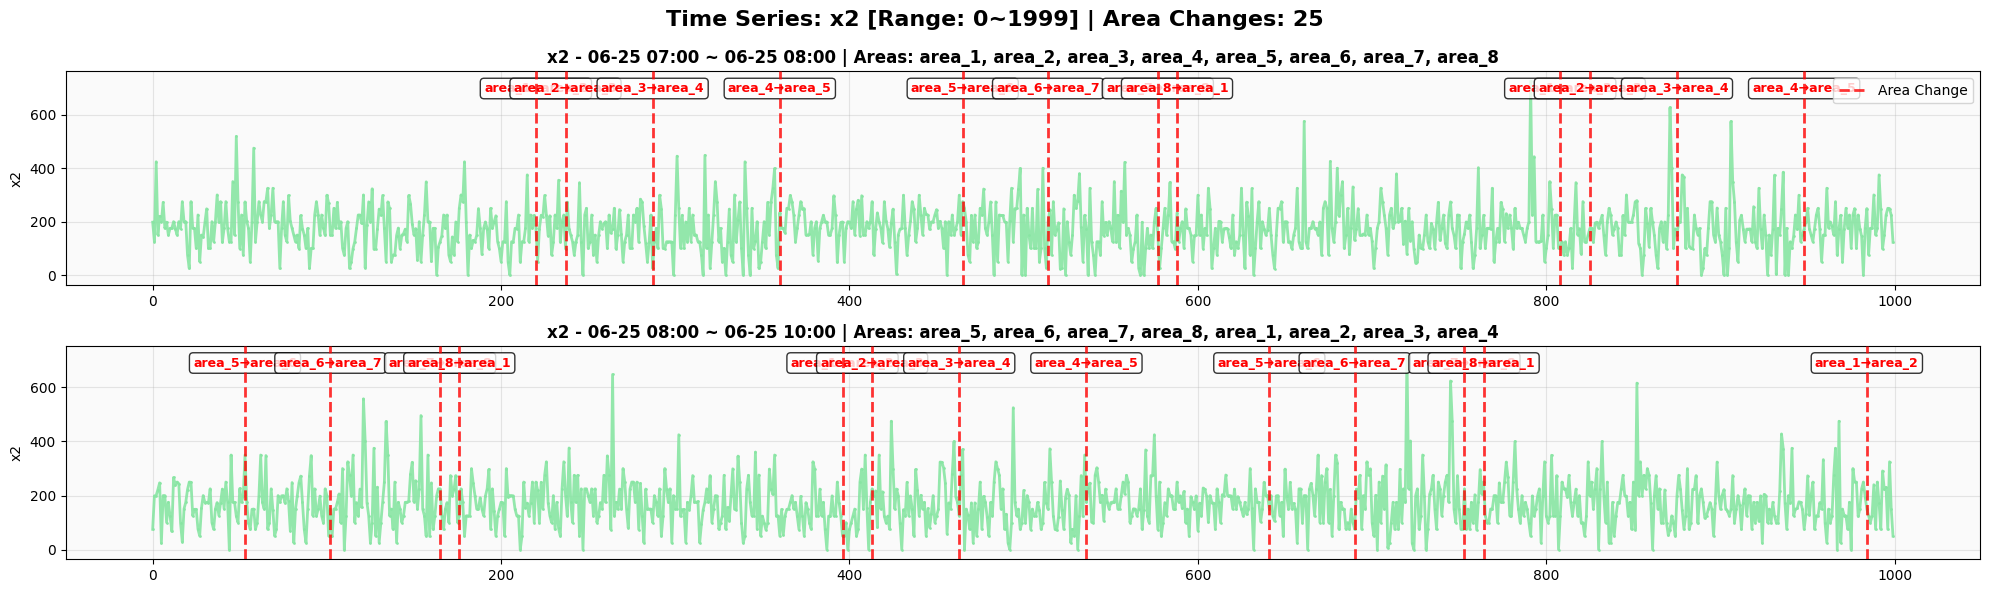

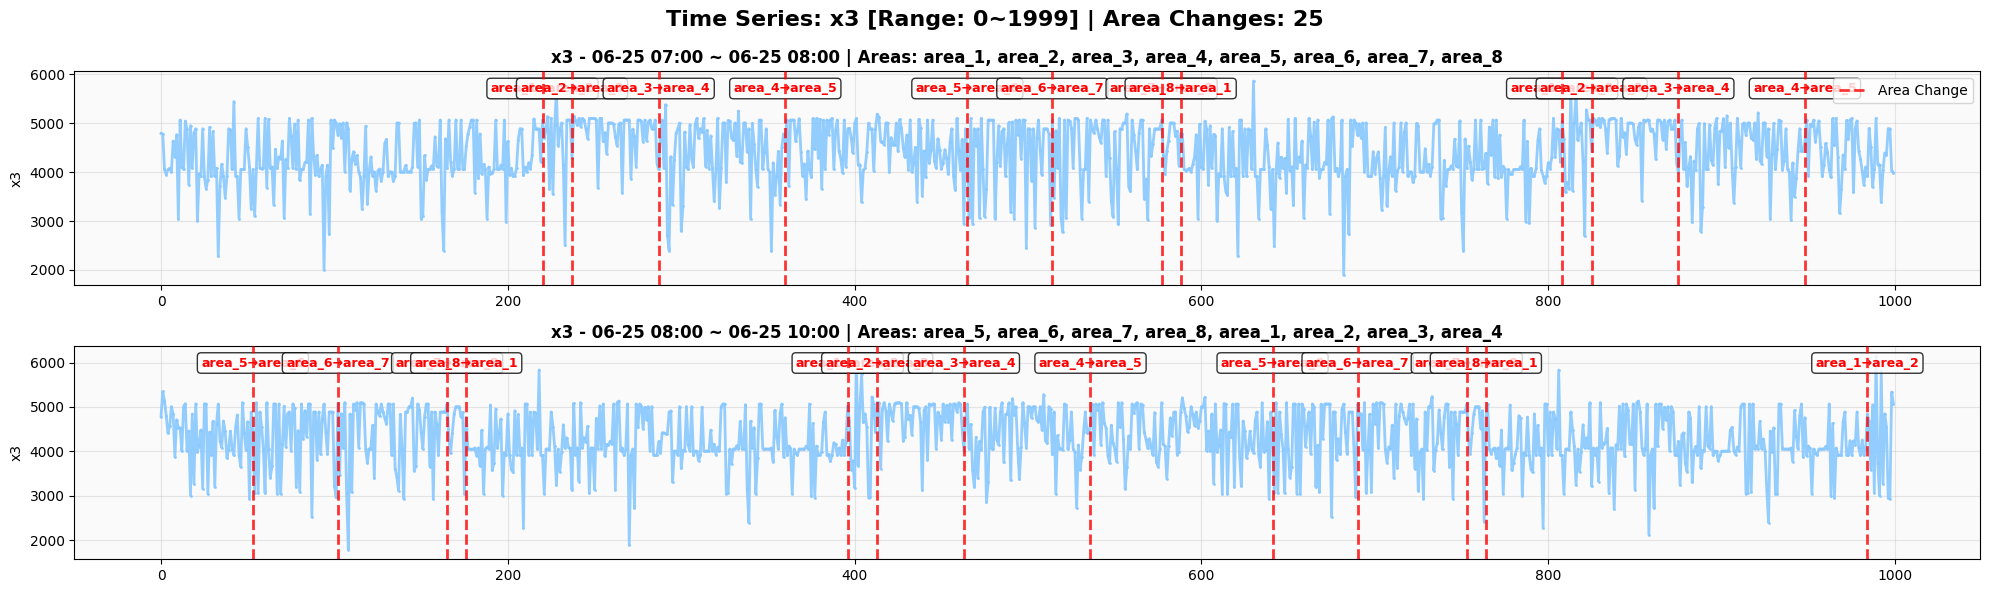

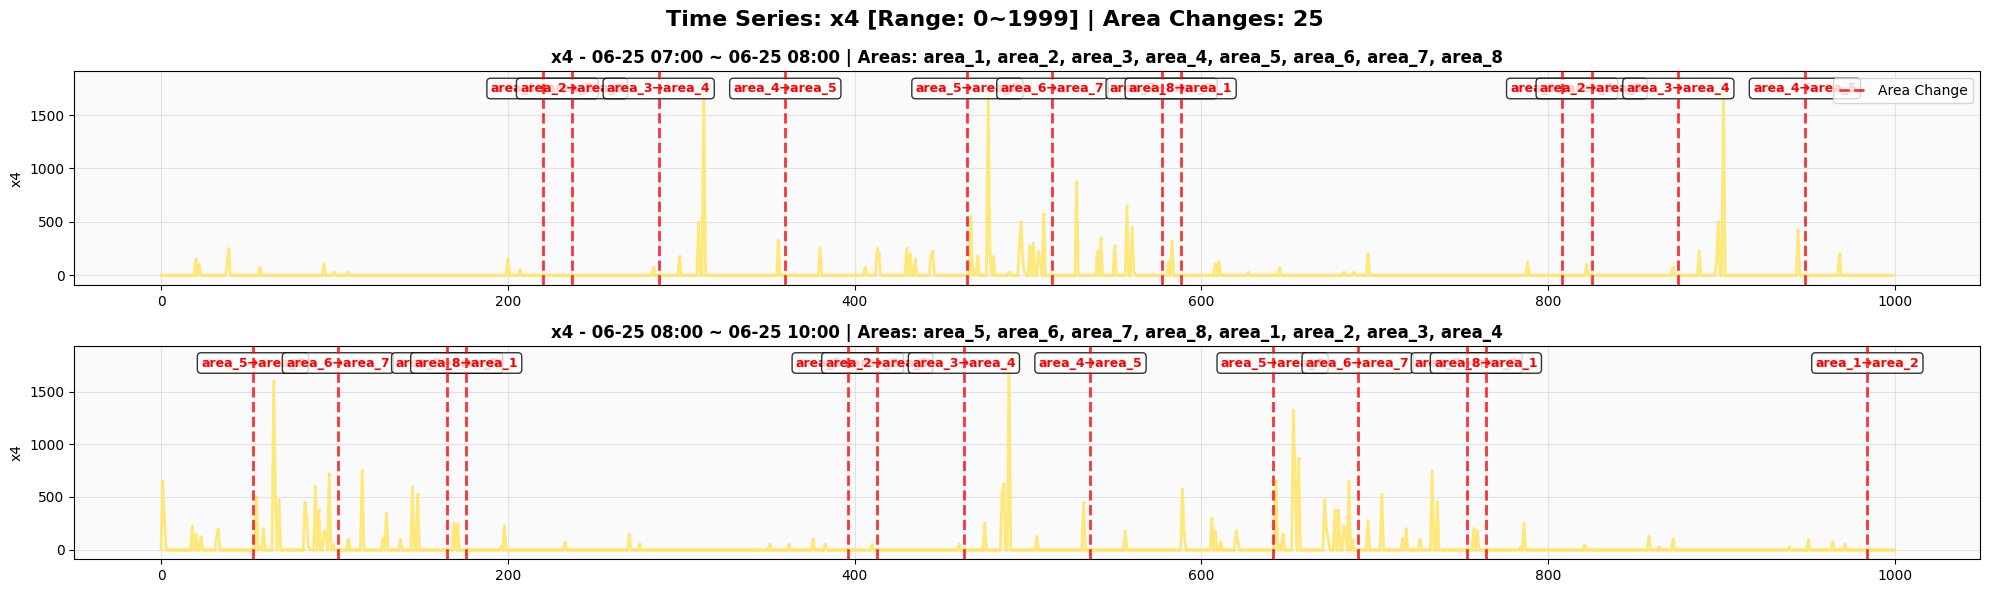

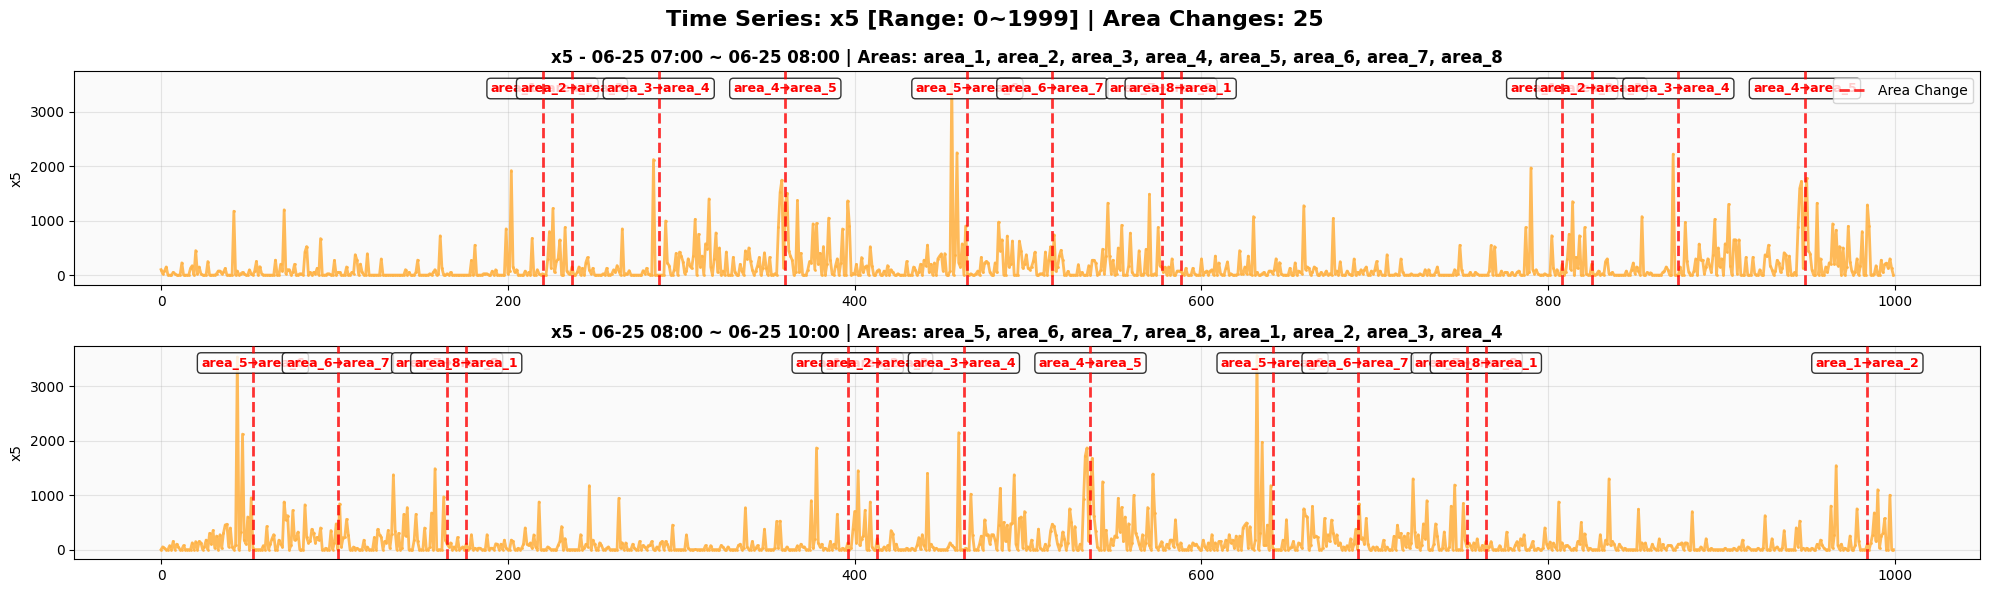

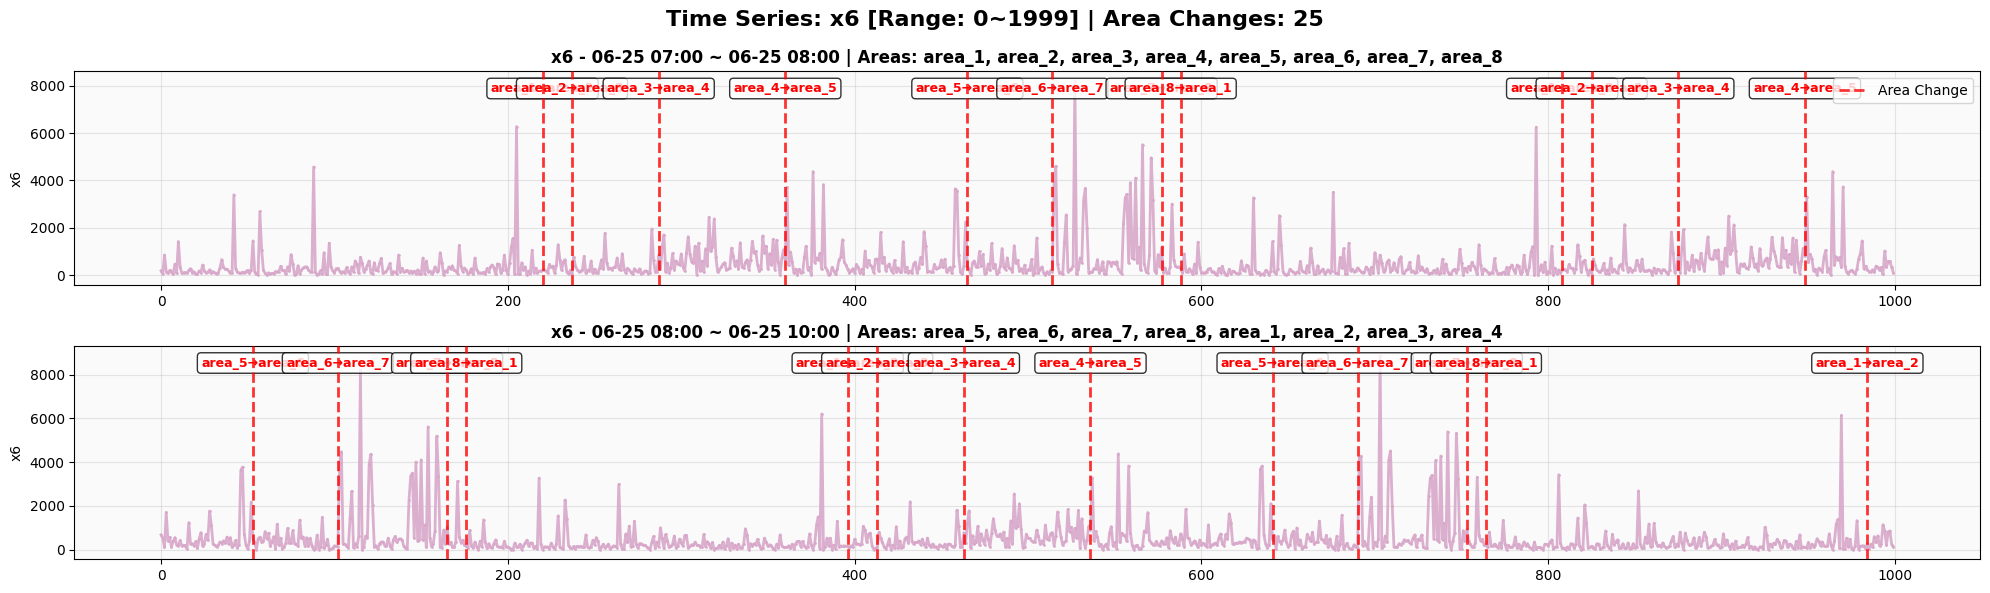

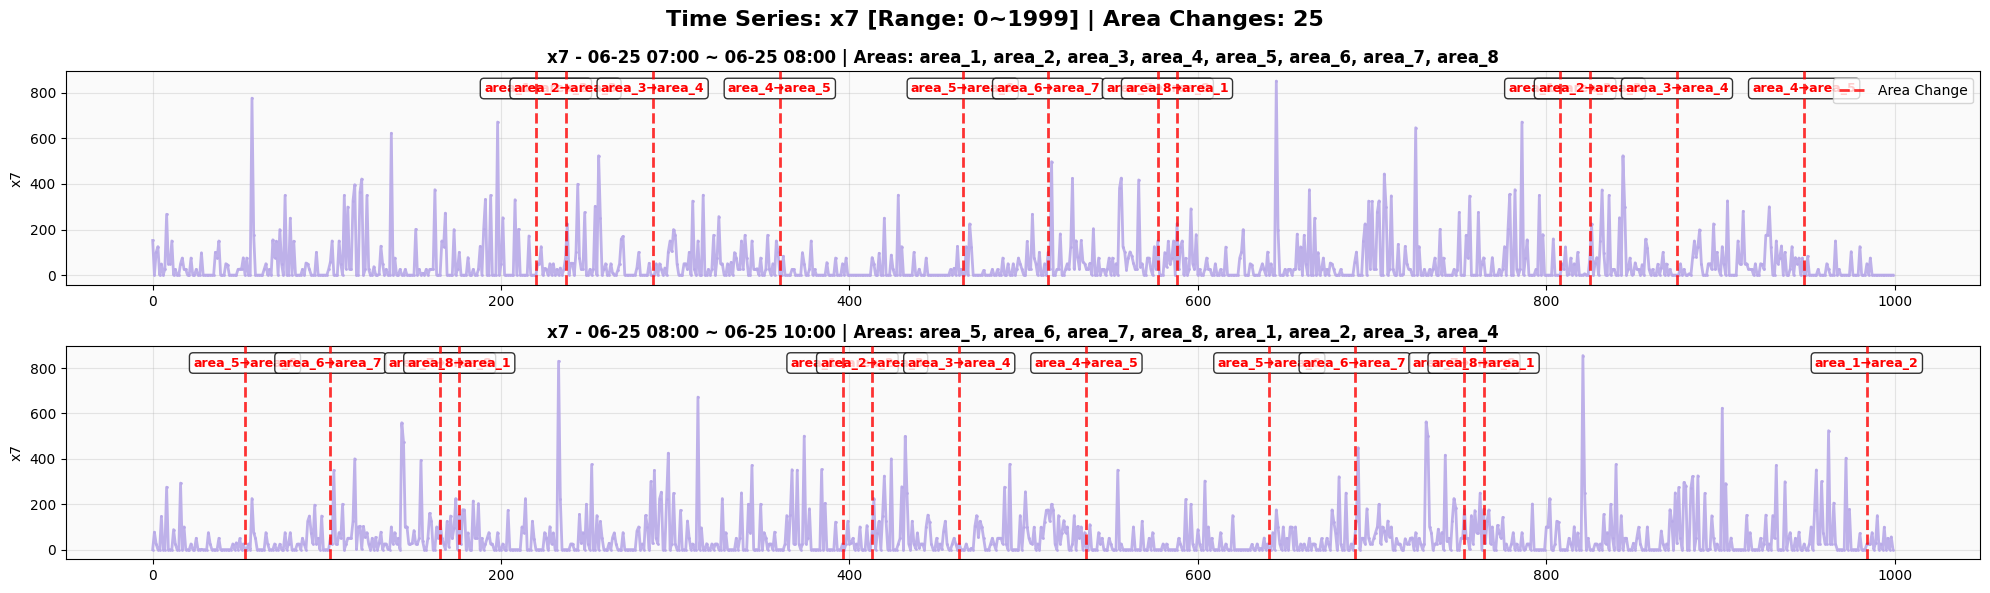

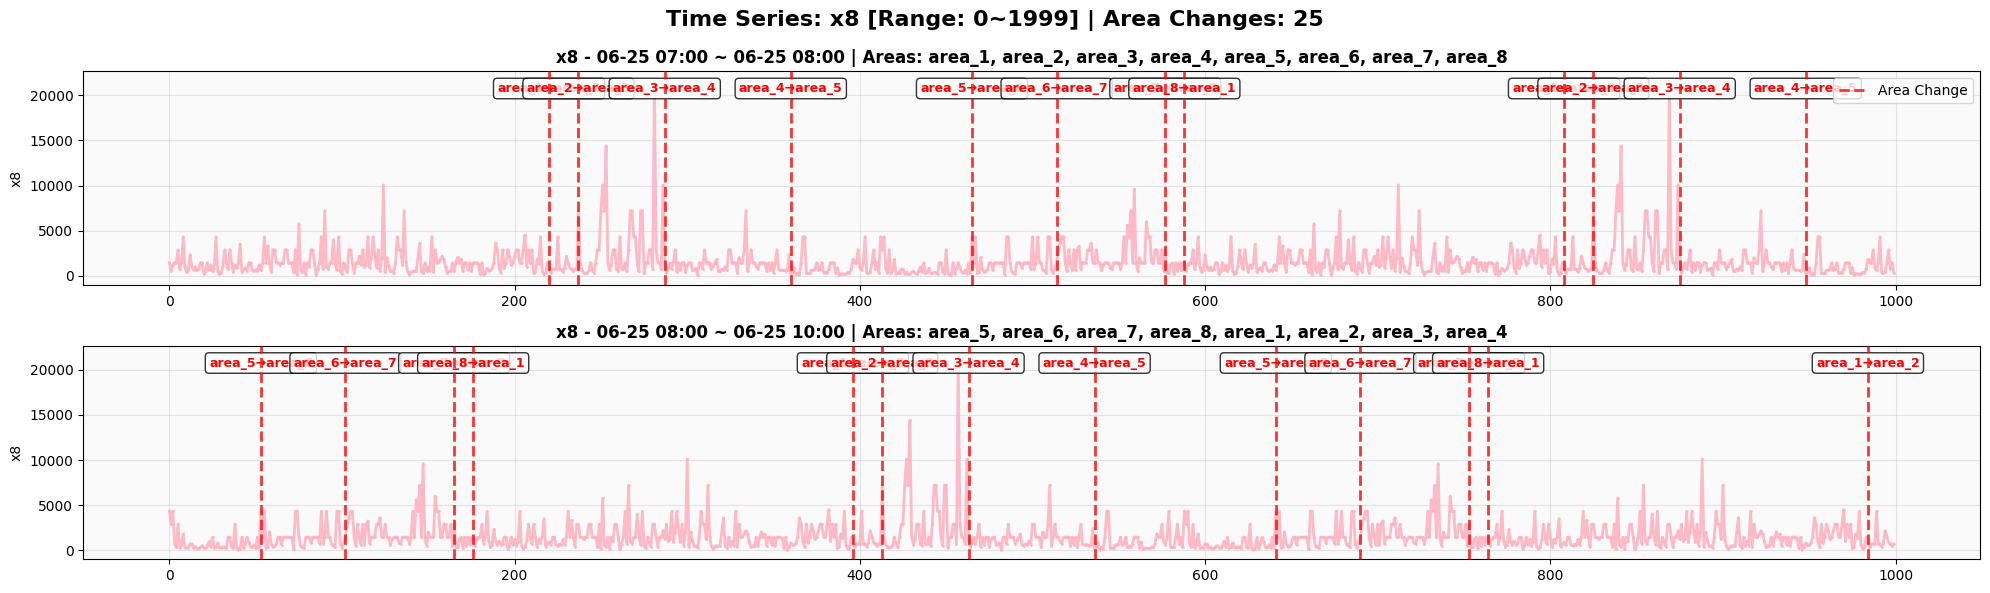

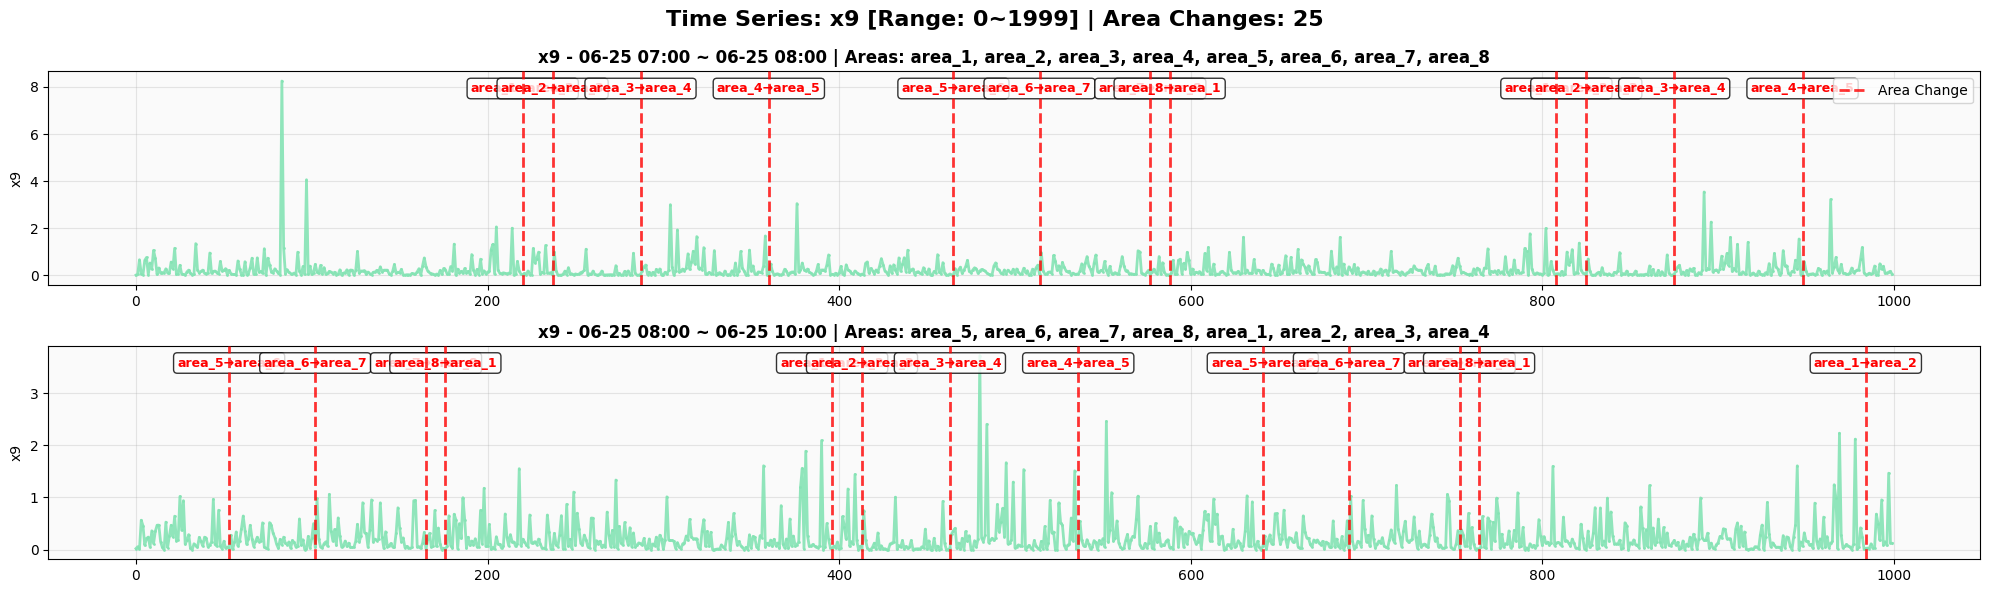


해석 방법:

■ 시계열 분석:
- 추세(trend) 확인: 시간에 따른 체계적 증가/감소
- 계절성(seasonality) 확인: 반복되는 패턴
- 이상치(outlier) 식별: 패턴에서 크게 벗어나는 극값
- 변동성(volatility) 관찰: 높은 변동과 낮은 변동 구간
- 구조적 변화(structural break) 확인: 패턴의 급격한 변화

■ Area 변화 표시:
- 빨간색 점선: Area 값이 변하는 지점
- 텍스트 박스: 이전 Area → 새로운 Area 정보
- Area 변화 시점의 데이터 패턴 변화 주목
- 공정 조건 변경이나 장비 전환과 연관 가능


In [11]:
"""전체 데이터 별 plot"""

def plot_time_series(df_sorted, variables=None, rows_per_variable=4, start_idx=None, end_idx=None, show_area_changes=True, show_area_plot=False):
    print("\n" + "="*60)
    print("2. 시계열 시각화 (찐한 파스텔) - 구간별 분할")
    print("="*60)

    if variables is None:
        variables = df_sorted.columns.drop('datetime')
    
    # datetime 컬럼 제외
    plot_variables = [var for var in variables if var != 'datetime']
    n_vars = len(plot_variables)
    
    if n_vars == 0:
        print("⚠️  플롯할 변수가 없습니다.")
        return
    
    # 데이터 범위 설정
    total_points = len(df_sorted)
    if start_idx is None:
        start_idx = 0
    if end_idx is None:
        end_idx = total_points
    
    # 인덱스 범위 검증
    start_idx = max(0, start_idx)
    end_idx = min(total_points, end_idx)
    
    if start_idx >= end_idx:
        print("⚠️  시작 인덱스가 끝 인덱스보다 크거나 같습니다.")
        return
    
    # 지정된 범위의 데이터만 사용
    df_plot = df_sorted.iloc[start_idx:end_idx].copy().reset_index(drop=True)
    plot_points = len(df_plot)
    
    print(f"📊 플롯 범위: 인덱스 {start_idx} ~ {end_idx-1} (총 {plot_points}개 포인트)")
    
    # Area 변화 지점 찾기
    area_changes = []
    if show_area_changes and 'area' in df_plot.columns:
        # area 값이 변하는 지점 찾기
        for i in range(1, len(df_plot)):
            if df_plot.loc[i, 'area'] != df_plot.loc[i-1, 'area']:
                area_changes.append(i)
        
        if area_changes:
            print(f"📍 Area 변화 지점: {len(area_changes)}개 발견")
            for i, change_idx in enumerate(area_changes):
                old_area = df_plot.loc[change_idx-1, 'area']
                new_area = df_plot.loc[change_idx, 'area']
                change_time = df_plot.loc[change_idx, 'datetime'].strftime('%m-%d %H:%M')
                print(f"  {i+1}. 인덱스 {change_idx}: {old_area} → {new_area} ({change_time})")
        else:
            print("📍 Area 변화 없음")
    elif show_area_changes:
        print("⚠️ 'area' 컬럼이 없어서 area 변화 표시를 건너뜁니다.")
    
    # 찐한 파스텔 색상 팔레트 정의
    pastel_colors = [
        '#FF8A95',  # 찐한 파스텔 핑크
        '#88E5A3',  # 찐한 파스텔 그린
        '#88C8FF',  # 찐한 파스텔 블루
        '#FFE66D',  # 찐한 파스텔 옐로우
        '#FFB347',  # 찐한 파스텔 오렌지
        '#D8A7CA',  # 찐한 파스텔 퍼플
        '#B8A9E8',  # 찐한 파스텔 라벤더
        '#FFB3C1',  # 찧한 파스텔 로즈
        '#85E3B4',  # 찧한 파스텔 민트
        '#FFCD94',  # 찧한 파스텔 피치
        '#7FCDCD',  # 찧한 파스텔 시안
        '#B8E6B8'   # 찧한 파스텔 라이트그린
    ]
    
    # 시간 범위를 구간별로 분할
    points_per_chunk = max(1, plot_points // rows_per_variable)
    
    # 각 변수별로 처리
    for var_idx, var in enumerate(plot_variables):
        
        try:
            # 파스텔 색상 선택
            color = pastel_colors[var_idx % len(pastel_colors)]
            
            # 원본 스케일 figure 생성
            fig, axes = plt.subplots(rows_per_variable, 1, figsize=(20, 3*rows_per_variable))
            
            # 단일 행인 경우 리스트로 변환
            if rows_per_variable == 1:
                axes = [axes]
            
            # 각 시간 구간별로 플롯
            for row in range(rows_per_variable):
                chunk_start_idx = row * points_per_chunk
                chunk_end_idx = min((row + 1) * points_per_chunk, plot_points)
                
                if chunk_start_idx >= plot_points:
                    break
                
                # 해당 구간의 데이터 추출
                chunk_df = df_plot.iloc[chunk_start_idx:chunk_end_idx]
                
                # 시간 범위 정보 (제목용)
                start_time = chunk_df['datetime'].iloc[0].strftime('%m-%d %H:%M')
                end_time = chunk_df['datetime'].iloc[-1].strftime('%m-%d %H:%M')
                
                # 실제 원본 인덱스 정보
                actual_start = start_idx + chunk_start_idx
                actual_end = start_idx + chunk_end_idx - 1
                
                # Area 정보 추가
                if 'area' in chunk_df.columns:
                    chunk_areas = chunk_df['area'].unique()
                    if len(chunk_areas) == 1:
                        area_info = f"Area: {chunk_areas[0]}"
                    else:
                        area_info = f"Areas: {', '.join(map(str, chunk_areas))}"
                else:
                    area_info = ""
                
                # x축을 range로 설정 (0부터 시작)
                x_range = range(len(chunk_df))
                
                # 원본 스케일 플롯
                axes[row].plot(x_range, chunk_df[var], 
                              linewidth=2, alpha=0.9, color=color, marker='o', markersize=1)
                title = f"{var} - {start_time} ~ {end_time}"
                if area_info:
                    title += f" | {area_info}"
                axes[row].set_title(title, fontsize=12, fontweight='bold')
                axes[row].set_ylabel(var)
                axes[row].grid(True, alpha=0.3)
                axes[row].set_facecolor('#FAFAFA')
                
                # Area 변화 지점에 세로선 추가
                if show_area_changes and area_changes:
                    for change_idx in area_changes:
                        # 현재 chunk 범위 내에 있는 변화 지점만 처리
                        if chunk_start_idx <= change_idx < chunk_end_idx:
                            # chunk 내에서의 상대적 위치 계산
                            relative_pos = change_idx - chunk_start_idx
                            
                            # 변화 정보
                            old_area = df_plot.loc[change_idx-1, 'area'] if change_idx > 0 else 'N/A'
                            new_area = df_plot.loc[change_idx, 'area']
                            
                            # 세로선 추가 (빨간색, 점선)
                            axes[row].axvline(x=relative_pos, color='red', linestyle='--', 
                                            linewidth=2, alpha=0.8, zorder=10)
                            
                            # 변화 지점에 텍스트 추가 (상단에)
                            if show_area_plot:
                                y_range = axes[row].get_ylim()
                                text_y = y_range[1] - (y_range[1] - y_range[0]) * 0.05
                                
                                # 화살표와 함께 텍스트 추가
                                axes[row].annotate(f'{old_area}→{new_area}', 
                                                 xy=(relative_pos, text_y),
                                                 xytext=(relative_pos, text_y),
                                                 fontsize=9, ha='center', va='top',
                                                 bbox=dict(boxstyle="round,pad=0.3", 
                                                          facecolor='white', alpha=0.8),
                                                 color='red', fontweight='bold')
            
            # 범례 추가 (area 변화가 있는 경우)
            if show_area_changes and area_changes:
                # 첫 번째 subplot에 범례 추가
                axes[0].plot([], [], color='red', linestyle='--', linewidth=2, 
                           label='Area Change', alpha=0.8)
                axes[0].legend(loc='upper right', fontsize=10)
            
            # suptitle에 area 변화 개수 정보 추가
            area_change_info = f" | Area Changes: {len(area_changes)}" if area_changes else ""
            
            # 레이아웃 조정 및 표시
            fig.suptitle(f"Time Series: {var} [Range: {start_idx}~{end_idx-1}]{area_change_info}", 
                        fontsize=16, fontweight='bold')
            fig.tight_layout()
            plt.figure(fig.number)
            plt.show()
            
        except Exception as e:
            print(f"⚠️  {var} 시각화 중 오류 발생: {e}")
            continue
    
    print("\n" + "="*60)
    print("해석 방법:")
    print("\n■ 시계열 분석:")
    print("- 추세(trend) 확인: 시간에 따른 체계적 증가/감소")
    print("- 계절성(seasonality) 확인: 반복되는 패턴")
    print("- 이상치(outlier) 식별: 패턴에서 크게 벗어나는 극값")
    print("- 변동성(volatility) 관찰: 높은 변동과 낮은 변동 구간")
    print("- 구조적 변화(structural break) 확인: 패턴의 급격한 변화")
    if show_area_changes:
        print("\n■ Area 변화 표시:")
        print("- 빨간색 점선: Area 값이 변하는 지점")
        if show_area_plot:
            print("- 텍스트 박스: 이전 Area → 새로운 Area 정보")
        print("- Area 변화 시점의 데이터 패턴 변화 주목")
        print("- 공정 조건 변경이나 장비 전환과 연관 가능")

# 함수 호출 예시
plot_time_series(df_sorted, variables=numeric_features, rows_per_variable=2, 
                start_idx=0, end_idx=2000, show_area_changes=True, show_area_plot=True)


🎯 Operation별 다변수 시계열 시각화
📋 분석할 Operations: ['oper_221', 'oper_222']
📋 플롯 방식: 변수별 별도 plot

📊 Operation 1/2: oper_221
📊 필터링된 데이터 수: 48개
📋 선택된 변수: ['x2', 'x3', 'x4', 'x5']
📊 플롯 범위: 인덱스 0 ~ 47 (총 48개 포인트)
📋 실제 사용할 변수: ['x2', 'x3', 'x4', 'x5']
📈 변수별 개별 플롯 생성 중...


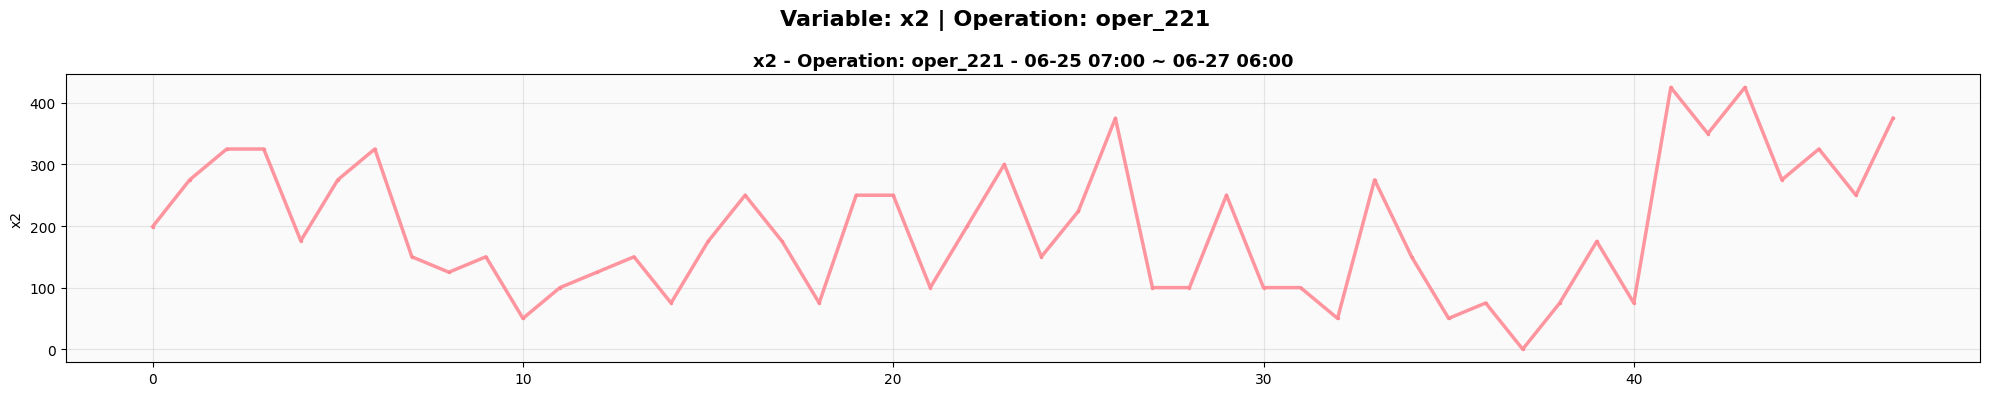

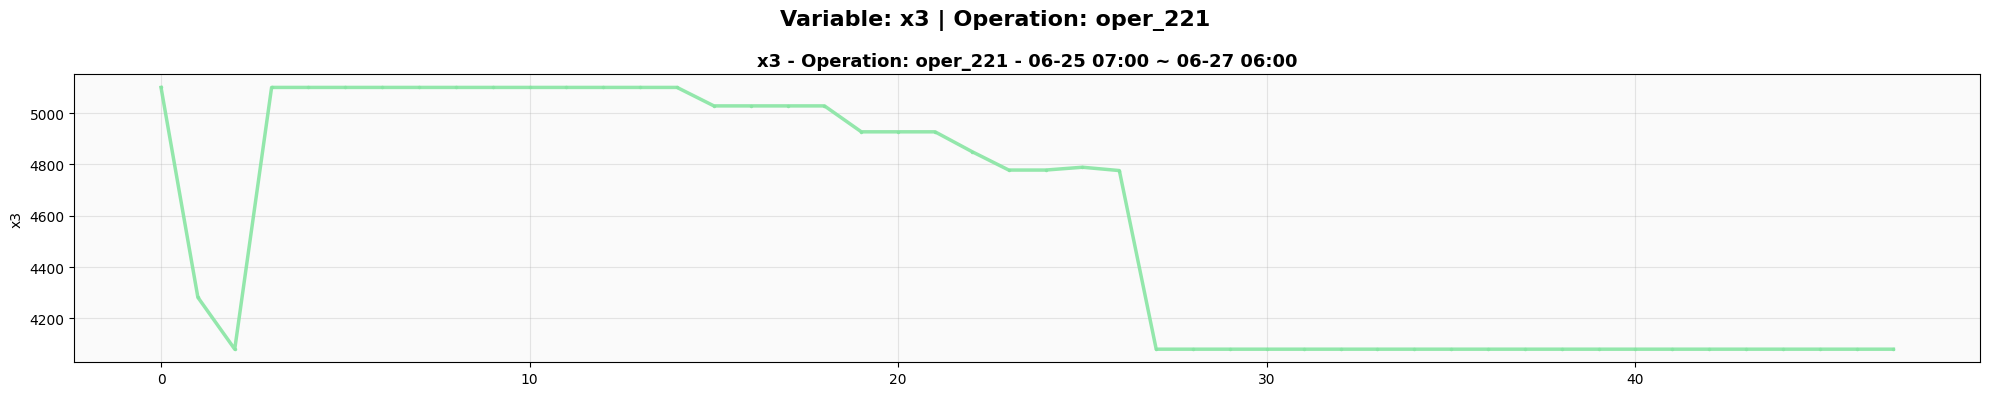

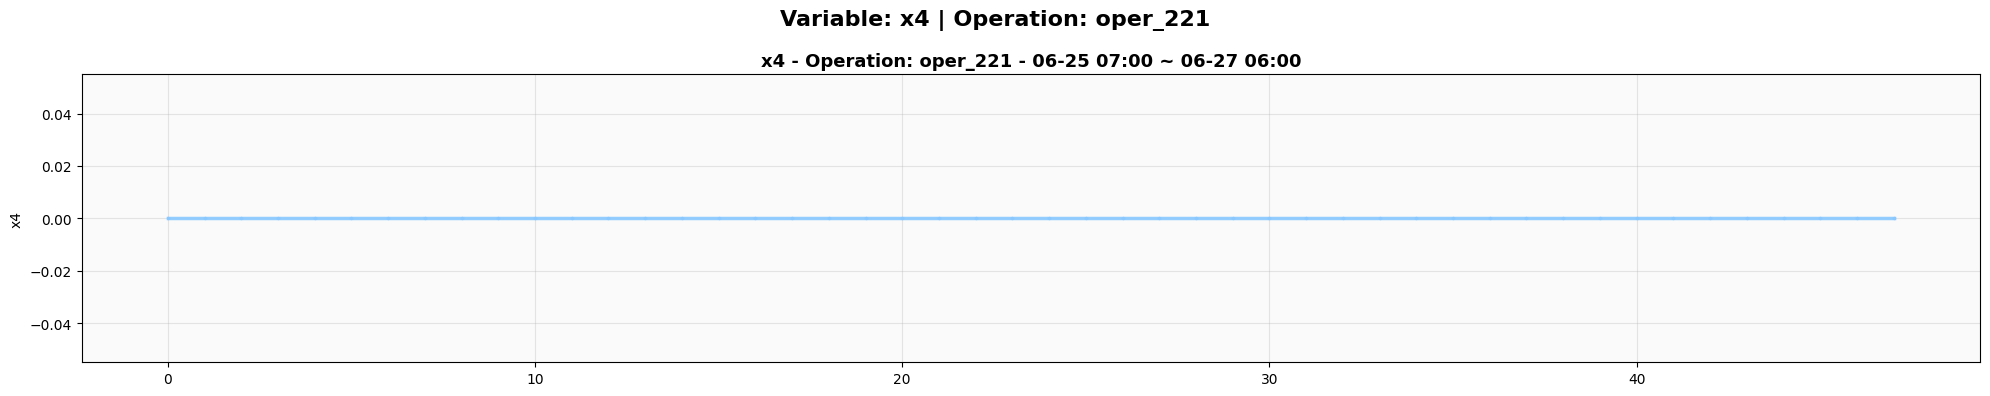

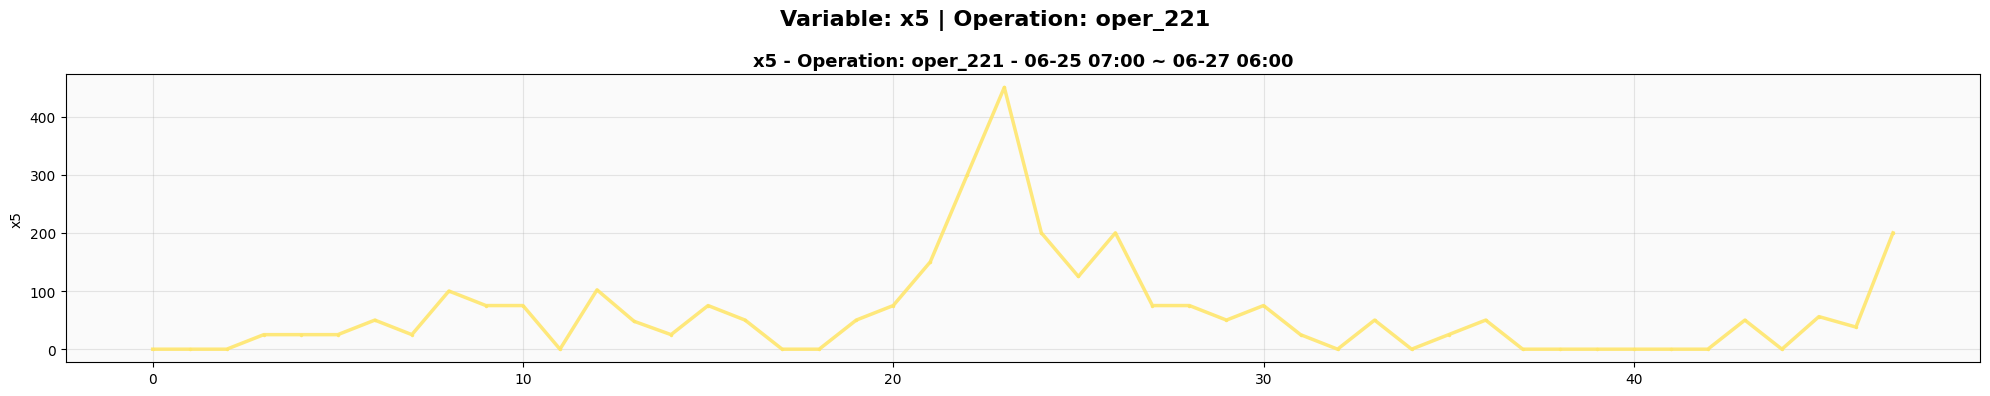


📊 oper_221 Operation 변수별 통계 요약:
--------------------------------------------------
x2: μ=194.77, σ=109.50, 범위=[0.00, 425.00]
x3: μ=4566.79, σ=472.50, 범위=[4080.00, 5100.00]
x4: μ=0.00, σ=0.00, 범위=[0.00, 0.00]
x5: μ=62.90, σ=86.21, 범위=[0.00, 450.00]

📊 Operation 2/2: oper_222
📊 필터링된 데이터 수: 49개
📊 플롯 범위: 인덱스 0 ~ 48 (총 49개 포인트)
📋 실제 사용할 변수: ['x2', 'x3', 'x4', 'x5']
📈 변수별 개별 플롯 생성 중...


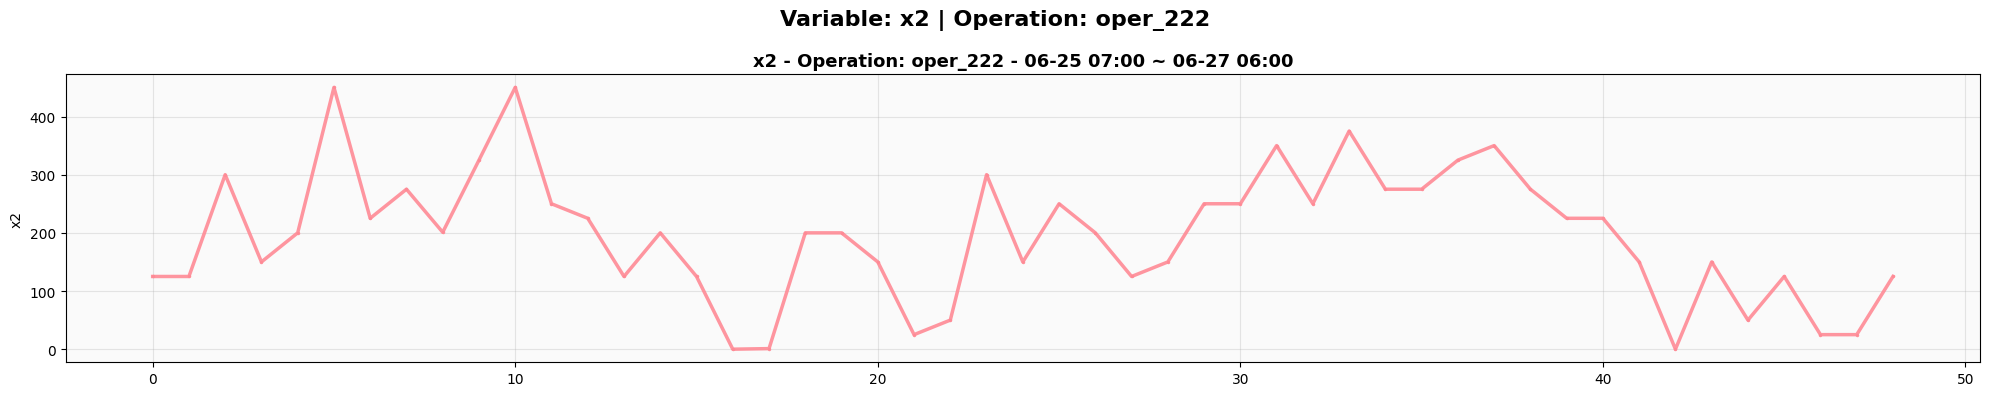

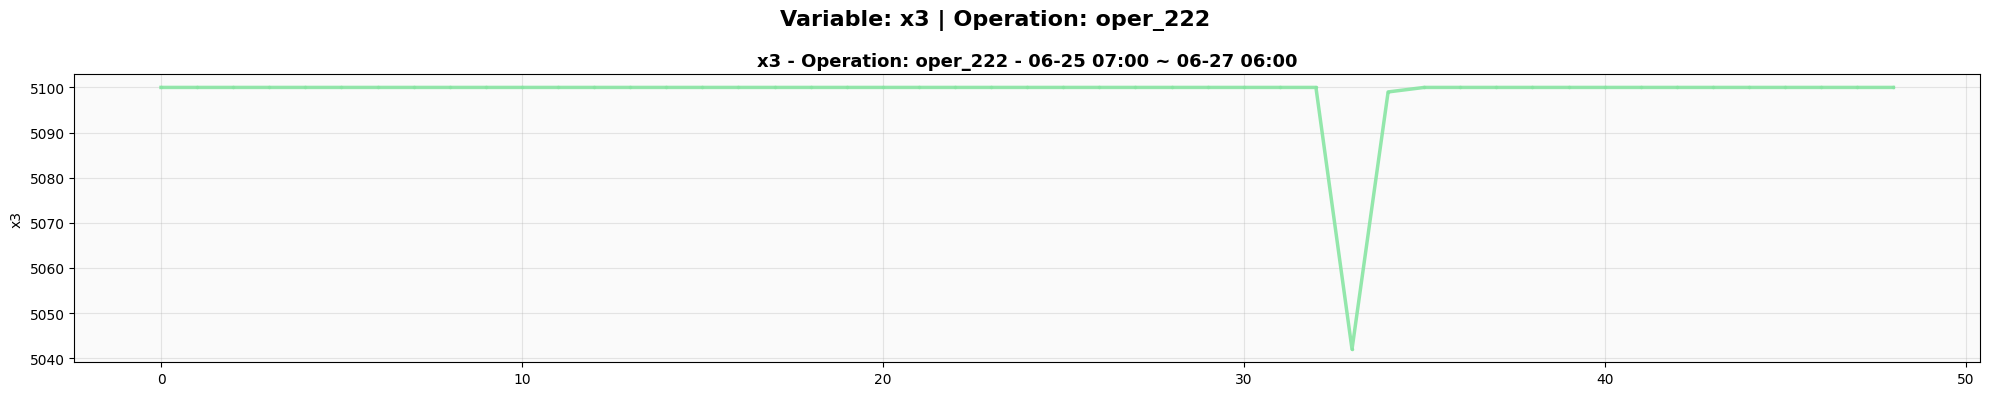

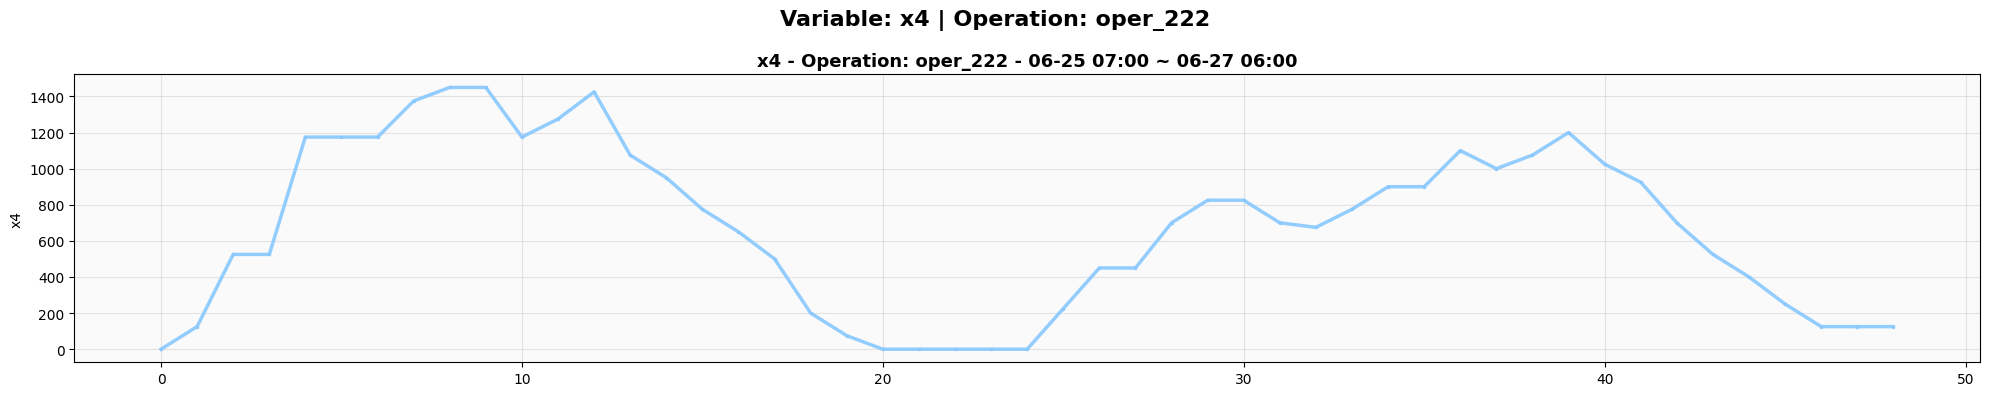

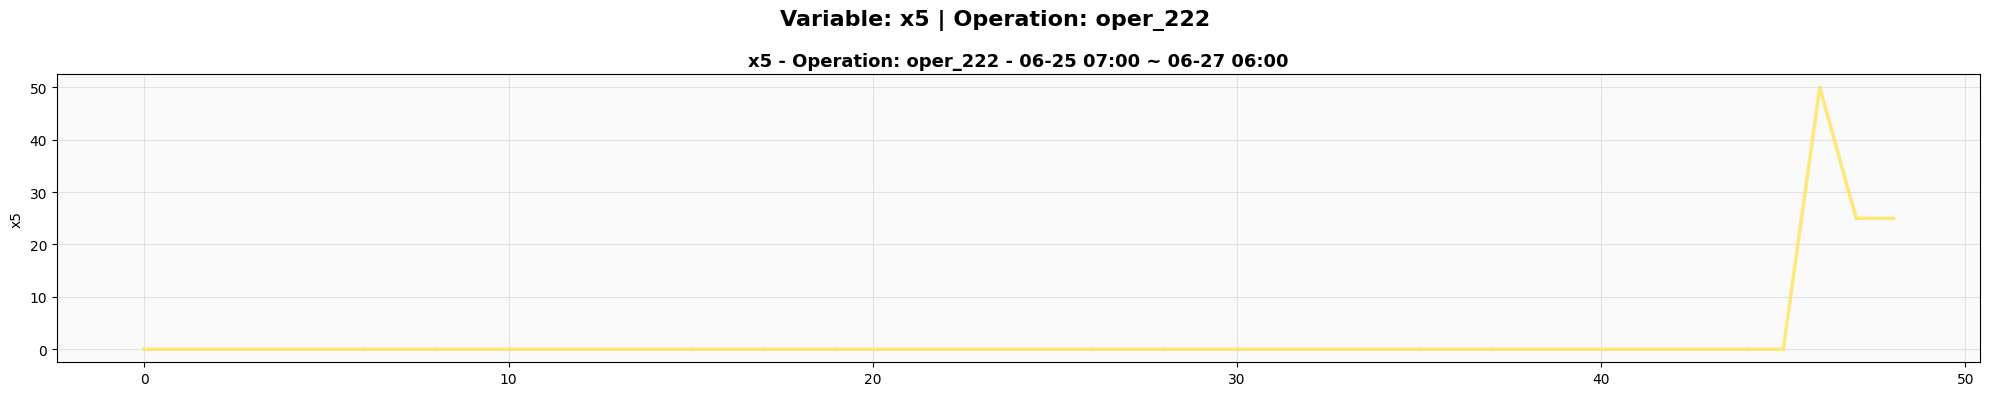


📊 oper_222 Operation 변수별 통계 요약:
--------------------------------------------------
x2: μ=196.47, σ=111.77, 범위=[0.00, 450.00]
x3: μ=5098.80, σ=8.28, 범위=[5042.00, 5100.00]
x4: μ=675.00, σ=459.00, 범위=[0.00, 1450.00]
x5: μ=2.04, σ=8.59, 범위=[0.00, 50.00]

해석 방법:

■ 변수별 개별 분석:
- 각 변수의 고유한 패턴과 특성을 독립적으로 관찰
- 변수별 세부 변동 사항을 더 명확히 확인
- 개별 변수의 이상치나 특이점 식별 용이
- 변수별 스케일에 최적화된 시각화

■ Operation별 비교 분석:
- 동일한 변수들이 서로 다른 operation에서 어떻게 다르게 나타나는지 비교
- Operation별 변수 간 상관관계 패턴 차이 확인
- 최적 operation 조건 탐색을 위한 패턴 분석


In [12]:
"""공정 및 변수별 plot"""

def plot_operation_variables(df_sorted, oper=None, variables=None, rows_per_variable=2, 
                           start_idx=None, end_idx=None, multi_variable_in_one_plot=True):
    """
    특정 operation(s) 내에서 선택한 변수들을 시계열 플롯하는 함수
    
    Parameters:
    - df_sorted: 정렬된 데이터프레임
    - oper: 분석할 operation (문자열) 또는 operation 리스트
    - variables: 플롯할 변수 리스트
    - rows_per_variable: 구간별 분할 행 수
    - start_idx, end_idx: 데이터 범위
    - multi_variable_in_one_plot: True면 하나의 plot에 모든 변수, False면 변수별 별도 plot
    """
    
    print("\n" + "="*60)
    print(f"🎯 Operation별 다변수 시계열 시각화")
    print("="*60)
    
    # Operation 리스트 처리
    if oper is None:
        oper_list = [None]
    elif isinstance(oper, str):
        oper_list = [oper]
    elif isinstance(oper, list):
        oper_list = oper
    else:
        print("⚠️ oper 매개변수는 문자열, 리스트, 또는 None이어야 합니다.")
        return
    
    print(f"📋 분석할 Operations: {oper_list}")
    print(f"📋 플롯 방식: {'하나의 plot에 모든 변수' if multi_variable_in_one_plot else '변수별 별도 plot'}")
    
    # 사용 가능한 operation 확인
    if 'oper' in df_sorted.columns:
        available_ops = df_sorted['oper'].unique().tolist()
        valid_oper_list = []
        
        for op in oper_list:
            if op is None:
                valid_oper_list.append(None)
            elif op in available_ops:
                valid_oper_list.append(op)
            else:
                print(f"⚠️ Operation '{op}'이 데이터에 없습니다. 건너뜁니다.")
        
        if not valid_oper_list:
            print(f"사용 가능한 operations: {available_ops[:10]}...")
            return
        
        oper_list = valid_oper_list
    else:
        print("⚠️ 'oper' 컬럼이 없어서 전체 데이터를 사용합니다.")
        oper_list = [None]
    
    # 변수별 색상 팔레트 정의
    variable_colors = [
        '#FF8A95', '#88E5A3', '#88C8FF', '#FFE66D', '#FFB347',
        '#D8A7CA', '#B8A9E8', '#FFB3C1', '#85E3B4', '#FFCD94'
    ]
    
    # 각 operation별로 순차적으로 처리
    for op_idx, current_oper in enumerate(oper_list):
        print(f"\n{'='*40}")
        print(f"📊 Operation {op_idx+1}/{len(oper_list)}: {current_oper if current_oper else 'ALL'}")
        print(f"{'='*40}")
        
        # 현재 operation으로 데이터 필터링
        if current_oper is not None:
            df_filtered = df_sorted[df_sorted['oper'] == current_oper].copy()
            print(f"📊 필터링된 데이터 수: {len(df_filtered):,}개")
        else:
            df_filtered = df_sorted.copy()
            current_oper = "ALL"
            print("📊 전체 데이터 사용")
        
        if len(df_filtered) == 0:
            print(f"⚠️ Operation '{current_oper}'에 해당하는 데이터가 없습니다.")
            continue
        
        # 변수 설정 (첫 번째 operation에서만)
        if op_idx == 0:
            if variables is None:
                numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
                variables = [col for col in numeric_cols if col not in ['datetime']][:3]
                print(f"📋 자동 선택된 변수: {variables}")
            else:
                available_vars = [col for col in variables if col in df_filtered.columns]
                if not available_vars:
                    print(f"⚠️ 지정된 변수들이 데이터에 없습니다.")
                    return
                variables = available_vars
                print(f"📋 선택된 변수: {variables}")
        
        # 데이터 범위 설정
        total_points = len(df_filtered)
        if start_idx is None:
            current_start_idx = 0
        else:
            current_start_idx = start_idx
        if end_idx is None:
            current_end_idx = total_points
        else:
            current_end_idx = end_idx
        
        current_start_idx = max(0, current_start_idx)
        current_end_idx = min(total_points, current_end_idx)
        
        if current_start_idx >= current_end_idx:
            print("⚠️ 시작 인덱스가 끝 인덱스보다 크거나 같습니다.")
            continue
        
        # 지정된 범위의 데이터만 사용
        df_plot = df_filtered.iloc[current_start_idx:current_end_idx].copy().reset_index(drop=True)
        plot_points = len(df_plot)
        
        print(f"📊 플롯 범위: 인덱스 {current_start_idx} ~ {current_end_idx-1} (총 {plot_points}개 포인트)")
        
        # 시간 범위를 구간별로 분할
        points_per_chunk = max(1, plot_points // rows_per_variable)
        
        # 실제 사용할 변수들 (데이터에 존재하는 변수들만)
        actual_variables = [var for var in variables if var in df_plot.columns]
        
        if not actual_variables:
            print(f"⚠️ Operation '{current_oper}'에서 사용할 수 있는 변수가 없습니다.")
            continue
        
        print(f"📋 실제 사용할 변수: {actual_variables}")
        
        try:
            if multi_variable_in_one_plot:
                # 하나의 plot에 모든 변수를 한번에 표시
                print("📈 다변수 통합 플롯 생성 중...")
                
                fig, axes = plt.subplots(rows_per_variable, 1, figsize=(24, 4*rows_per_variable))
                
                if rows_per_variable == 1:
                    axes = [axes]
                
                # 각 시간 구간별로 플롯
                for row in range(rows_per_variable):
                    chunk_start_idx = row * points_per_chunk
                    chunk_end_idx = min((row + 1) * points_per_chunk, plot_points)
                    
                    if chunk_start_idx >= plot_points:
                        break
                    
                    chunk_df = df_plot.iloc[chunk_start_idx:chunk_end_idx]
                    start_time = chunk_df['datetime'].iloc[0].strftime('%m-%d %H:%M')
                    end_time = chunk_df['datetime'].iloc[-1].strftime('%m-%d %H:%M')
                    
                    x_range = range(len(chunk_df))
                    
                    # 각 변수별로 플롯
                    for var_idx, var in enumerate(actual_variables):
                        color = variable_colors[var_idx % len(variable_colors)]
                        
                        # 원본 스케일 플롯
                        axes[row].plot(x_range, chunk_df[var], 
                                      linewidth=2.5, alpha=0.8, color=color, 
                                      marker='o', markersize=1.5, label=var)
                    
                    # 스타일 설정
                    title = f"Operation: {current_oper} - {start_time} ~ {end_time}"
                    axes[row].set_title(title, fontsize=13, fontweight='bold')
                    axes[row].set_ylabel("Values")
                    axes[row].grid(True, alpha=0.3)
                    axes[row].set_facecolor('#FAFAFA')
                    axes[row].legend(loc='upper right', fontsize=10)
                
                # 전체 제목 설정
                variables_str = ', '.join(actual_variables)
                fig.suptitle(f"Multi-Variable Time Series: {current_oper} | Variables: {variables_str}", 
                           fontsize=16, fontweight='bold')
                fig.tight_layout()
                plt.figure(fig.number)
                plt.show()
                
            else:
                # 변수별로 별도의 plot 생성
                print("📈 변수별 개별 플롯 생성 중...")
                
                for var_idx, var in enumerate(actual_variables):
                    color = variable_colors[var_idx % len(variable_colors)]
                    
                    # 개별 변수 figure
                    fig, axes = plt.subplots(rows_per_variable, 1, figsize=(20, 4*rows_per_variable))
                    
                    if rows_per_variable == 1:
                        axes = [axes]
                    
                    # 각 시간 구간별로 플롯
                    for row in range(rows_per_variable):
                        chunk_start_idx = row * points_per_chunk
                        chunk_end_idx = min((row + 1) * points_per_chunk, plot_points)
                        
                        if chunk_start_idx >= plot_points:
                            break
                        
                        chunk_df = df_plot.iloc[chunk_start_idx:chunk_end_idx]
                        start_time = chunk_df['datetime'].iloc[0].strftime('%m-%d %H:%M')
                        end_time = chunk_df['datetime'].iloc[-1].strftime('%m-%d %H:%M')
                        
                        x_range = range(len(chunk_df))
                        
                        # 원본 스케일 플롯
                        axes[row].plot(x_range, chunk_df[var], 
                                      linewidth=2.5, alpha=0.9, color=color, 
                                      marker='o', markersize=1.5)
                        
                        # 스타일 설정
                        title = f"{var} - Operation: {current_oper} - {start_time} ~ {end_time}"
                        axes[row].set_title(title, fontsize=13, fontweight='bold')
                        axes[row].set_ylabel(var)
                        axes[row].grid(True, alpha=0.3)
                        axes[row].set_facecolor('#FAFAFA')
                    
                    # 개별 변수 제목 설정
                    fig.suptitle(f"Variable: {var} | Operation: {current_oper}", 
                               fontsize=16, fontweight='bold')
                    fig.tight_layout()
                    plt.figure(fig.number)
                    plt.show()
                    
        except Exception as e:
            print(f"⚠️ Operation '{current_oper}' 시각화 중 오류 발생: {e}")
            import traceback
            traceback.print_exc()
            continue
        
        # 변수별 통계 요약
        print(f"\n📊 {current_oper} Operation 변수별 통계 요약:")
        print("-" * 50)
        for var in actual_variables:
            var_data = df_plot[var].dropna()
            print(f"{var}: μ={var_data.mean():.2f}, σ={var_data.std():.2f}, "
                  f"범위=[{var_data.min():.2f}, {var_data.max():.2f}]")
    
    print("\n" + "="*60)
    print("해석 방법:")
    if multi_variable_in_one_plot:
        print("\n■ 다변수 통합 분석:")
        print("- 여러 변수 간의 상관관계와 동조성 관찰")
        print("- 변수별 변동 패턴의 유사성/차이점 비교")
        print("- 특정 시점에서 여러 변수의 동시 변화 확인")
        print("- 변수 간 상대적 스케일 차이 고려하여 해석")
    else:
        print("\n■ 변수별 개별 분석:")
        print("- 각 변수의 고유한 패턴과 특성을 독립적으로 관찰")
        print("- 변수별 세부 변동 사항을 더 명확히 확인")
        print("- 개별 변수의 이상치나 특이점 식별 용이")
        print("- 변수별 스케일에 최적화된 시각화")
    print("\n■ Operation별 비교 분석:")
    print("- 동일한 변수들이 서로 다른 operation에서 어떻게 다르게 나타나는지 비교")
    print("- Operation별 변수 간 상관관계 패턴 차이 확인")
    print("- 최적 operation 조건 탐색을 위한 패턴 분석")


# 사용 예시들:

# 1. 하나의 plot에 모든 변수 표시 (기본값)
plot_operation_variables(df_sorted, 
                        oper=['oper_221', 'oper_222'], 
                        variables=['x2', 'x3', 'x4', 'x5'],
                        rows_per_variable=1,
                        multi_variable_in_one_plot=False)


3. 자기상관 종합 분석

--- x1 자기상관 분석 ---


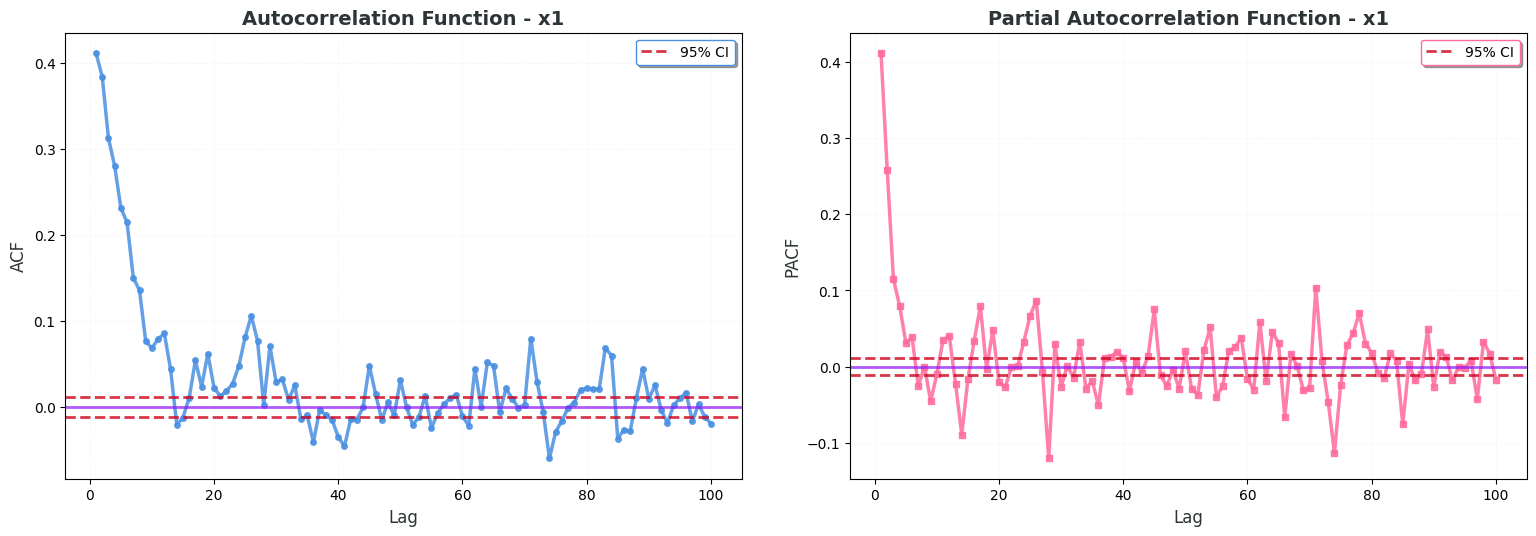

유의한 자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  8  9 10]
유의한 지연의 개수: 71
유의한 편자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  9 11 12]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 1에서 발생 (상관계수: 0.412)
- 1차 자기상관 (0.412) → 보통 수준의 시계열 의존성

--- x2 자기상관 분석 ---


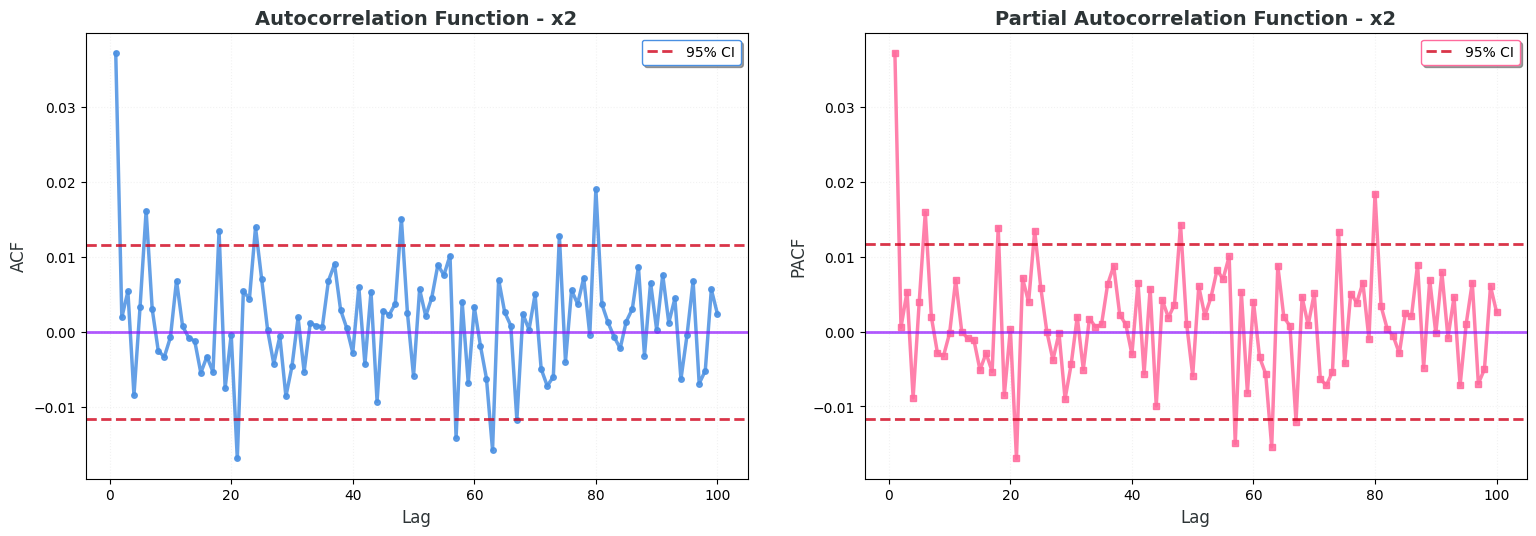

유의한 자기상관을 보이는 지연(lag): [ 1  6 18 21 24 48 57 63 67 74]
유의한 지연의 개수: 11
유의한 편자기상관을 보이는 지연(lag): [ 1  6 18 21 24 48 57 63 67 74]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 1에서 발생 (상관계수: 0.037)
- 1차 자기상관 (0.037) → 보통 수준의 시계열 의존성

--- x3 자기상관 분석 ---


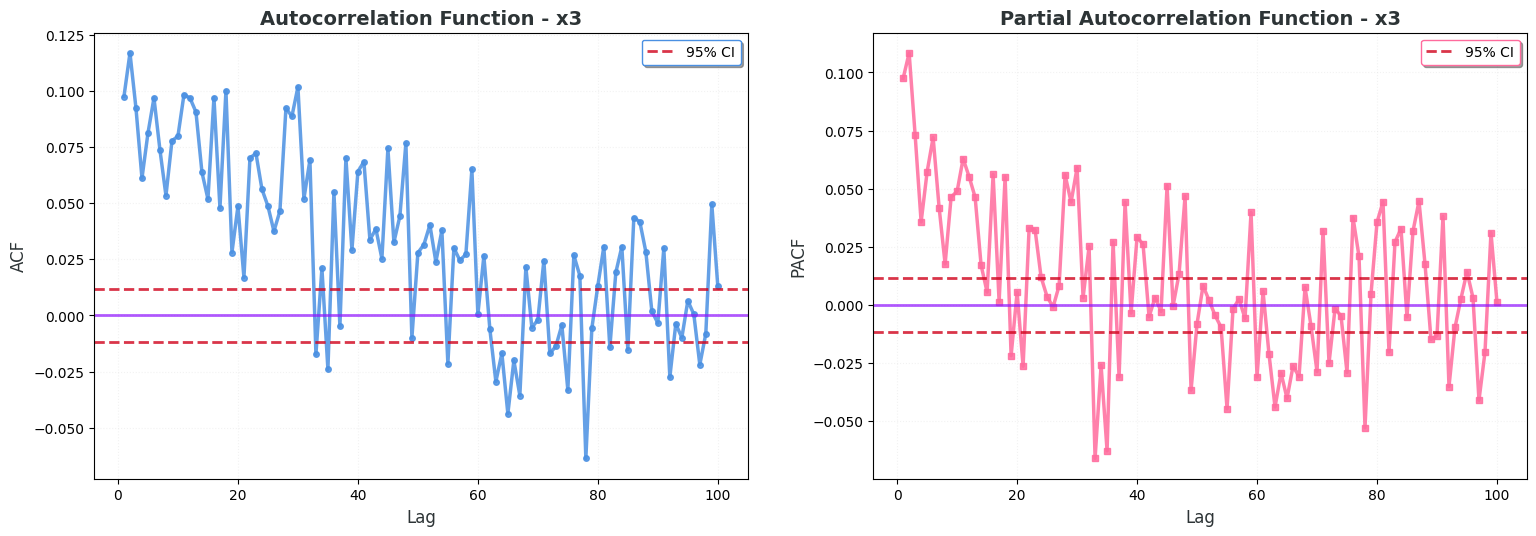

유의한 자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  8  9 10]
유의한 지연의 개수: 85
유의한 편자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  8  9 10]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 2에서 발생 (상관계수: 0.117)
- 1차 자기상관 (0.097) → 보통 수준의 시계열 의존성

--- x4 자기상관 분석 ---


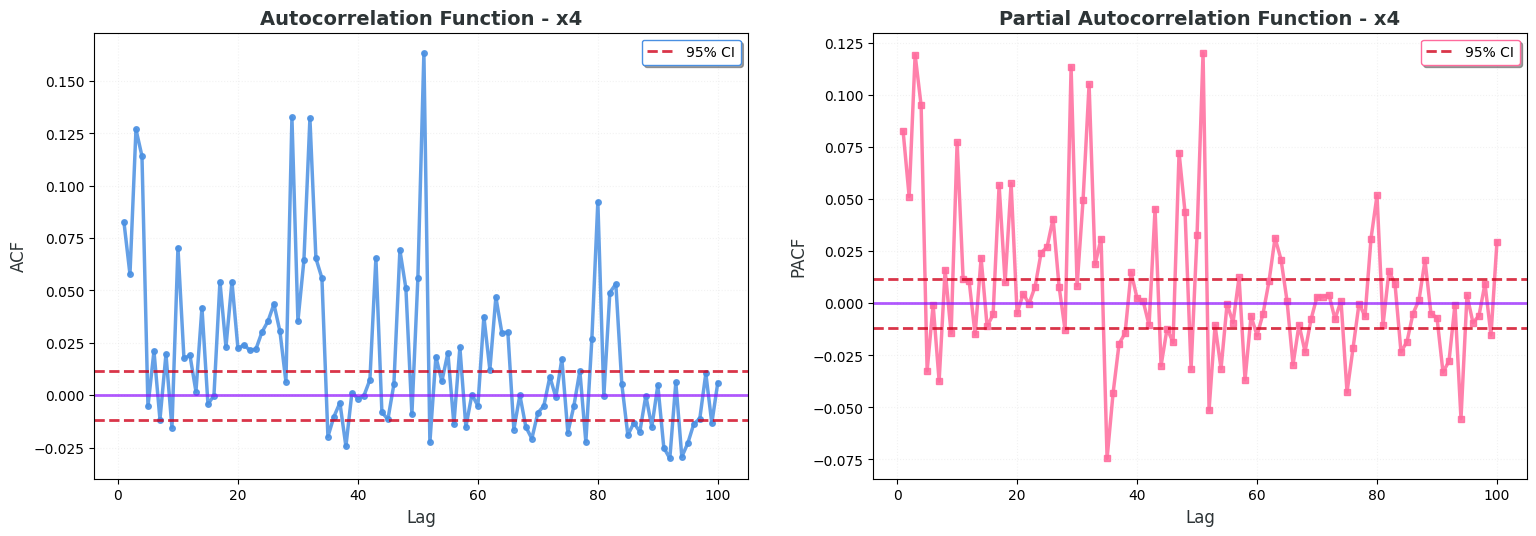

유의한 자기상관을 보이는 지연(lag): [ 1  2  3  4  6  7  8  9 10 11]
유의한 지연의 개수: 67
유의한 편자기상관을 보이는 지연(lag): [ 1  2  3  4  5  7  8  9 10 11]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 51에서 발생 (상관계수: 0.163)
- 1차 자기상관 (0.083) → 보통 수준의 시계열 의존성

--- x5 자기상관 분석 ---


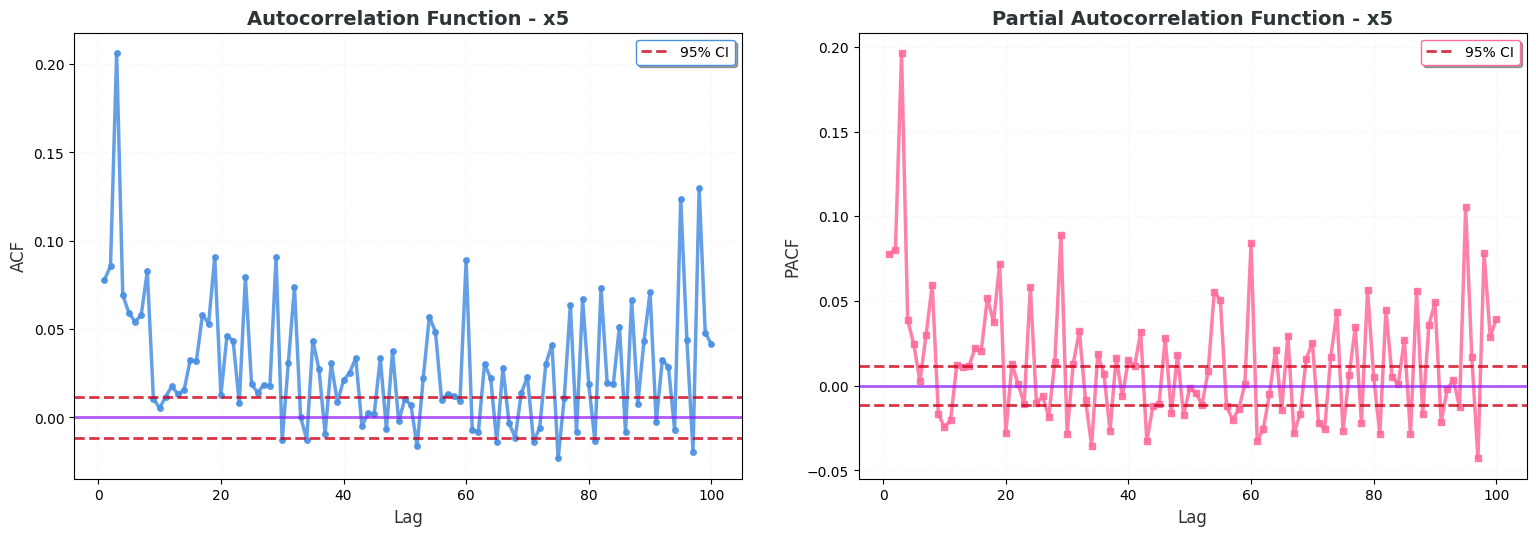

유의한 자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  8 11 12]
유의한 지연의 개수: 74
유의한 편자기상관을 보이는 지연(lag): [ 1  2  3  4  5  7  8  9 10 11]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 3에서 발생 (상관계수: 0.206)
- 1차 자기상관 (0.078) → 보통 수준의 시계열 의존성

--- x6 자기상관 분석 ---


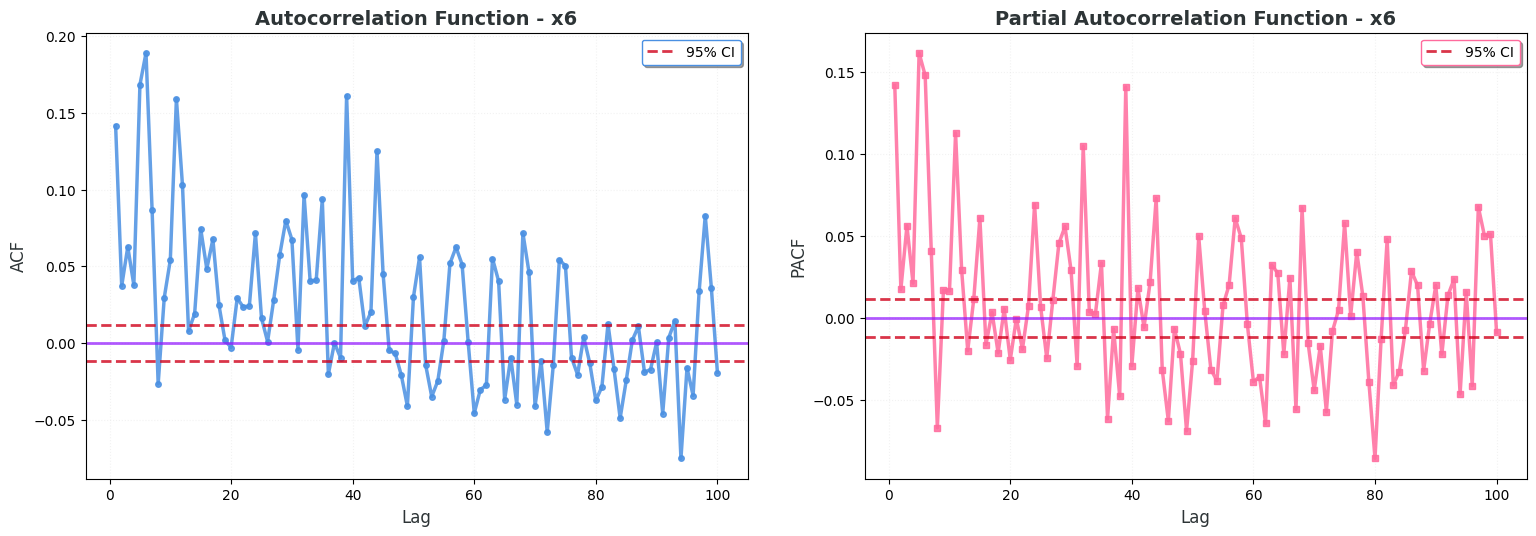

유의한 자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  8  9 10]
유의한 지연의 개수: 81
유의한 편자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  8  9 10]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 6에서 발생 (상관계수: 0.189)
- 1차 자기상관 (0.142) → 보통 수준의 시계열 의존성

--- x7 자기상관 분석 ---


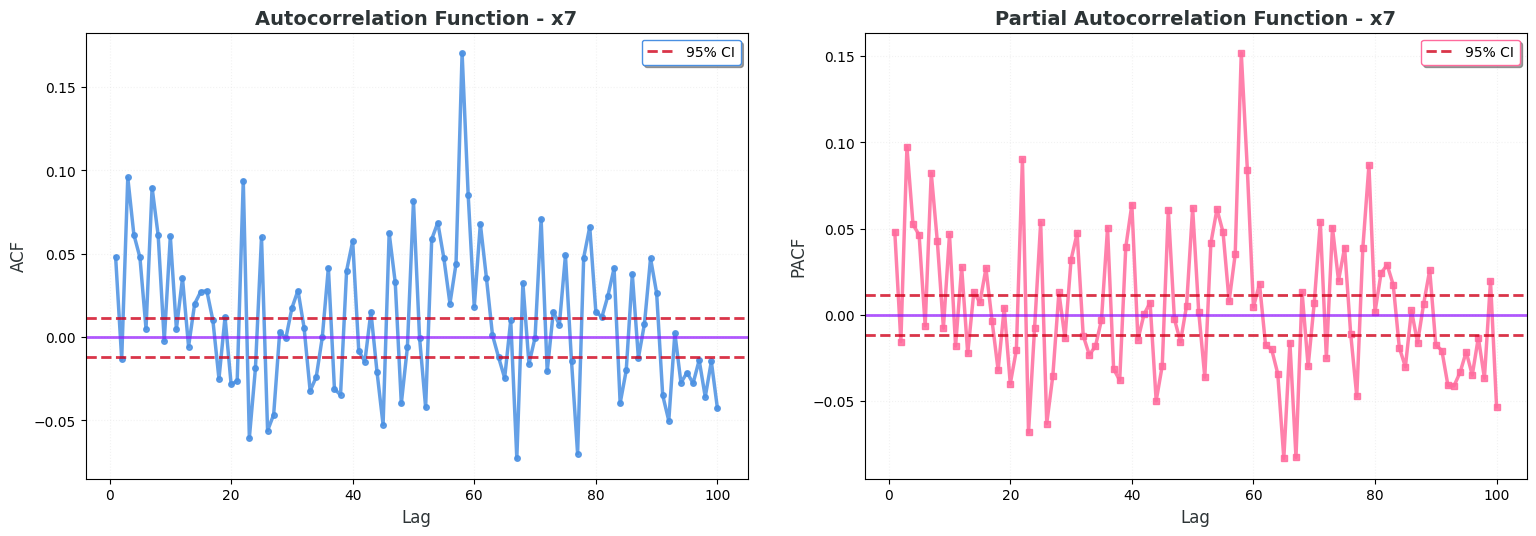

유의한 자기상관을 보이는 지연(lag): [ 1  2  3  4  5  7  8 10 12 14]
유의한 지연의 개수: 82
유의한 편자기상관을 보이는 지연(lag): [ 1  2  3  4  5  7  8 10 11 12]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 58에서 발생 (상관계수: 0.170)
- 1차 자기상관 (0.048) → 보통 수준의 시계열 의존성

--- x8 자기상관 분석 ---


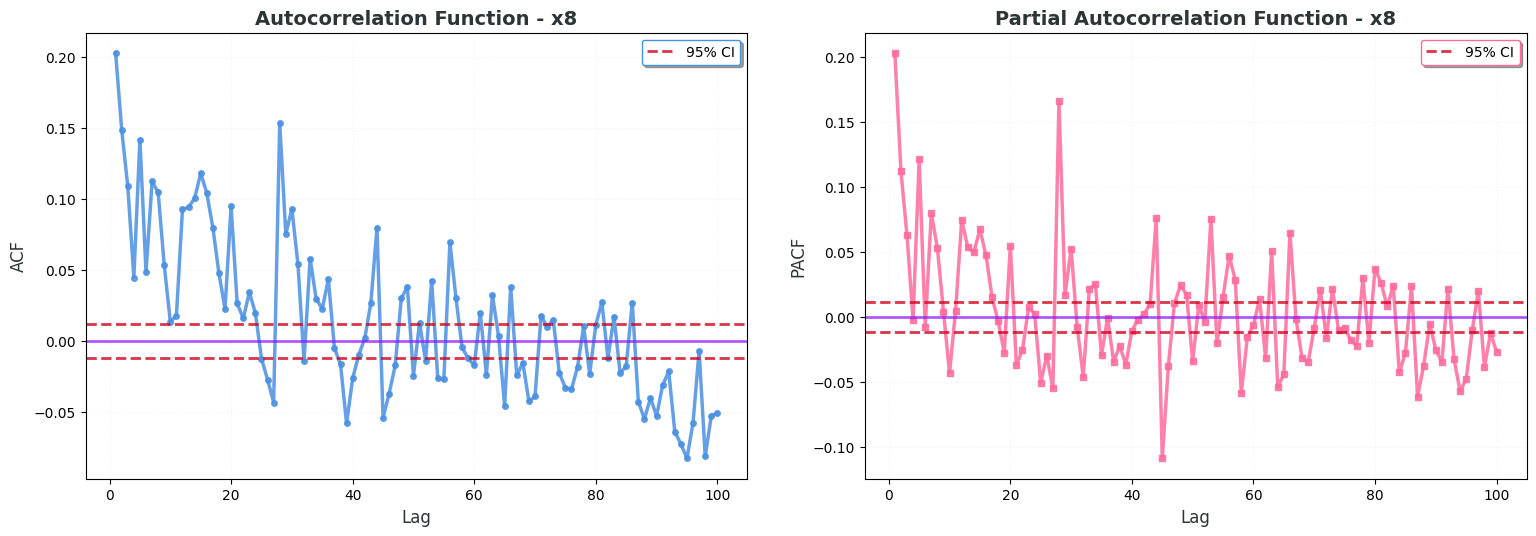

유의한 자기상관을 보이는 지연(lag): [ 1  2  3  4  5  6  7  8  9 10]
유의한 지연의 개수: 91
유의한 편자기상관을 보이는 지연(lag): [ 1  2  3  5  7  8 10 12 13 14]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 1에서 발생 (상관계수: 0.203)
- 1차 자기상관 (0.203) → 보통 수준의 시계열 의존성

--- x9 자기상관 분석 ---


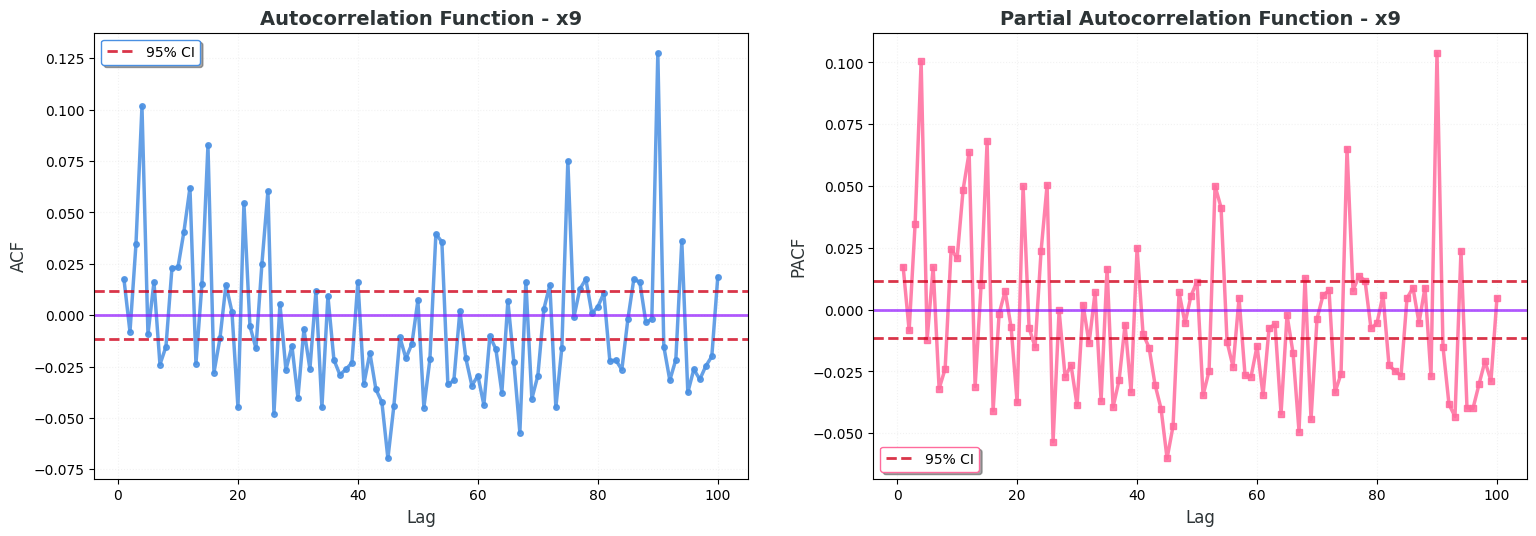

유의한 자기상관을 보이는 지연(lag): [ 1  3  4  6  7  8  9 10 11 12]
유의한 지연의 개수: 78
유의한 편자기상관을 보이는 지연(lag): [ 1  3  4  5  6  7  8  9 10 11]
해석:
- 유의한 자기상관 발견 → 강한 시계열성 존재
- 특정 시점의 값이 과거 값들과 상관관계를 가짐
- 가장 강한 상관관계는 지연 90에서 발생 (상관계수: 0.128)
- 1차 자기상관 (0.017) → 보통 수준의 시계열 의존성


In [13]:
## 3. 자기상관 분석

def analyze_autocorrelation(series, variable_name, lags=50):
    print(f"\n--- {variable_name} 자기상관 분석 ---")
    
    # 결측값 제거
    clean_series = series.dropna()
    
    # ACF (자기상관함수)
    autocorr = acf(clean_series, nlags=min(lags, len(clean_series)//4), fft=True)
    
    # PACF (편자기상관함수)  
    partial_autocorr = pacf(clean_series, nlags=min(lags, len(clean_series)//4))
    
    # 새로운 색상 팔레트 정의
    color_palette = {
        'acf_color': '#4A90E2',      # 모던 블루
        'pacf_color': '#FF6B9D',     # 로즈
        'confidence_color': '#D0021B', # 선명한 레드
        'zero_line_color': '#9013FE',  # 보라색
        'background_color': '#FFFFFF'  # 흰색 배경
    }
    
    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # ACF 플롯 (lag=0 제외)
    lags_range = range(1, len(autocorr))  # lag=0 제외
    ax1.plot(lags_range, autocorr[1:], marker='o', markersize=4, 
             color=color_palette['acf_color'], linewidth=2.5, alpha=0.85)
    
    # 0선과 신뢰구간 (ACF)
    ax1.axhline(y=0, color=color_palette['zero_line_color'], 
                linestyle='-', alpha=0.7, linewidth=2)
    confidence_interval = 1.96/np.sqrt(len(clean_series))
    ax1.axhline(y=confidence_interval, color=color_palette['confidence_color'], 
                linestyle='--', alpha=0.8, linewidth=2, label='95% CI')
    ax1.axhline(y=-confidence_interval, color=color_palette['confidence_color'], 
                linestyle='--', alpha=0.8, linewidth=2)
    
    # ACF 스타일링
    ax1.set_title(f'Autocorrelation Function - {variable_name}', 
                  fontsize=14, fontweight='bold', color='#2D3436')
    ax1.set_xlabel('Lag', fontsize=12, color='#2D3436')
    ax1.set_ylabel('ACF', fontsize=12, color='#2D3436')
    ax1.grid(True, alpha=0.4, color='#E0E0E0', linestyle=':')
    ax1.set_facecolor(color_palette['background_color'])
    ax1.legend(frameon=True, fancybox=True, shadow=True, 
               facecolor='white', edgecolor=color_palette['acf_color'])
    
    # PACF 플롯 (lag=0 제외)
    ax2.plot(lags_range, partial_autocorr[1:], marker='s', markersize=4, 
             color=color_palette['pacf_color'], linewidth=2.5, alpha=0.85)
    
    # 0선과 신뢰구간 (PACF)
    ax2.axhline(y=0, color=color_palette['zero_line_color'], 
                linestyle='-', alpha=0.7, linewidth=2)
    ax2.axhline(y=confidence_interval, color=color_palette['confidence_color'], 
                linestyle='--', alpha=0.8, linewidth=2, label='95% CI')
    ax2.axhline(y=-confidence_interval, color=color_palette['confidence_color'], 
                linestyle='--', alpha=0.8, linewidth=2)
    
    # PACF 스타일링
    ax2.set_title(f'Partial Autocorrelation Function - {variable_name}', 
                  fontsize=14, fontweight='bold', color='#2D3436')
    ax2.set_xlabel('Lag', fontsize=12, color='#2D3436')
    ax2.set_ylabel('PACF', fontsize=12, color='#2D3436')
    ax2.grid(True, alpha=0.4, color='#E0E0E0', linestyle=':')
    ax2.set_facecolor(color_palette['background_color'])
    ax2.legend(frameon=True, fancybox=True, shadow=True, 
               facecolor='white', edgecolor=color_palette['pacf_color'])
    
    # 전체 그림 스타일링
    fig.patch.set_facecolor('#FFFFFF')  # 흰색 배경
    plt.tight_layout(pad=3.0)
    plt.show()
    
    # 유의한 지연 찾기 (lag=0 제외)
    significant_lags = np.where(np.abs(autocorr[1:]) > confidence_interval)[0] + 1
    print(f"유의한 자기상관을 보이는 지연(lag): {significant_lags[:10]}")  # 처음 10개만
    print(f"유의한 지연의 개수: {len(significant_lags)}")
    
    # 유의한 PACF 지연 찾기 (lag=0 제외)
    significant_pacf_lags = np.where(np.abs(partial_autocorr[1:]) > confidence_interval)[0] + 1
    print(f"유의한 편자기상관을 보이는 지연(lag): {significant_pacf_lags[:10]}")
    
    # 해석
    print("해석:")
    if len(significant_lags) > 0:
        print("- 유의한 자기상관 발견 → 강한 시계열성 존재")
        print("- 특정 시점의 값이 과거 값들과 상관관계를 가짐")
        strongest_lag = np.argmax(np.abs(autocorr[1:])) + 1
        print(f"- 가장 강한 상관관계는 지연 {strongest_lag}에서 발생 (상관계수: {autocorr[strongest_lag]:.3f})")
    else:
        print("- 유의한 자기상관 없음 → 약한 시계열성")
        print("- 현재 값이 과거 값들과 강한 관련성이 없음")
    
    if autocorr[1] > 0.5:
        print(f"- 높은 1차 자기상관 ({autocorr[1]:.3f}) → 단기 지속성이 강함")
    elif autocorr[1] < -0.3:
        print(f"- 음의 1차 자기상관 ({autocorr[1]:.3f}) → 교대 패턴 존재")
    else:
        print(f"- 1차 자기상관 ({autocorr[1]:.3f}) → 보통 수준의 시계열 의존성")
    
    return autocorr, partial_autocorr

def full_autocorrelation_analysis(df_sorted, variables, lags):
    print("\n" + "="*60)
    print("3. 자기상관 종합 분석")
    print("="*60)
    
    results = {}
    for var in variables:
        autocorr, pacf_vals = analyze_autocorrelation(df_sorted[var], var, lags)
        results[var] = {'acf': autocorr, 'pacf': pacf_vals}
    
    return results

autocorr_results = full_autocorrelation_analysis(df_sorted, variables=numeric_features, lags=100)

In [14]:
## 4. 정상성 검정

def stationarity_test(series, variable_name):
    print(f"\n--- {variable_name} 정상성 검정 ---")
    
    clean_series = series.dropna()
    
    # ADF 검정 (귀무가설: 단위근 존재, 비정상적)
    try:
        adf_result = adfuller(clean_series)
        print(f"ADF 검정:")
        print(f"  ADF 통계량: {adf_result[0]:.4f}")
        print(f"  p-value: {adf_result[1]:.4f}")
        print(f"  임계값: {adf_result[4]}")
        adf_conclusion = '정상적' if adf_result[1] < 0.05 else '비정상적'
        print(f"  ADF 결론: {adf_conclusion}")
    except Exception as e:
        print(f"ADF 검정 실패: {e}")
        adf_conclusion = '알 수 없음'
    
    # KPSS 검정 (귀무가설: 정상적)
    try:
        kpss_result = kpss(clean_series, regression='c')
        print(f"KPSS 검정:")
        print(f"  KPSS 통계량: {kpss_result[0]:.4f}")
        print(f"  p-value: {kpss_result[1]:.4f}")
        print(f"  임계값: {kpss_result[3]}")
        kpss_conclusion = '정상적' if kpss_result[1] > 0.05 else '비정상적'
        print(f"  KPSS 결론: {kpss_conclusion}")
    except Exception as e:
        print(f"KPSS 검정 실패: {e}")
        kpss_conclusion = '알 수 없음'
    
    # 해석
    print("해석:")
    if adf_conclusion == '정상적' and kpss_conclusion == '정상적':
        print("- 두 검정 모두 정상성 확인")
        print("- 평균과 분산이 시간에 따라 일정함")
        print("- 표준 시계열 모델링에 적합")
    elif adf_conclusion == '비정상적' and kpss_conclusion == '비정상적':
        print("- 두 검정 모두 비정상성 확인")
        print("- 평균/분산이 시간에 따라 변화함")
        print("- 차분(differencing)이나 디트렌딩 필요할 수 있음")
    else:
        print("- 혼재된 결과 - 추가 조사 필요")
        print("- 추세정상성 vs 차분정상성 고려")
    
    return adf_conclusion, kpss_conclusion

def full_stationarity_analysis(df_sorted, variables):
    print("\n" + "="*60)
    print("4. 정상성 종합 분석")
    print("="*60)
    
    results = {}
    for var in variables:
        adf_result, kpss_result = stationarity_test(df_sorted[var], var)
        results[var] = {'adf': adf_result, 'kpss': kpss_result}
    
    return results

stationarity_results = full_stationarity_analysis(df_sorted, variables=numeric_features)


4. 정상성 종합 분석

--- x1 정상성 검정 ---


ADF 검정:
  ADF 통계량: -21.9688
  p-value: 0.0000
  임계값: {'1%': -3.4305814597129367, '5%': -2.861642298704645, '10%': -2.56682445051906}
  ADF 결론: 정상적
KPSS 검정:
  KPSS 통계량: 0.0020
  p-value: 0.1000
  임계값: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  KPSS 결론: 정상적
해석:
- 두 검정 모두 정상성 확인
- 평균과 분산이 시간에 따라 일정함
- 표준 시계열 모델링에 적합

--- x2 정상성 검정 ---
ADF 검정:
  ADF 통계량: -67.1420
  p-value: 0.0000
  임계값: {'1%': -3.4305810916340653, '5%': -2.8616421360304347, '10%': -2.566824363931376}
  ADF 결론: 정상적
KPSS 검정:
  KPSS 통계량: 0.5884
  p-value: 0.0237
  임계값: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  KPSS 결론: 비정상적
해석:
- 혼재된 결과 - 추가 조사 필요
- 추세정상성 vs 차분정상성 고려

--- x3 정상성 검정 ---
ADF 검정:
  ADF 통계량: -15.8251
  p-value: 0.0000
  임계값: {'1%': -3.4305814433289794, '5%': -2.8616422914636774, '10%': -2.5668244466648615}
  ADF 결론: 정상적
KPSS 검정:
  KPSS 통계량: 2.6515
  p-value: 0.0100
  임계값: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  KPSS 결론: 비정상적
해석:
- 혼재된 결과 - 추가 조사 필요
- 추세정상성 vs 차분정상


5. 그룹/공정별 패턴 분석
분석할 공정 개수: 10
공정 oper_102:
  관측치 수: 48
  y1 평균: 0.0296
  y1 표준편차: 0.0191
  시간 범위: 1 days 23:00:00

공정 oper_104:
  관측치 수: 48
  y1 평균: 0.0138
  y1 표준편차: 0.0072
  시간 범위: 1 days 23:00:00

공정 oper_106:
  관측치 수: 48
  y1 평균: 0.1260
  y1 표준편차: 0.0633
  시간 범위: 1 days 23:00:00

공정 oper_108:
  관측치 수: 48
  y1 평균: 0.0515
  y1 표준편차: 0.0803
  시간 범위: 1 days 23:00:00

공정 oper_111:
  관측치 수: 48
  y1 평균: 0.0270
  y1 표준편차: 0.0087
  시간 범위: 1 days 23:00:00

공정 oper_116:
  관측치 수: 48
  y1 평균: 0.0273
  y1 표준편차: 0.0161
  시간 범위: 1 days 23:00:00

공정 oper_118:
  관측치 수: 48
  y1 평균: 0.0343
  y1 표준편차: 0.0093
  시간 범위: 1 days 23:00:00

공정 oper_12:
  관측치 수: 48
  y1 평균: 0.0190
  y1 표준편차: 0.0148
  시간 범위: 1 days 23:00:00

공정 oper_120:
  관측치 수: 48
  y1 평균: 0.0444
  y1 표준편차: 0.0364
  시간 범위: 1 days 23:00:00

공정 oper_122:
  관측치 수: 48
  y1 평균: 0.0367
  y1 표준편차: 0.0187
  시간 범위: 1 days 23:00:00



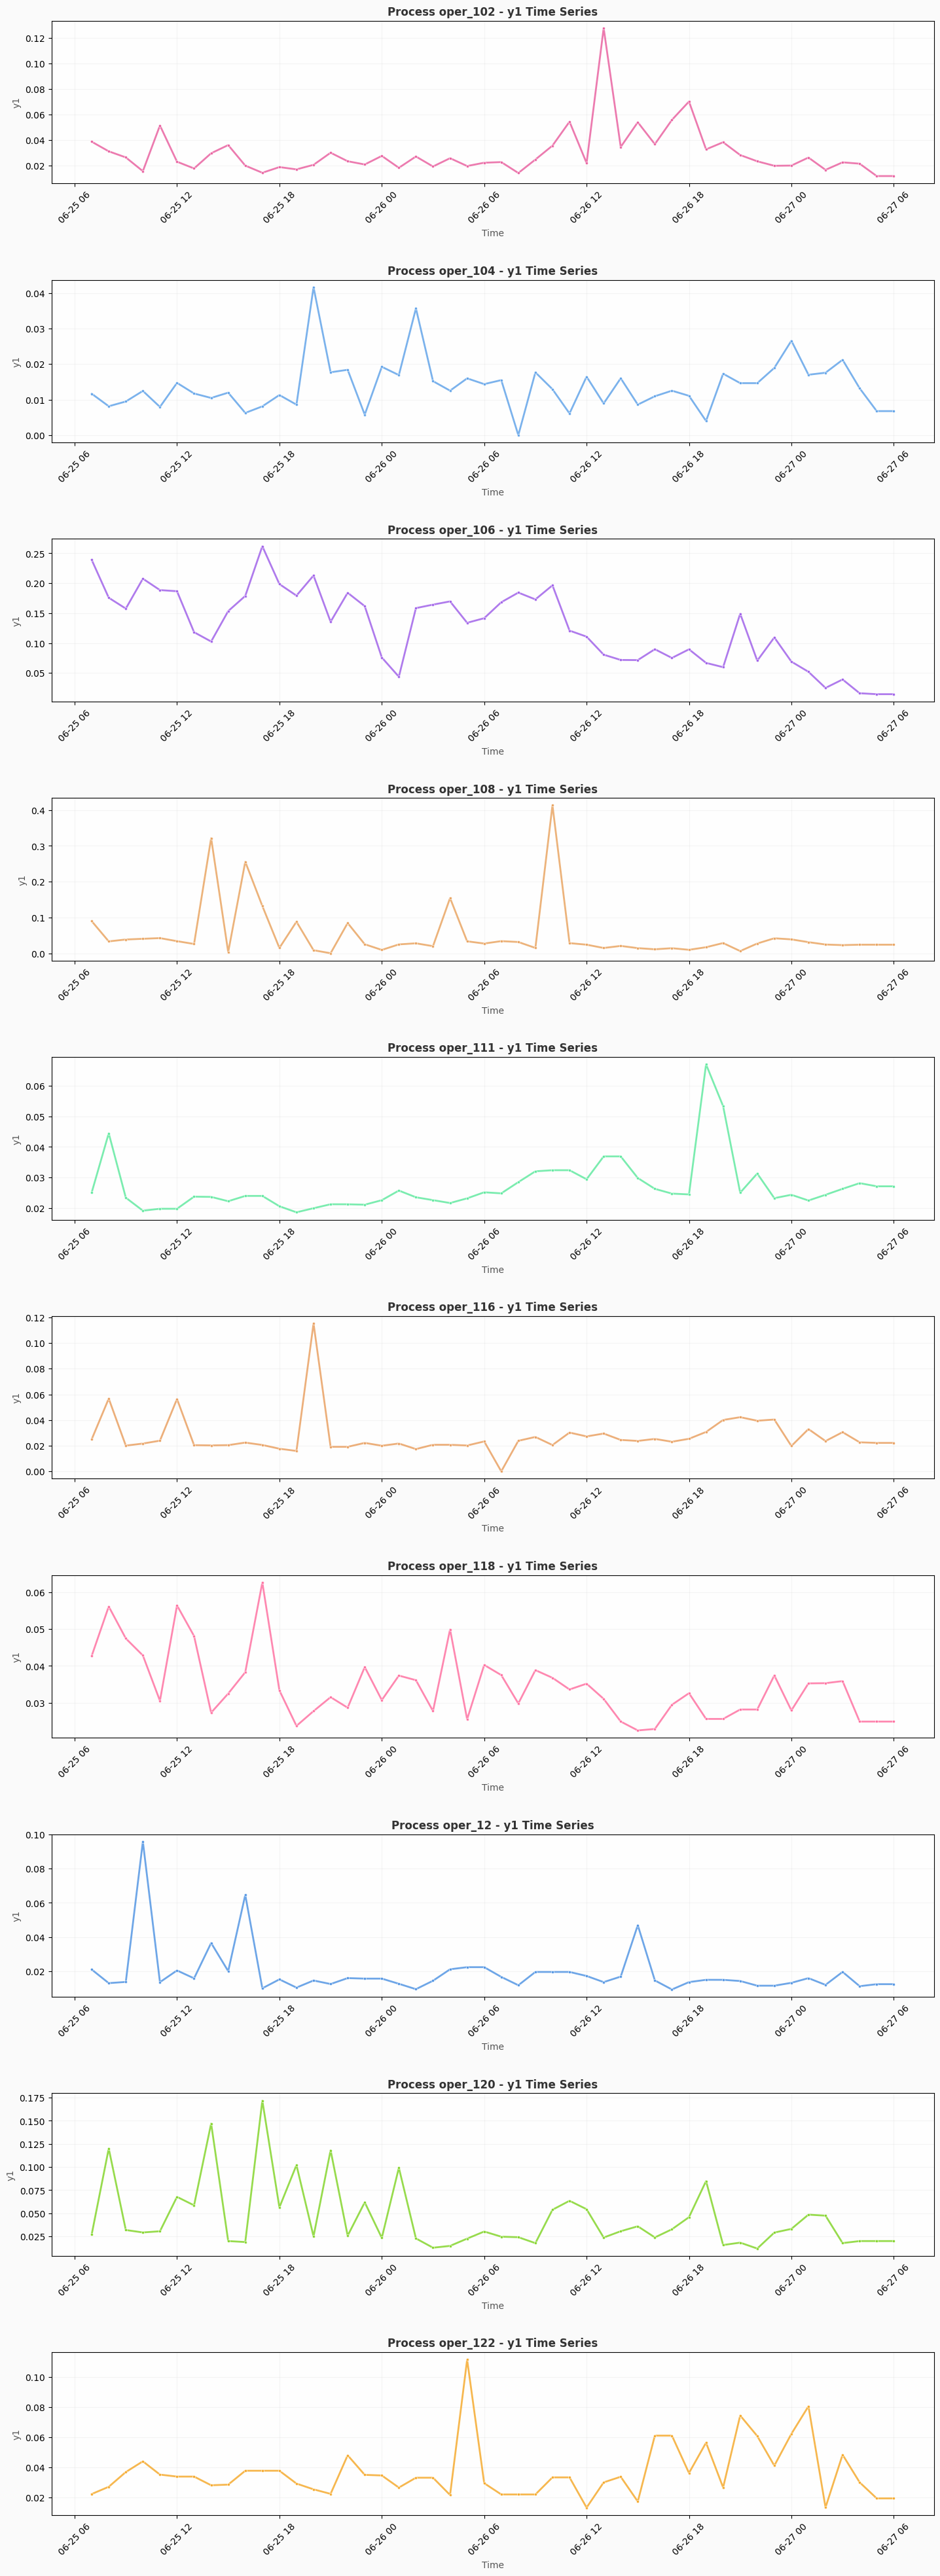

해석 방법:
- 공정마다 다른 시계열 행동을 보일 수 있음
- 공정별 특이 패턴이나 이상치 확인
- 패턴이 크게 다르면 각 공정별로 별도 모델링 고려
- 어떤 공정이 더 예측 가능한지 확인
- 총 10개 공정이 단일 컬럼으로 표시됨


In [15]:
## 5. 그룹/공정별 시계열 패턴 분석

def group_wise_analysis(df_sorted, unique_variable):
    print("\n" + "="*60)
    print("5. 그룹/공정별 패턴 분석")
    print("="*60)
    
    # 공정 개수 확인
    n_processes = len(unique_variable)
    print(f"분석할 공정 개수: {n_processes}")
    
    # 찐한 파스텔 색상 팔레트 (확장된 버전)
    colors = [
        '#E85A9C', '#5A9FE8', '#9C5AE8', '#E8A05A', '#5AE89C', '#E89C5A',
        '#FF6B9D', '#4A90E2', '#7ED321', '#F5A623', '#BD10E0', '#B8E986',
        '#50E3C2', '#FF9500', '#D0021B', '#417505', '#9013FE', '#FB6C42'
    ]
    
    # 동적 subplot 생성 (n행 1열)
    fig, axes = plt.subplots(n_processes, 1, figsize=(15, 4*n_processes))
    
    # 공정이 1개인 경우 axes를 리스트로 만들어 통일성 확보
    if n_processes == 1:
        axes = [axes]
    
    for i, oper in enumerate(unique_variable):
        oper_data = df_sorted[df_sorted['oper'] == oper].sort_values('datetime')
        color = colors[i % len(colors)]
        
        axes[i].plot(oper_data['datetime'], oper_data['y1'], 
                    marker='o', markersize=3, alpha=0.8, color=color, 
                    linewidth=2, markerfacecolor=color, 
                    markeredgecolor='white', markeredgewidth=0.5)
        axes[i].set_title(f'Process {oper} - y1 Time Series', 
                         fontsize=12, fontweight='bold', color='#333333')
        axes[i].set_xlabel('Time', fontsize=10, color='#555555')
        axes[i].set_ylabel('y1', fontsize=10, color='#555555')
        axes[i].grid(True, alpha=0.2, color='#CCCCCC')
        axes[i].set_facecolor('#FEFEFE')
        plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)
        
        # 데이터 범위에 따른 y축 조정
        if len(oper_data) > 0:
            y_range = oper_data['y1'].max() - oper_data['y1'].min()
            if y_range > 0:  # y_range가 0이 아닌 경우만
                axes[i].set_ylim(oper_data['y1'].min() - y_range*0.05, 
                               oper_data['y1'].max() + y_range*0.05)
        
        # 각 공정별 기본 통계 계산
        print(f"공정 {oper}:")
        print(f"  관측치 수: {len(oper_data)}")
        if len(oper_data) > 0:
            print(f"  y1 평균: {oper_data['y1'].mean():.4f}")
            print(f"  y1 표준편차: {oper_data['y1'].std():.4f}")
            print(f"  시간 범위: {oper_data['datetime'].max() - oper_data['datetime'].min()}")
        else:
            print("  데이터 없음")
        print()
    
    # 전체 스타일 조정
    fig.patch.set_facecolor('#FAFAFA')
    plt.tight_layout(pad=3.0)
    plt.show()
    
    print("해석 방법:")
    print("- 공정마다 다른 시계열 행동을 보일 수 있음")
    print("- 공정별 특이 패턴이나 이상치 확인")
    print("- 패턴이 크게 다르면 각 공정별로 별도 모델링 고려")
    print("- 어떤 공정이 더 예측 가능한지 확인")
    print(f"- 총 {n_processes}개 공정이 단일 컬럼으로 표시됨")

# 사용 예시
unique_oper = df_sorted['oper'].unique()[:10]
group_wise_analysis(df_sorted, unique_variable=unique_oper)


6. 계절성/주기성 종합 분석

--- x1 계절성 분석 ---
주요 주파수 성분: [0.27083333 0.1875     0.0625     0.25       0.33333333]
해당 amplitude: [1.55704894 1.55704894 1.55704894 1.55704894 1.55704894]
해당 주기 (시간 단위): [3.6923076923076925, 5.333333333333333, 16.0, 4.0, 3.0]
명확한 주기적 패턴이 발견되지 않음


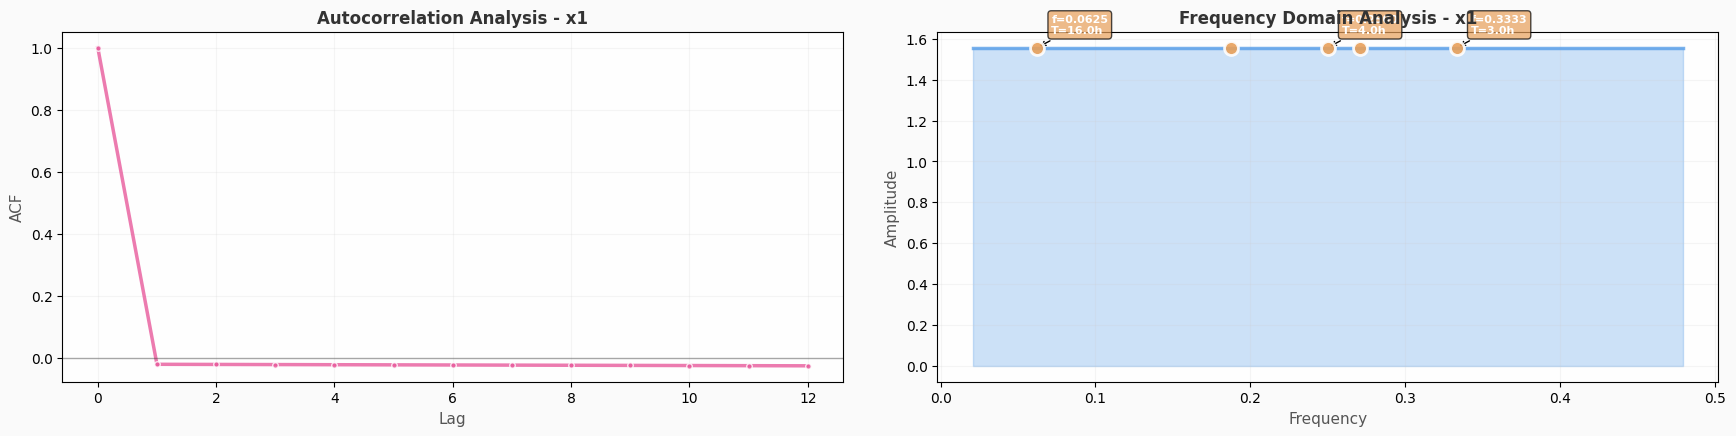

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x2 계절성 분석 ---
주요 주파수 성분: [0.0625     0.14583333 0.08333333 0.02083333 0.04166667]
해당 amplitude: [44.28697697 47.85042498 61.2909318  73.49843576 89.13040385]
해당 주기 (시간 단위): [16.0, 6.857142857142858, 12.0, 48.0, 24.0]
명확한 주기적 패턴이 발견되지 않음


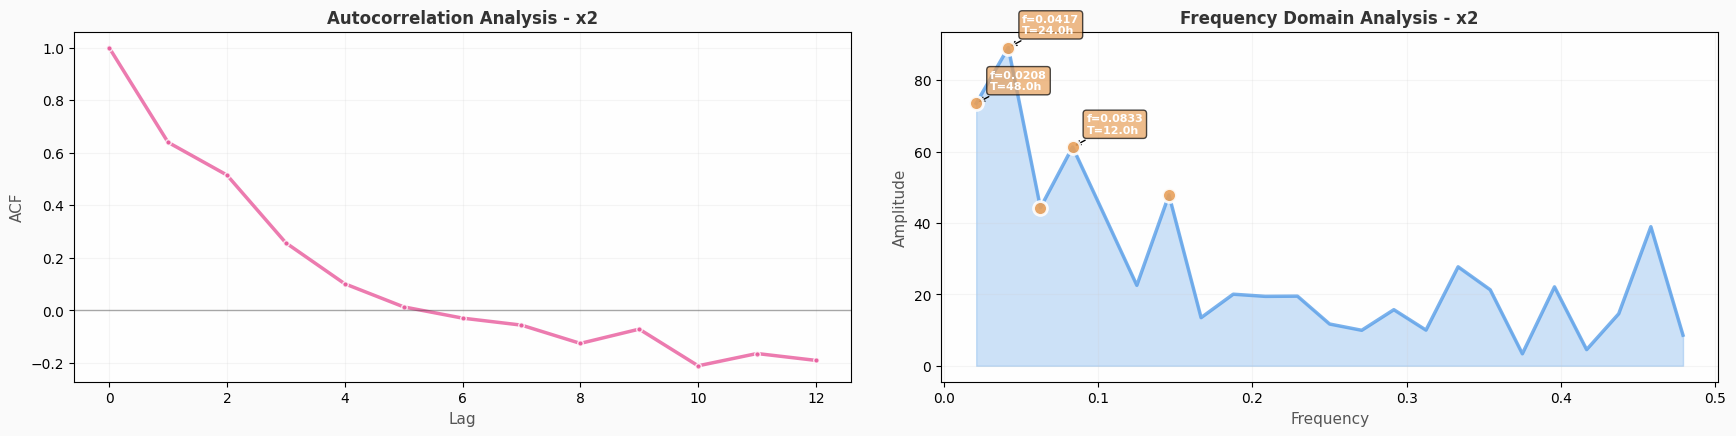

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x3 계절성 분석 ---
주요 주파수 성분: [0.125      0.0625     0.04166667 0.08333333 0.02083333]
해당 amplitude: [ 353.32783616  442.45188378  482.68050306  531.12473765 1724.39874349]
해당 주기 (시간 단위): [8.0, 16.0, 24.0, 12.0, 48.0]
명확한 주기적 패턴이 발견되지 않음


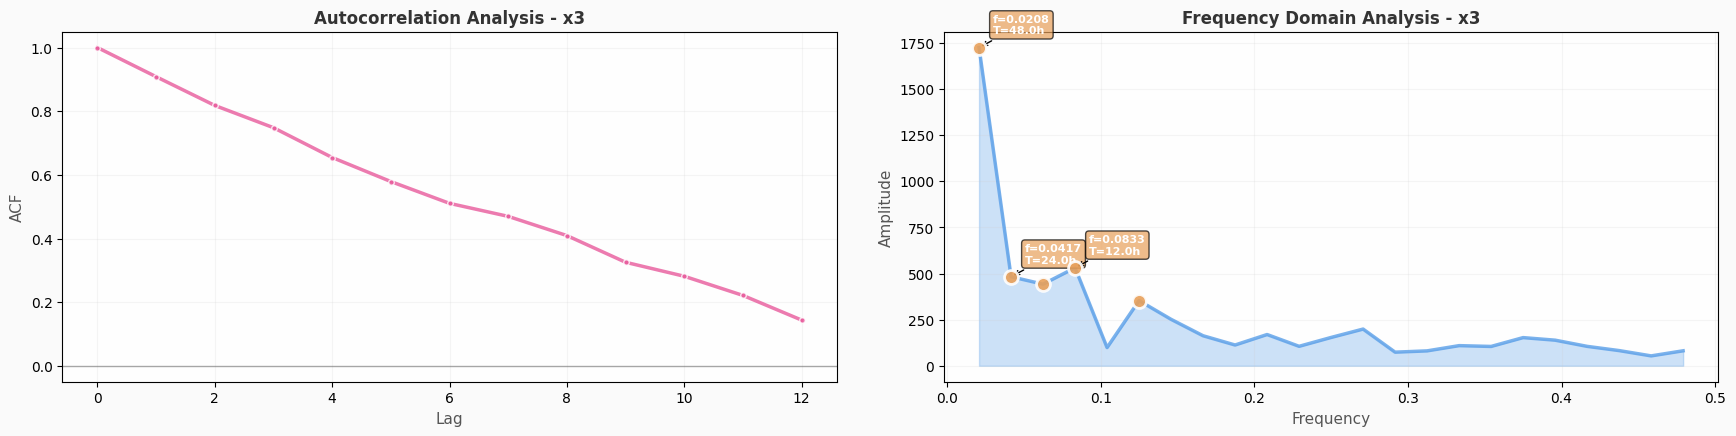

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x4 계절성 분석 ---
주요 주파수 성분: [0.125      0.08333333 0.10416667 0.02083333 0.04166667]
해당 amplitude: [18.86926841 30.91345023 34.08335158 40.51250461 53.91379142]
해당 주기 (시간 단위): [8.0, 12.0, 9.600000000000001, 48.0, 24.0]
명확한 주기적 패턴이 발견되지 않음


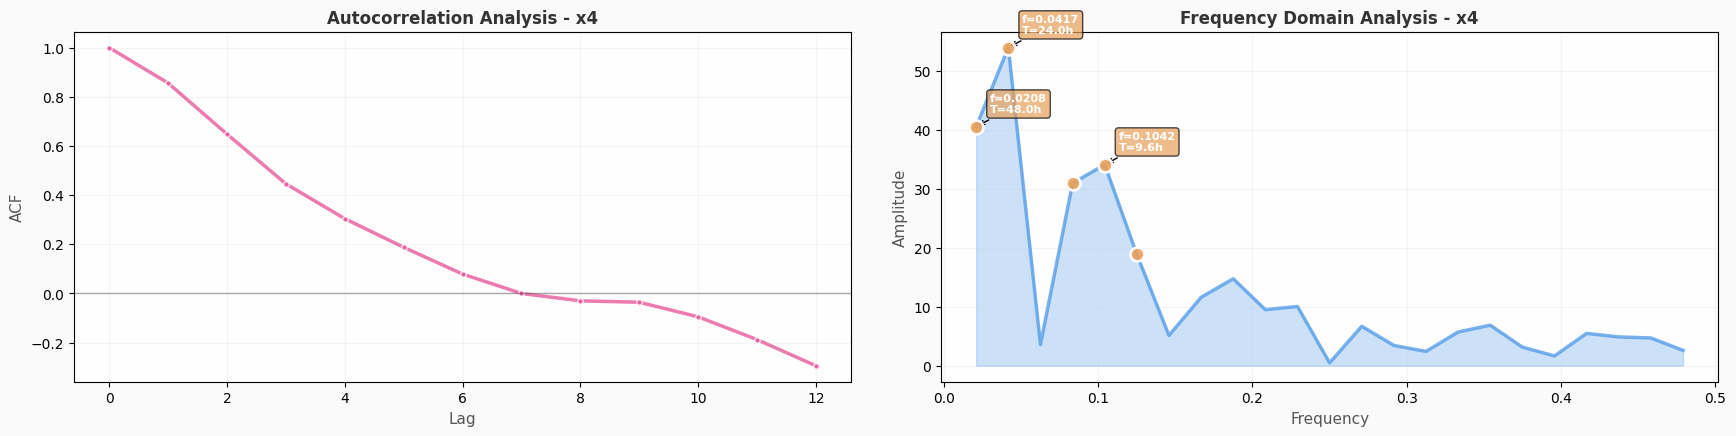

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x5 계절성 분석 ---
주요 주파수 성분: [0.10416667 0.0625     0.08333333 0.04166667 0.02083333]
해당 amplitude: [ 48.13375529  51.48414684  86.47980951 150.19625533 154.07707236]
해당 주기 (시간 단위): [9.600000000000001, 16.0, 12.0, 24.0, 48.0]
명확한 주기적 패턴이 발견되지 않음


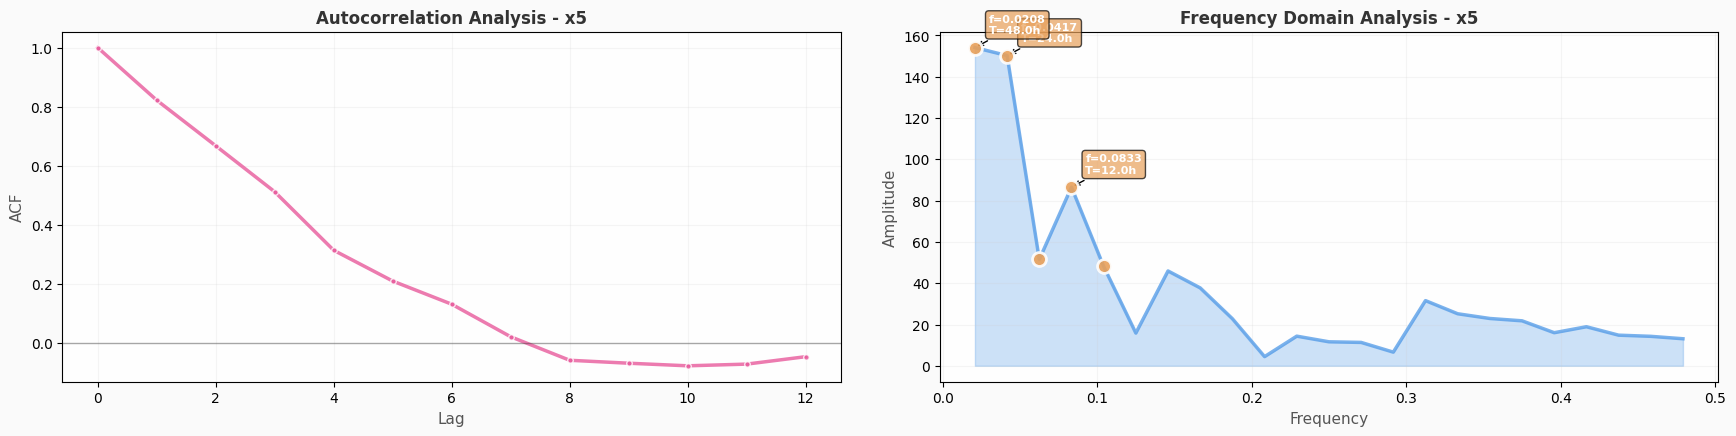

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x6 계절성 분석 ---
주요 주파수 성분: [0.1875     0.08333333 0.0625     0.02083333 0.04166667]
해당 amplitude: [ 36.81130034  72.60058145  76.91632939 100.58230371 214.36302483]
해당 주기 (시간 단위): [5.333333333333333, 12.0, 16.0, 48.0, 24.0]
명확한 주기적 패턴이 발견되지 않음


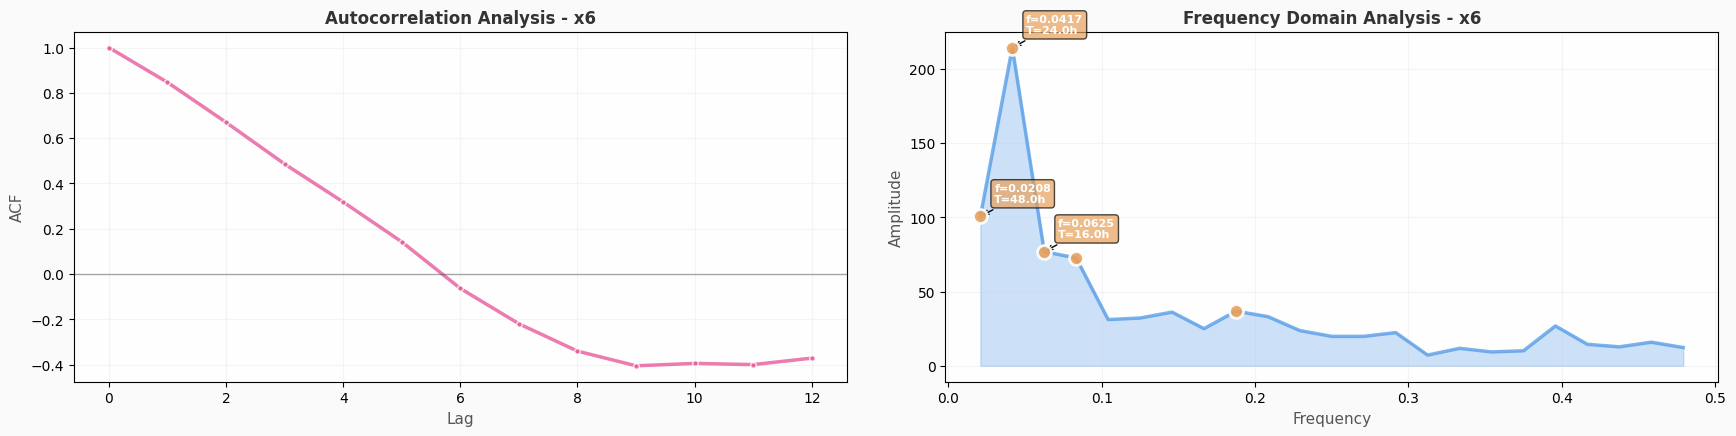

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x7 계절성 분석 ---
주요 주파수 성분: [0.10416667 0.125      0.08333333 0.02083333 0.04166667]
해당 amplitude: [ 23.28896314  28.38217636  28.89468577  75.15683197 107.1672147 ]
해당 주기 (시간 단위): [9.600000000000001, 8.0, 12.0, 48.0, 24.0]
명확한 주기적 패턴이 발견되지 않음


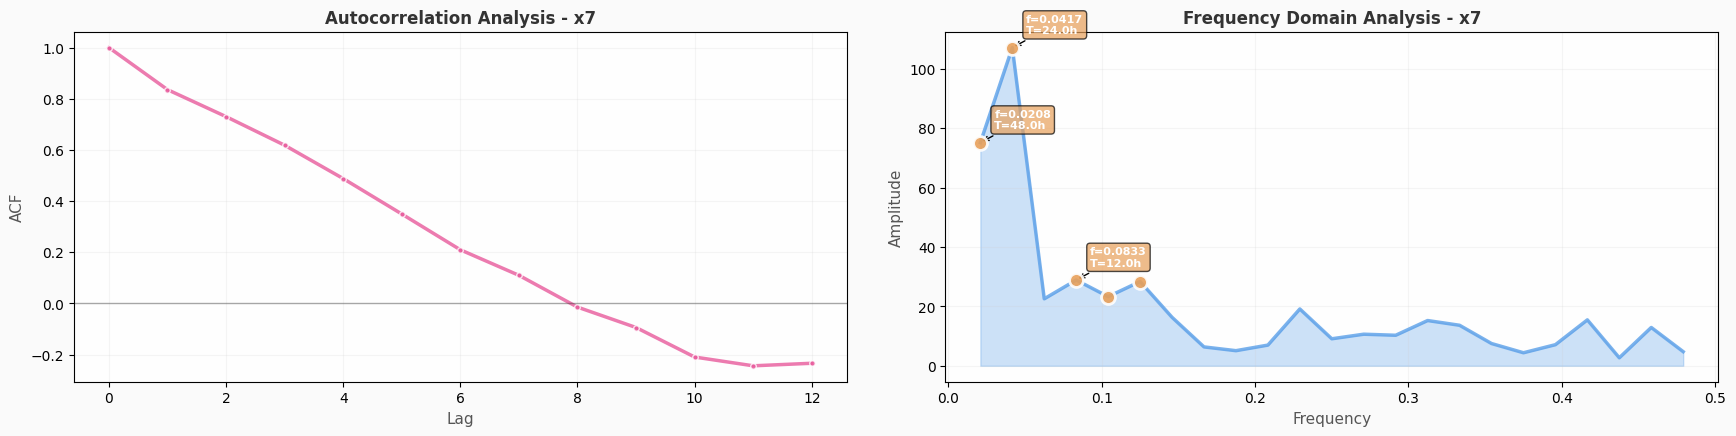

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x8 계절성 분석 ---
주요 주파수 성분: [0.27083333 0.10416667 0.14583333 0.0625     0.02083333]
해당 amplitude: [ 36.15225498  41.34157793  41.95491948  94.31785376 220.73511604]
해당 주기 (시간 단위): [3.6923076923076925, 9.600000000000001, 6.857142857142858, 16.0, 48.0]
주기적 패턴이 발견된 지연: [11]


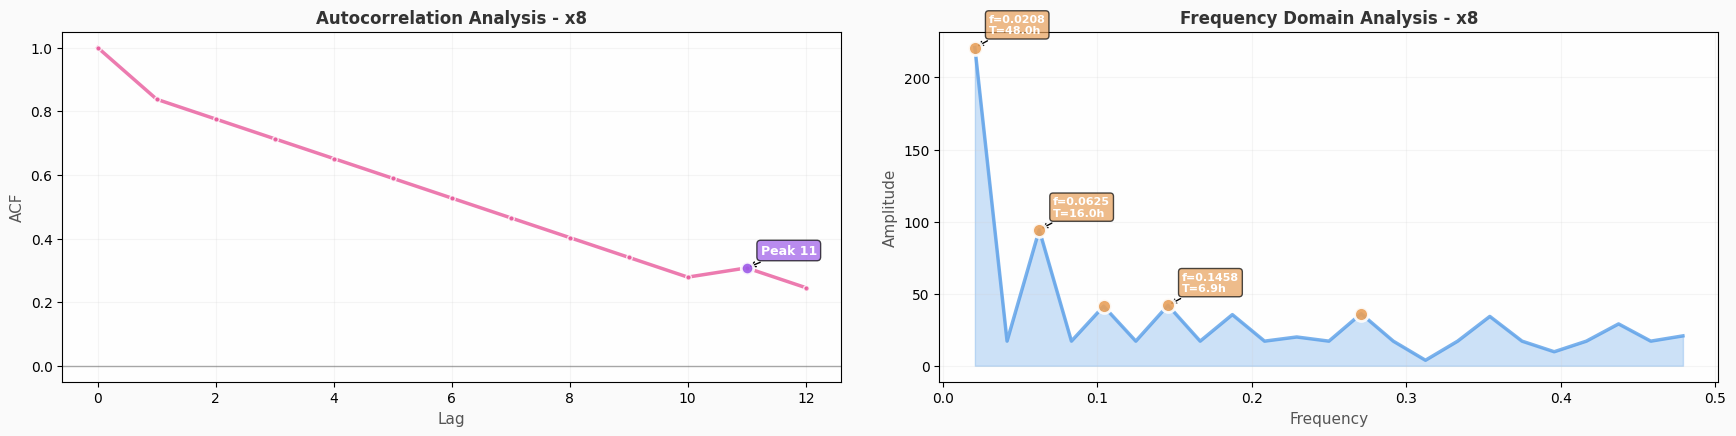

해석 방법:
- 주기적 패턴 발견 → 계절성 존재
- 계절 분해(seasonal decomposition)나 계절 ARIMA 모델 고려
- 정기적인 운영 주기가 계절성을 만들 수 있음
- 자기상관에서 1개의 주기적 패턴 발견
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄

--- x9 계절성 분석 ---
주요 주파수 성분: [0.33333333 0.10416667 0.08333333 0.02083333 0.04166667]
해당 amplitude: [0.05009532 0.05815788 0.08878621 0.09947787 0.10512908]
해당 주기 (시간 단위): [3.0, 9.600000000000001, 12.0, 48.0, 24.0]
명확한 주기적 패턴이 발견되지 않음


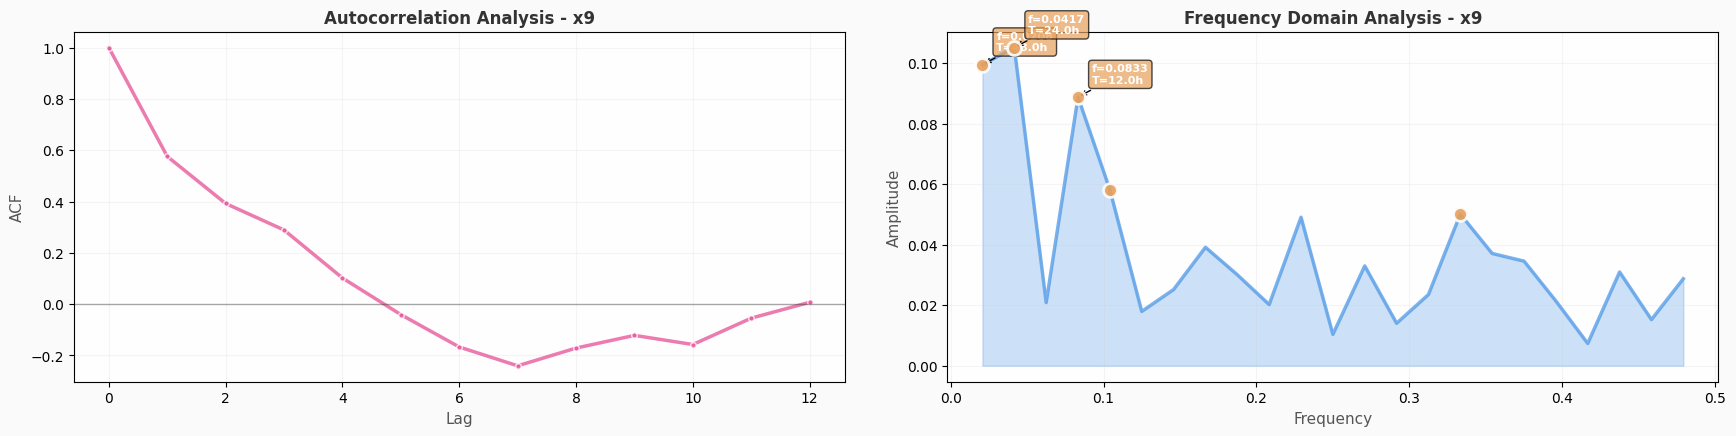

해석 방법:
- 명확한 계절성이 발견되지 않음
- 데이터가 주로 불규칙한 요인에 의해 결정됨
- FFT 분석에서 5개의 주요 주파수 성분 발견
- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄


In [16]:
## 6. 계절성/주기성 분석

def detect_seasonality(series, datetime_series, variable_name):
    print(f"\n--- {variable_name} 계절성 분석 ---")
    
    # 리샘플링을 위한 임시 데이터프레임 생성
    df_temp = pd.DataFrame({'datetime': datetime_series, 'value': series})
    df_temp = df_temp.set_index('datetime').resample('1H').mean().interpolate()
    
    if len(df_temp) < 10:
        print("계절성 분석을 위한 데이터가 부족함")
        return None, None, None, None
    
    # 주파수 도메인 분석을 위한 FFT
    clean_values = df_temp['value'].dropna()
    fft = np.fft.fft(clean_values)
    freqs = np.fft.fftfreq(len(fft))
    
    # 주요 주파수 성분 찾기
    magnitude = np.abs(fft)
    # DC 성분을 제외한 양의 주파수만 사용
    positive_freqs = freqs[1:len(freqs)//2]
    positive_magnitude = magnitude[1:len(magnitude)//2]
    
    # 상위 주파수 성분들 찾기
    top_indices = np.argsort(positive_magnitude)[-5:]
    dominant_freqs = positive_freqs[top_indices]
    dominant_magnitudes = positive_magnitude[top_indices]
    
    print(f"주요 주파수 성분: {dominant_freqs}")
    print(f"해당 amplitude: {dominant_magnitudes}")
    
    # 주파수를 주기(시간 단위)로 변환
    periods = []
    for freq in dominant_freqs:
        if freq > 0:
            period = 1 / freq
            periods.append(period)
    
    print(f"해당 주기 (시간 단위): {periods}")
    
    # 자기상관 기반 주기성 검출
    max_lags = min(100, len(clean_values)//4)
    autocorr = acf(clean_values, nlags=max_lags)
    
    # 자기상관에서 피크 찾기
    peaks, properties = signal.find_peaks(autocorr[1:], height=0.1, distance=5)
    if len(peaks) > 0:
        periodic_lags = peaks + 1
        print(f"주기적 패턴이 발견된 지연: {periodic_lags}")
    else:
        print("명확한 주기적 패턴이 발견되지 않음")
    
    # 찐한 파스텔 색상 팔레트
    colors = {
        'main': '#E85A9C',      # 찐한 파스텔 핑크
        'secondary': '#5A9FE8', # �진한 파스텔 블루  
        'accent': '#9C5AE8',    # 찐한 파스텔 퍼플
        'highlight': '#E8A05A', # 찐한 파스텔 오렌지
        'success': '#5AE89C'    # 찐한 파스텔 그린
    }
    
    # 자기상관과 FFT Amplitude를 함께 플롯
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    
    # 왼쪽: 자기상관 플롯
    ax1.plot(autocorr, marker='o', markersize=4, color=colors['main'], 
             linewidth=2.5, alpha=0.8, markerfacecolor=colors['main'], 
             markeredgecolor='white', markeredgewidth=1)
    ax1.axhline(y=0, color='#333333', linestyle='-', alpha=0.4, linewidth=1)
    ax1.set_title(f'Autocorrelation Analysis - {variable_name}', 
                  fontsize=12, fontweight='bold', color='#333333')
    ax1.set_xlabel('Lag', fontsize=11, color='#555555')
    ax1.set_ylabel('ACF', fontsize=11, color='#555555')
    ax1.grid(True, alpha=0.2, color='#CCCCCC')
    ax1.set_facecolor('#FEFEFE')
    
    # 피크 강조 표시
    if len(peaks) > 0:
        ax1.scatter(peaks + 1, autocorr[peaks + 1], color=colors['accent'], 
                   s=80, zorder=5, edgecolors='white', linewidth=2, alpha=0.9)
        # 피크에 주석 추가
        for i, peak in enumerate(peaks[:3]):  # 처음 3개만 표시
            ax1.annotate(f'Peak {peak+1}', 
                        xy=(peak+1, autocorr[peak+1]), 
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor=colors['accent'], alpha=0.7),
                        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
                        fontsize=9, color='white', fontweight='bold')
    
    # 오른쪽: FFT Amplitude 스펙트럼
    ax2.plot(positive_freqs, positive_magnitude, color=colors['secondary'], 
             linewidth=2.5, alpha=0.8)
    ax2.fill_between(positive_freqs, positive_magnitude, alpha=0.3, color=colors['secondary'])
    
    # 주요 주파수 성분 강조
    ax2.scatter(dominant_freqs, dominant_magnitudes, color=colors['highlight'], 
               s=100, zorder=5, edgecolors='white', linewidth=2, alpha=0.9)
    
    ax2.set_title(f'Frequency Domain Analysis - {variable_name}', 
                  fontsize=12, fontweight='bold', color='#333333')
    ax2.set_xlabel('Frequency', fontsize=11, color='#555555')
    ax2.set_ylabel('Amplitude', fontsize=11, color='#555555')
    ax2.grid(True, alpha=0.2, color='#CCCCCC')
    ax2.set_facecolor('#FEFEFE')
    
    # 주요 주파수에 주석 추가
    for i, (freq, mag) in enumerate(zip(dominant_freqs[-3:], dominant_magnitudes[-3:])):  # 상위 3개만
        period = 1/freq if freq > 0 else 0
        ax2.annotate(f'f={freq:.4f}\nT={period:.1f}h', 
                    xy=(freq, mag), 
                    xytext=(10, 10), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors['highlight'], alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
                    fontsize=8, color='white', fontweight='bold')
    
    # 전체 스타일 조정
    fig.patch.set_facecolor('#FAFAFA')
    plt.tight_layout(pad=3.0)
    plt.show()
    
    print("해석 방법:")
    if len(peaks) > 0:
        print("- 주기적 패턴 발견 → 계절성 존재")
        print("- 계절 분해(seasonal decomposition)나 계절 ARIMA 모델 고려")
        print("- 정기적인 운영 주기가 계절성을 만들 수 있음")
        print(f"- 자기상관에서 {len(peaks)}개의 주기적 패턴 발견")
    else:
        print("- 명확한 계절성이 발견되지 않음")
        print("- 데이터가 주로 불규칙한 요인에 의해 결정됨")
    
    if len(dominant_freqs) > 0:
        print(f"- FFT 분석에서 {len(dominant_freqs)}개의 주요 주파수 성분 발견")
        print("- 높은 amplitude를 가진 주파수들이 주요 주기성을 나타냄")
    
    return autocorr, positive_freqs, positive_magnitude, periods

def full_seasonality_analysis(df_sorted, variables=None):
    print("\n" + "="*60)
    print("6. 계절성/주기성 종합 분석")
    print("="*60)
    
    if variables is None:
        variables = ['y1', 'x1']
    
    # 주요 변수들의 계절성 분석
    results = {}
    for var in variables:
        if var in df_sorted.columns:
            autocorr, freqs, magnitude, periods = detect_seasonality(
                df_sorted[var], df_sorted['datetime'], var
            )
            results[var] = {
                'autocorr': autocorr, 
                'freqs': freqs, 
                'magnitude': magnitude,
                'periods': periods
            }
        else:
            print(f"변수 {var}가 데이터프레임에 존재하지 않음")
    
    return results

seasonality_results = full_seasonality_analysis(df_sorted, variables=numeric_features)


7. 교차상관 종합 분석
분석할 변수 쌍들 (with target 'y1'):
  - x1 vs y1
  - x2 vs y1
  - x3 vs y1

--- 교차상관 분석: x1 vs y1 ---


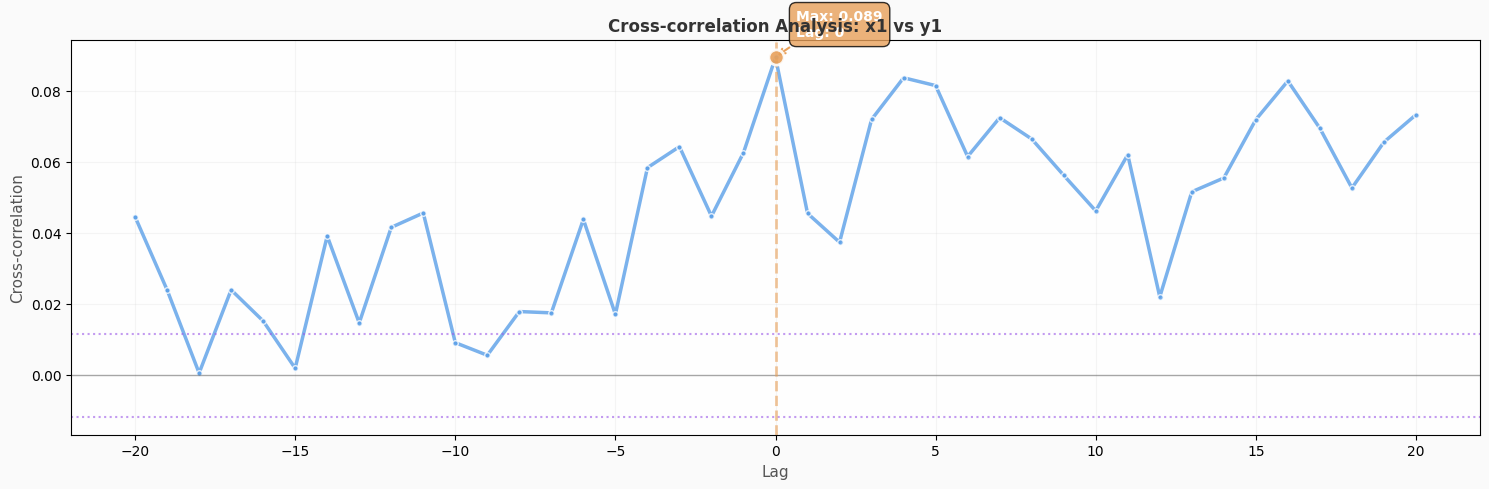

최대 교차상관: 0.0893, 지연: 0
해석 방법:
- 약한 교차상관
- 변수들 간에 강한 시간적 관계가 없을 수 있음
- 독립적인 변동 패턴을 보임

--- 교차상관 분석: x2 vs y1 ---


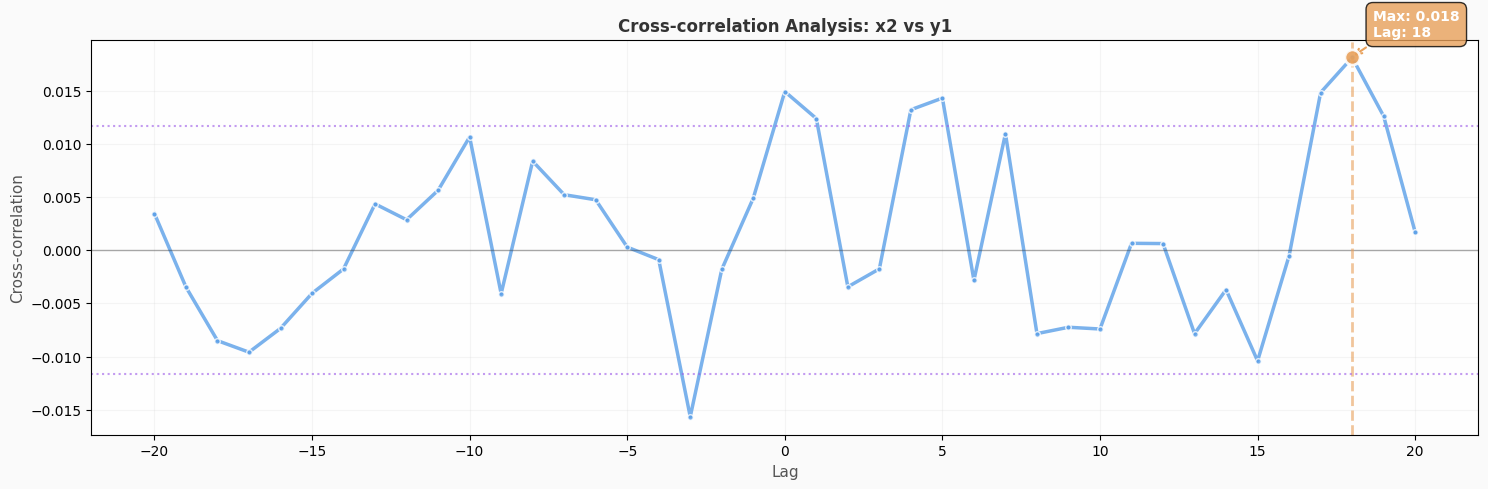

최대 교차상관: 0.0181, 지연: 18
해석 방법:
- 약한 교차상관
- 변수들 간에 강한 시간적 관계가 없을 수 있음
- 독립적인 변동 패턴을 보임

--- 교차상관 분석: x3 vs y1 ---


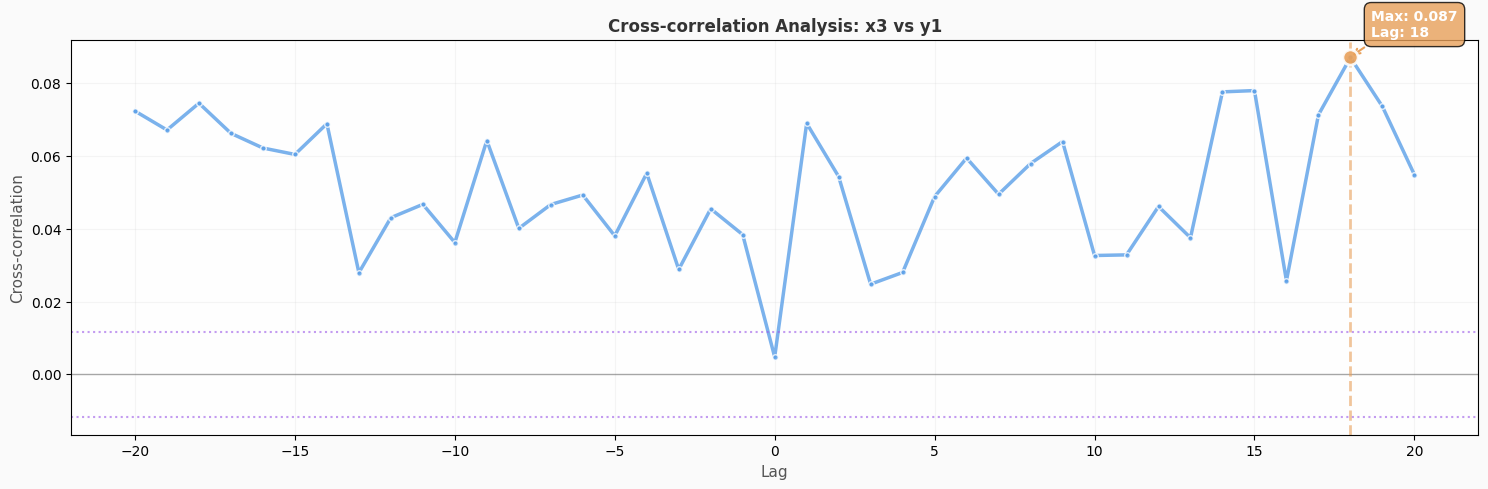

최대 교차상관: 0.0871, 지연: 18
해석 방법:
- 약한 교차상관
- 변수들 간에 강한 시간적 관계가 없을 수 있음
- 독립적인 변동 패턴을 보임


In [43]:
## 7. 교차상관 분석

def cross_correlation_analysis(x, y, var1_name, var2_name, max_lags=20):
    print(f"\n--- 교차상관 분석: {var1_name} vs {var2_name} ---")
    
    # 결측값 제거
    valid_indices = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[valid_indices]
    y_clean = y[valid_indices]
    
    cross_corr = []
    lags = range(-max_lags, max_lags + 1)
    
    for lag in lags:
        if lag < 0:
            if len(x_clean[:lag]) > 0 and len(y_clean[-lag:]) > 0:
                corr = np.corrcoef(x_clean[:lag], y_clean[-lag:])[0, 1]
            else:
                corr = 0
        elif lag > 0:
            if len(x_clean[lag:]) > 0 and len(y_clean[:-lag]) > 0:
                corr = np.corrcoef(x_clean[lag:], y_clean[:-lag])[0, 1]
            else:
                corr = 0
        else:
            corr = np.corrcoef(x_clean, y_clean)[0, 1]
        cross_corr.append(corr)
    
    # 찐한 파스텔 색상 팔레트
    colors = {
        'main': '#E85A9C',      # 찐한 파스텔 핑크
        'secondary': '#5A9FE8', # 찐한 파스텔 블루  
        'accent': '#9C5AE8',    # 찐한 파스텔 퍼플
        'highlight': '#E8A05A', # 찐한 파스텔 오렌지
        'success': '#5AE89C'    # 찐한 파스텔 그린
    }
    
    plt.figure(figsize=(15, 5))
    
    # 메인 교차상관 플롯
    plt.plot(lags, cross_corr, marker='o', markersize=4, color=colors['secondary'], 
             linewidth=2.5, alpha=0.8, markerfacecolor=colors['secondary'], 
             markeredgecolor='white', markeredgewidth=1)
    
    # 영점선
    plt.axhline(y=0, color='#333333', linestyle='-', alpha=0.4, linewidth=1)
    
    # 최대 교차상관과 그때의 지연 찾기
    max_corr_idx = np.argmax(np.abs(cross_corr))
    max_lag = lags[max_corr_idx]
    max_corr = cross_corr[max_corr_idx]
    
    # 최대값 강조 표시
    plt.scatter([max_lag], [max_corr], color=colors['highlight'], 
               s=120, zorder=5, edgecolors='white', linewidth=2, alpha=0.9)
    
    # 최대값에 주석 추가
    plt.annotate(f'Max: {max_corr:.3f}\nLag: {max_lag}', 
                xy=(max_lag, max_corr), 
                xytext=(15, 15), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=colors['highlight'], alpha=0.8),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', 
                               color=colors['highlight'], lw=1.5),
                fontsize=10, color='white', fontweight='bold')
    
    # 최대값 위치에 수직선 추가
    plt.axvline(x=max_lag, color=colors['highlight'], linestyle='--', alpha=0.6, linewidth=2)
    
    plt.xlabel('Lag', fontsize=11, color='#555555')
    plt.ylabel('Cross-correlation', fontsize=11, color='#555555')
    plt.title(f'Cross-correlation Analysis: {var1_name} vs {var2_name}', 
              fontsize=12, fontweight='bold', color='#333333')
    plt.grid(True, alpha=0.2, color='#CCCCCC')
    plt.gca().set_facecolor('#FEFEFE')
    plt.gcf().patch.set_facecolor('#FAFAFA')
    
    # 신뢰구간 추가 (선택사항)
    confidence_level = 1.96 / np.sqrt(len(x_clean))
    plt.axhline(y=confidence_level, color=colors['accent'], linestyle=':', alpha=0.6, linewidth=1.5)
    plt.axhline(y=-confidence_level, color=colors['accent'], linestyle=':', alpha=0.6, linewidth=1.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"최대 교차상관: {max_corr:.4f}, 지연: {max_lag}")
    
    print("해석 방법:")
    if abs(max_corr) > 0.3:
        print("- 강한 교차상관 발견")
        if max_lag > 0:
            print(f"- {var1_name}이 {var2_name}을 {max_lag} 시점만큼 선행")
            print(f"- {var1_name}의 변화가 {max_lag} 시점 후 {var2_name}에 영향")
        elif max_lag < 0:
            print(f"- {var2_name}이 {var1_name}을 {abs(max_lag)} 시점만큼 선행")
            print(f"- {var2_name}의 변화가 {abs(max_lag)} 시점 후 {var1_name}에 영향")
        else:
            print("- 변수들이 동시적으로 상관관계를 가짐")
            print("- 두 변수가 같은 시점에서 강하게 연관됨")
    else:
        print("- 약한 교차상관")
        print("- 변수들 간에 강한 시간적 관계가 없을 수 있음")
        print("- 독립적인 변동 패턴을 보임")
    
    return cross_corr, lags

def full_cross_correlation_analysis(df_sorted, variables=None, target_variable='y1'):
    print("\n" + "="*60)
    print("7. 교차상관 종합 분석")
    print("="*60)
    
    # 기본값 설정
    if variables is None:
        variables = ['x1', 'x2', 'x3', 'y1']
    
    # target_variable이 variables에 있는지 확인
    if target_variable not in variables:
        print(f"경고: target_variable '{target_variable}'이 variables 리스트에 없습니다.")
        print(f"사용 가능한 변수들: {variables}")
        return {}
    
    # target_variable과 나머지 변수들의 쌍 생성
    other_variables = [var for var in variables if var != target_variable]
    pairs = [(var, target_variable) for var in other_variables]
    
    print(f"분석할 변수 쌍들 (with target '{target_variable}'):")
    for pair in pairs:
        print(f"  - {pair[0]} vs {pair[1]}")
    
    results = {}
    
    for var1, var2 in pairs:
        # 변수가 데이터프레임에 존재하는지 확인
        if var1 in df_sorted.columns and var2 in df_sorted.columns:
            cross_corr, lags = cross_correlation_analysis(
                df_sorted[var1].values, 
                df_sorted[var2].values,
                var1, var2
            )
            results[f'{var1}_{var2}'] = {'cross_corr': cross_corr, 'lags': lags}
        else:
            print(f"경고: 변수 '{var1}' 또는 '{var2}'가 데이터프레임에 존재하지 않습니다.")
    
    return results

results = full_cross_correlation_analysis(df_sorted, variables=numeric_features.append('y1'))

In [18]:
## 8. 종합 시계열성 평가

def assess_time_series_nature(df):
    print("\n" + "="*60)
    print("8. 종합 시계열성 평가")
    print("="*60)
    
    assessment = {}
    
    # 1. 시간적 의존성 검사
    original_order = df['y1'].values
    np.random.seed(42)  # 재현 가능성을 위해
    shuffled_order = np.random.permutation(original_order)
    
    # 연속된 차분들의 비교
    original_diff_std = np.std(np.diff(original_order))
    shuffled_diff_std = np.std(np.diff(shuffled_order))
    
    assessment['temporal_dependency'] = original_diff_std < shuffled_diff_std
    assessment['diff_ratio'] = original_diff_std / shuffled_diff_std
    
    # 2. 자기상관의 유의성
    autocorr = acf(df['y1'].dropna(), nlags=20)
    confidence_interval = 1.96/np.sqrt(len(df))
    significant_autocorr = np.sum(np.abs(autocorr[1:]) > confidence_interval)
    assessment['significant_autocorr_count'] = significant_autocorr
    assessment['has_autocorr'] = significant_autocorr > 0
    
    # 3. 추세 분석
    time_numeric = pd.to_numeric(df['datetime'])
    trend_corr = np.corrcoef(time_numeric, df['y1'])[0, 1]
    assessment['trend_correlation'] = trend_corr
    assessment['has_trend'] = abs(trend_corr) > 0.1
    
    # 4. 시간에 따른 분산 안정성
    # 데이터를 구간으로 나누어 분산 비교
    n_chunks = 5
    chunk_size = len(df) // n_chunks
    chunk_vars = []
    
    for i in range(n_chunks):
        start_idx = i * chunk_size
        end_idx = (i + 1) * chunk_size if i < n_chunks - 1 else len(df)
        chunk_var = df['y1'].iloc[start_idx:end_idx].var()
        chunk_vars.append(chunk_var)
    
    var_stability = np.std(chunk_vars) / np.mean(chunk_vars)  # 변동계수
    assessment['variance_stability'] = var_stability
    assessment['stable_variance'] = var_stability < 0.5
    
    print("상세 평가 결과:")
    print(f"시간적 의존성: {'존재' if assessment['temporal_dependency'] else '부재'}")
    print(f"  차분 표준편차 비율 (원본/섞인것): {assessment['diff_ratio']:.4f}")
    print(f"  → 낮은 비율일수록 시간적 구조 존재를 의미")
    
    print(f"\n자기상관 분석:")
    print(f"  유의한 자기상관 개수: {assessment['significant_autocorr_count']}")
    print(f"  자기상관 존재: {'예' if assessment['has_autocorr'] else '아니오'}")
    print(f"  → 유의한 지연이 많을수록 강한 시계열성을 의미")
    
    print(f"\n추세 분석:")
    print(f"  시간과의 상관계수: {assessment['trend_correlation']:.4f}")
    print(f"  추세 존재: {'예' if assessment['has_trend'] else '아니오'}")
    print(f"  → |상관계수| > 0.1이면 추세적 행동을 의미")
    
    print(f"\n분산 안정성:")
    print(f"  분산의 변동계수: {assessment['variance_stability']:.4f}")
    print(f"  안정적 분산: {'예' if assessment['stable_variance'] else '아니오'}")
    print(f"  → 낮은 값일수록 시간에 따라 더 안정적인 분산을 의미")
    
    # 최종 점수
    time_series_score = sum([
        assessment['temporal_dependency'],
        assessment['has_autocorr'],
        assessment['has_trend'],
        assessment['stable_variance']
    ])
    
    print(f"\n시계열 강도 점수: {time_series_score}/4")
    
    if time_series_score >= 3:
        conclusion = "강한 시계열 특성"
        recommendation = "시계열 모델 사용 (ARIMA, LSTM 등)"
    elif time_series_score == 2:
        conclusion = "보통 시계열 특성"
        recommendation = "시계열 및 횡단면 접근법 모두 고려"
    elif time_series_score == 1:
        conclusion = "약한 시계열 특성"
        recommendation = "횡단면 모델이 더 적절할 수 있음"
    else:
        conclusion = "유의한 시계열 특성 없음"
        recommendation = "횡단면 데이터로 처리"
    
    print(f"\n최종 결론: {conclusion}")
    print(f"추천사항: {recommendation}")
    
    print("\n맥락별 고려사항:")
    print("- 제조업 데이터는 다음과 같은 특성을 보임:")
    print("  * 장비별 특이 패턴")
    print("  * 교대 기반 계절성")
    print("  * 공정 의존적 자기상관")
    print("- 다음 기준으로 별도 모델 고려:")
    print("  * 작업자별 (oper)")
    print("  * 구역별 (area)")
    print("  * 그룹별 (group)")
    
    return assessment

# 8. 최종 평가
final_assessment = assess_time_series_nature(df_sorted)


8. 종합 시계열성 평가
상세 평가 결과:
시간적 의존성: 존재
  차분 표준편차 비율 (원본/섞인것): 0.9287
  → 낮은 비율일수록 시간적 구조 존재를 의미

자기상관 분석:
  유의한 자기상관 개수: 20
  자기상관 존재: 예
  → 유의한 지연이 많을수록 강한 시계열성을 의미

추세 분석:
  시간과의 상관계수: -0.1515
  추세 존재: 예
  → |상관계수| > 0.1이면 추세적 행동을 의미

분산 안정성:
  분산의 변동계수: 0.6162
  안정적 분산: 아니오
  → 낮은 값일수록 시간에 따라 더 안정적인 분산을 의미

시계열 강도 점수: 3/4

최종 결론: 강한 시계열 특성
추천사항: 시계열 모델 사용 (ARIMA, LSTM 등)

맥락별 고려사항:
- 제조업 데이터는 다음과 같은 특성을 보임:
  * 장비별 특이 패턴
  * 교대 기반 계절성
  * 공정 의존적 자기상관
- 다음 기준으로 별도 모델 고려:
  * 작업자별 (oper)
  * 구역별 (area)
  * 그룹별 (group)


---

### 2.5 데이터 분할

In [19]:
print(f"\n{'='*60}")
print(f"📂 Train/Val/Test 분할")
print(f"{'='*60}")

def train_val_test_split_dataframe(df, target_col, train_size=0.6, val_size=0.2, test_size=0.2,
                                  stratify=None, shuffle=True, random_state=None):
    """
    Parameters:
    ----------
    df : pandas.DataFrame
        전체 데이터셋
    target_col : str
        타겟 컬럼명
    train_size : float, default=0.6
        학습 데이터의 비율
    val_size : float, default=0.2
        검증 데이터의 비율
    test_size : float, default=0.2
        테스트 데이터의 비율
    stratify : str or None, optional
        계층적 분할 기준 컬럼명
    shuffle : bool, default=True
        데이터를 섞을지 여부
    random_state : int or None
        랜덤 시드 (재현성 보장)

    Returns:
    -------
    df_train, df_val, df_test : pandas.DataFrame
        세 부분으로 나뉜 데이터프레임들
    """
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train + val + test = 1 이어야 합니다.")

    print(f"📊 전체 데이터: {df.shape}")
    print(f"🎯 타겟 컬럼: {target_col}")
    print(f"📋 분할 비율: Train {train_size}, Val {val_size}, Test {test_size}")

    # stratify 설정
    stratify_data = None
    if stratify is not None:
        stratify_data = df[stratify]
        print(f"🎲 계층적 분할 기준: {stratify}")

    # 첫 번째 분할: train vs (val + test)
    df_train, df_tmp = train_test_split(
        df,
        test_size=(val_size + test_size),
        stratify=stratify_data,
        shuffle=shuffle,
        random_state=random_state
    )

    # 두 번째 분할: val vs test
    rel_test_size = test_size / (val_size + test_size)

    stratify_tmp = None
    if stratify is not None:
        stratify_tmp = df_tmp[stratify]

    df_val, df_test = train_test_split(
        df_tmp,
        test_size=rel_test_size,
        stratify=stratify_tmp,
        shuffle=shuffle,
        random_state=random_state
    )

    print(f"\n📊 분할 결과:")
    print(f"   Train: {df_train.shape[0]}개 ({df_train.shape[0]/len(df)*100:.1f}%)")
    print(f"   Val:   {df_val.shape[0]}개 ({df_val.shape[0]/len(df)*100:.1f}%)")
    print(f"   Test:  {df_test.shape[0]}개 ({df_test.shape[0]/len(df)*100:.1f}%)")

    return df_train, df_val, df_test

train_size = 0.7
val_size = 0.2
test_size = 0.1
random_state = 42

df_train, df_val, df_test = train_val_test_split_dataframe(
    df_processed, target_col,
    train_size=train_size, val_size=val_size, test_size=test_size,
    random_state=random_state, shuffle=True
)


📂 Train/Val/Test 분할
📊 전체 데이터: (28306, 17)
🎯 타겟 컬럼: y1
📋 분할 비율: Train 0.7, Val 0.2, Test 0.1

📊 분할 결과:
   Train: 19814개 (70.0%)
   Val:   5661개 (20.0%)
   Test:  2831개 (10.0%)


### 2.6 데이터 스케일링

In [20]:
print(f"\n{'='*60}")
print(f"🔄 Scaling 수행")
print(f"{'='*60}")

def scale_split_datasets(df_train, df_val, df_test, target_col, numeric_features,
                        x_method='standard', y_method='standard'):
    """
    Parameters:
    ----------
    df_train, df_val, df_test : pandas.DataFrame
        분할된 데이터셋들
    target_col : str
        타겟 컬럼명
    numeric_features : list
        스케일링할 numerical 컬럼 리스트
    x_method : str, default='standard'
        X 스케일링 방법 ('standard', 'minmax', 'robust')
    y_method : str, default='standard'
        y 스케일링 방법 ('standard', 'minmax', 'robust')

    Returns:
    -------
    tuple : (df_train_scaled, df_val_scaled, df_test_scaled,
             x_scaler, y_scaler)
    """

    # 스케일러 선택
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
    }

    if x_method not in scalers:
        raise ValueError(f"지원하지 않는 X 스케일링 방법: {x_method}. "
                        f"사용 가능: {list(scalers.keys())}")

    if y_method not in scalers:
        raise ValueError(f"지원하지 않는 y 스케일링 방법: {y_method}. "
                        f"사용 가능: {list(scalers.keys())}")

    # X용과 y용 스케일러 따로 생성
    x_scaler = scalers[x_method]
    y_scaler = scalers[y_method]

    print(f"📊 X 스케일링 방법: {x_method.upper()}")
    print(f"📊 y 스케일링 방법: {y_method.upper()}")
    print(f"🔍 사용할 numeric_features: {len(numeric_features)}개")
    print(f"   {numeric_features}")

    # 데이터 복사
    df_train_scaled = df_train.copy()
    df_val_scaled = df_val.copy()
    df_test_scaled = df_test.copy()

    # ==================== X 스케일링 ====================

    print(f"\n⚙️ X {x_method.upper()} 스케일링 적용 중...")

    # numeric_features가 실제로 데이터에 존재하는지 확인
    missing_features = [col for col in numeric_features if col not in df_train_scaled.columns]
    if missing_features:
        raise ValueError(f"다음 컬럼들이 데이터에 없습니다: {missing_features}")

    # X 스케일링 수행 (train 데이터로만 fit)
    if numeric_features:

        print(f"   대상 컬럼: {len(numeric_features)}개")

        df_train_scaled[numeric_features] = x_scaler.fit_transform(df_train_scaled[numeric_features])
        df_val_scaled[numeric_features] = x_scaler.transform(df_val_scaled[numeric_features])
        df_test_scaled[numeric_features] = x_scaler.transform(df_test_scaled[numeric_features])

        print("   ✅ X 스케일링 완료!")

        # 스케일링 결과 간단 확인
        x_means = df_train_scaled[numeric_features].mean()
        x_stds = df_train_scaled[numeric_features].std()
        print(f"   📊 Train X 평균값 범위: [{x_means.min():.4f}, {x_means.max():.4f}]")
        print(f"   📊 Train X 표준편차 범위: [{x_stds.min():.4f}, {x_stds.max():.4f}]")

    else:
        x_scaler = None

        print("   ⚠️ 스케일링할 numerical 컬럼이 없습니다.")

    # ==================== y 스케일링 ====================

    print(f"\n⚙️ y {y_method.upper()} 스케일링 적용 중...")

    # 원본 y 통계 출력
    y_train_original = df_train_scaled[target_col]
    print(f"   원본 y 범위: [{y_train_original.min():.4f}, {y_train_original.max():.4f}]")
    print(f"   원본 y 평균: {y_train_original.mean():.4f}, 표준편차: {y_train_original.std():.4f}")

    # y 스케일링 수행 (train 데이터로만 fit)
    df_train_scaled[target_col] = y_scaler.fit_transform(
        df_train_scaled[target_col].values.reshape(-1, 1)
    ).flatten()
    df_val_scaled[target_col] = y_scaler.transform(
        df_val_scaled[target_col].values.reshape(-1, 1)
    ).flatten()
    df_test_scaled[target_col] = y_scaler.transform(
        df_test_scaled[target_col].values.reshape(-1, 1)
    ).flatten()

    print(f"   스케일링 후 y 범위: [{df_train_scaled[target_col].min():.4f}, {df_train_scaled[target_col].max():.4f}]")
    print(f"   스케일링 후 y 평균: {df_train_scaled[target_col].mean():.4f}, 표준편차: {df_train_scaled[target_col].std():.4f}")
    print("   ✅ y 스케일링 완료!")

    return (df_train_scaled, df_val_scaled, df_test_scaled,
            x_scaler, y_scaler)


x_method='standard'
y_method='standard'

(df_train_scaled, df_val_scaled, df_test_scaled, x_scaler, y_scaler) = scale_split_datasets(
                                    df_train, df_val, df_test, target_col, numeric_features,
                                    x_method=x_method, y_method=y_method)



🔄 Scaling 수행
📊 X 스케일링 방법: STANDARD
📊 y 스케일링 방법: STANDARD
🔍 사용할 numeric_features: 9개
   ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

⚙️ X STANDARD 스케일링 적용 중...
   대상 컬럼: 9개
   ✅ X 스케일링 완료!
   📊 Train X 평균값 범위: [-0.0000, 0.0000]
   📊 Train X 표준편차 범위: [1.0000, 1.0000]

⚙️ y STANDARD 스케일링 적용 중...
   원본 y 범위: [0.0000, 1.8139]
   원본 y 평균: 0.0951, 표준편차: 0.1267
   스케일링 후 y 범위: [-0.7505, 13.5702]
   스케일링 후 y 평균: 0.0000, 표준편차: 1.0000
   ✅ y 스케일링 완료!


### 2.7 x,y 분할

In [21]:
print(f"\n{'='*60}")
print(f"X, y 분리")
print(f"{'='*60}")
print(f"🎯 타겟 컬럼: {target_col}")

def split_xy_from_datasets(df_train, df_val, df_test,
                          target_col):
    """
    Parameters:
    ----------
    df_train, df_val, df_test : pandas.DataFrame
        스케일링된 데이터셋들
    target_col : str
        타겟 컬럼명
    verbose : bool, default=True
        상세 출력 여부

    Returns:
    -------
    tuple : (X_train, X_val, X_test,
             y_train, y_val, y_test)
    """

    # 타겟 컬럼이 존재하는지 확인
    if target_col not in df_train.columns:
        raise ValueError(f"타겟 컬럼 '{target_col}'이 데이터에 없습니다.")

    # X, y 분리
    X_train = df_train.drop(columns=[target_col])
    X_val = df_val.drop(columns=[target_col])
    X_test = df_test.drop(columns=[target_col])

    y_train = df_train[target_col]
    y_val = df_val[target_col]
    y_test = df_test[target_col]

    print("✅ X, y 분리 완료!")

    # 결과 요약
    print(f"\n📊 분리 결과:")
    print(f"   X_train: {X_train.shape}")
    print(f"   X_val:   {X_val.shape}")
    print(f"   X_test:  {X_test.shape}")
    print(f"   y_train: {len(y_train)}")
    print(f"   y_val:   {len(y_val)}")
    print(f"   y_test:  {len(y_test)}")

    return (X_train, X_val, X_test,
            y_train, y_val, y_test)

(X_train, X_val, X_test,
y_train, y_val, y_test) = split_xy_from_datasets(
              df_train_scaled, df_val_scaled, df_test_scaled, target_col
              )



X, y 분리
🎯 타겟 컬럼: y1
✅ X, y 분리 완료!

📊 분리 결과:
   X_train: (19814, 16)
   X_val:   (5661, 16)
   X_test:  (2831, 16)
   y_train: 19814
   y_val:   5661
   y_test:  2831


In [22]:
X_train.head()

,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
17788,0,0,0,291,3,163,0.352756,-0.820878,-0.569943,-0.197751,0.712040,-0.398211,0.339899,-0.099796,-0.340908,0
16372,0,0,0,433,3,75,0.733049,0.580497,0.946179,-0.197751,0.111792,1.453916,0.348940,-0.493845,0.761944,1
17358,0,0,0,583,0,25,0.428814,0.591708,-0.569943,-0.197751,-0.485454,-0.371238,-0.555188,-0.724574,-0.003695,0
14572,0,0,0,481,2,183,0.428814,-0.260328,-0.752112,-0.197751,-0.485454,0.221038,-0.220660,-0.099796,-0.647717,0
26879,0,0,0,374,2,183,-1.244476,0.277800,-1.899488,-0.197751,-0.407422,0.614390,0.159073,-0.493845,-0.614549,0


In [23]:
y_train.head()

17788   -0.260330
16372    2.399358
17358   -0.479645
14572    1.100994
26879    1.164092
Name: y1, dtype: float64

In [24]:
X_test.head()

,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
14370,0,0,0,180,0,173,1.493635,0.019947,-0.298157,-0.197751,-0.485454,-0.539818,-0.555188,2.267782,1.715539,1
28612,0,0,0,126,0,173,-1.541105,1.925818,-0.323132,-0.197751,-0.335392,-0.484748,-0.555188,-0.099796,-0.501223,1
27480,0,0,0,366,4,108,-0.255714,0.008736,0.940303,-0.197751,-0.485454,-0.370114,0.348940,-0.494393,0.184259,1
27565,0,0,0,404,0,24,-0.255714,0.300222,-0.428908,-0.197751,-0.485454,-0.258852,-0.555188,-0.625925,-0.164010,0
12107,0,0,0,321,3,12,-1.244476,-0.540603,0.468718,0.742701,-0.485454,0.239020,1.027037,-0.724574,4.822321,1


In [25]:
y_test.head()

14370   -0.658058
28612    0.698834
27480   -0.562049
27565   -0.456018
12107    0.906935
Name: y1, dtype: float64

## 🌳 3. 의사결정나무

### 3.1 의사결정나무 알고리즘 구현

🔍 의사결정나무 주요 파라미터 설명

	•	max_depth: 트리의 최대 깊이. 깊을수록 모델이 복잡해지고 과적합(overfitting) 위험이 증가

	•	min_samples_split: 내부 노드를 분할하기 위한 최소 샘플 수. 값이 클수록 분할이 덜 발생하므로 모델이 단순해짐

	•	min_samples_leaf: 리프 노드(말단 노드)에 있어야 할 최소 샘플 수. 과도한 세분화를 방지하여 일반화 성능을 향상시킬 수 있음

	•	max_features: 각 노드 분할 시 고려할 최대 특성 수. 'sqrt', 'log2', None 등 지정 가능하며, 과적합 방지에 도움

	•	ccp_alpha: 비용 복잡도 가지치기(Cost Complexity Pruning)를 위한 alpha 값. 클수록 더 많은 가지치기가 발생하여 단순한 모델이 될 가능성 존재

	•	criterion: 분할 품질 측정 기준. 예측 오류를 줄이기 위한 지표로 'squared_error', 'friedman_mse', 'absolute_error', 'poisson' 등 존재

In [26]:
print("\n" + "="*60)
print("🌳 의사결정나무 알고리즘 구현")
print("="*60)

# 파스텔 색상 팔레트 정의
pastel_colors = {
    'blue': '#AED6F1',
    'green': '#A9DFBF',
    'pink': '#F5B7B1',
    'purple': '#D2B4DE',
    'orange': '#F8C471',
    'coral': '#F1948A',
    'mint': '#A3E4D7',
    'yellow': '#F9E79F'
}

# 알고리즘 정의
algorithms = {
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10)
}

# 모델 훈련 및 평가
results = {}
trained_models = {}

for name, model in algorithms.items():
    print(f"\n🔄 {name} 훈련 중...")

    # 모델 훈련
    model.fit(X_train, y_train)
    trained_models[name] = model

    # 예측
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # 평가 지표 계산
    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    test_mae = mean_absolute_error(y_test, test_pred)


    results[name] = {
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'test_mae': test_mae,
        'train_rmse': np.sqrt(train_mse),
        'val_rmse': np.sqrt(val_mse),
        'test_rmse': np.sqrt(test_mse)
    }

    print(f"✅ {name} 완료!")
    print(f"   Train R2: {train_r2:.4f}, Val R2: {val_r2:.4f}, Test R2: {test_r2:.4f}")
    print(f"   Train RMSE: {np.sqrt(train_mse):.4f}, Val RMSE: {np.sqrt(val_mse):.4f}, Test RMSE: {np.sqrt(test_mse):.4f}")


🌳 의사결정나무 알고리즘 구현

🔄 Decision Tree 훈련 중...


✅ Decision Tree 완료!
   Train R2: 0.7467, Val R2: 0.3101, Test R2: 0.4328
   Train RMSE: 0.5033, Val RMSE: 0.8658, Test RMSE: 0.7834


In [27]:
print("\n" + "="*60)
print("📊 알고리즘 성능 비교 결과")
print("="*60)

# 1. 종합 결과 DataFrame 생성
results_df = pd.DataFrame(results).T
results_df.columns = ['Train MSE', 'Val MSE', 'Test MSE', 'Train R2', 'Val R2', 'Test R2',
                      'Train MAE', 'Val MAE', 'Test MAE', 'Train RMSE', 'Val RMSE', 'Test RMSE']

# 컬럼 순서 재정렬 (R2 먼저, MSE 나중에)
results_df = results_df[['Train R2', 'Val R2', 'Test R2', 'Train MSE', 'Val MSE', 'Test MSE',
                         'Train MAE', 'Val MAE', 'Test MAE', 'Train RMSE', 'Val RMSE', 'Test RMSE']]

print("\n🎯 전체 성능 지표 요약:")
results_df.round(4)


📊 알고리즘 성능 비교 결과

🎯 전체 성능 지표 요약:


,Train R2,Val R2,Test R2,Train MSE,Val MSE,Test MSE,Train MAE,Val MAE,Test MAE,Train RMSE,Val RMSE,Test RMSE
Decision Tree,0.7467,0.3101,0.4328,0.2533,0.7496,0.6138,0.2773,0.389,0.37,0.5033,0.8658,0.7834



📊 알고리즘 성능 비교 결과 시각화


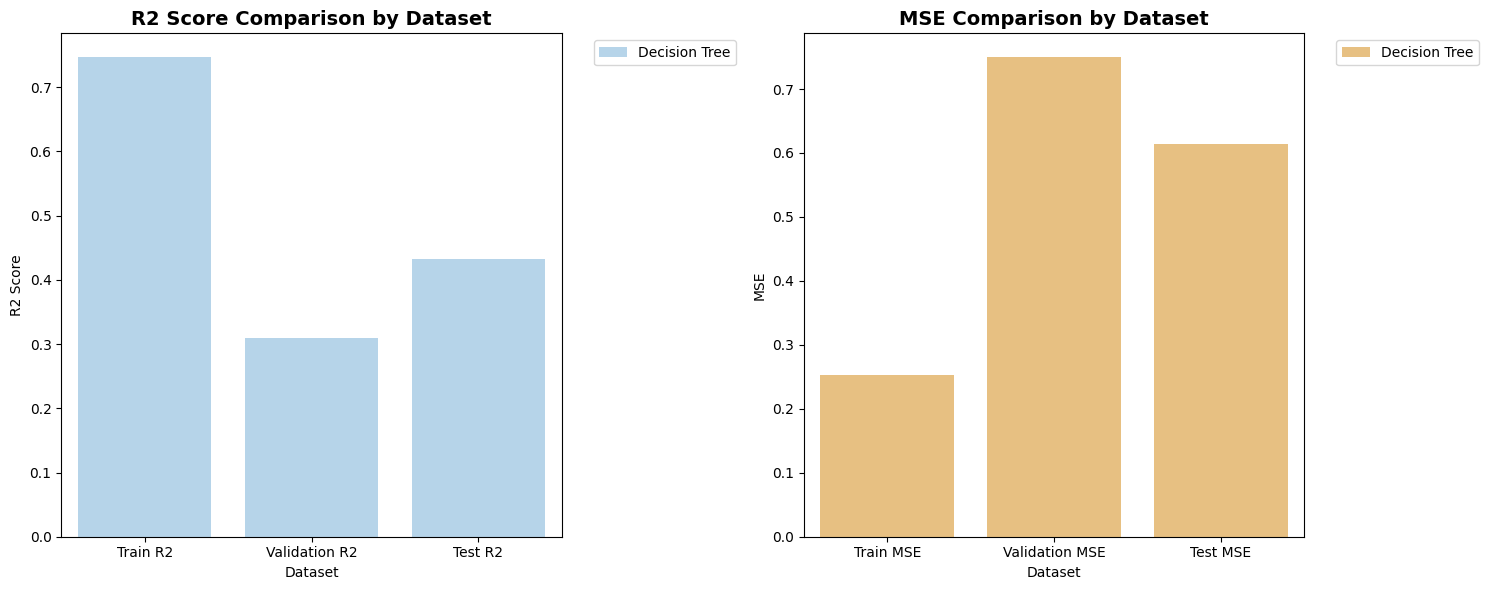

In [28]:
print("\n" + "="*60)
print("📊 알고리즘 성능 비교 결과 시각화")
print("="*60)

# R2 점수 비교 - 파스텔 색상 팔레트
r2_data = pd.DataFrame({
    'Algorithm': list(results.keys()),
    'Train R2': [results[alg]['train_r2'] for alg in results.keys()],
    'Validation R2': [results[alg]['val_r2'] for alg in results.keys()],
    'Test R2': [results[alg]['test_r2'] for alg in results.keys()]
})

# MSE 비교 - 파스텔 색상 팔레트
mse_data = pd.DataFrame({
    'Algorithm': list(results.keys()),
    'Train MSE': [results[alg]['train_mse'] for alg in results.keys()],
    'Validation MSE': [results[alg]['val_mse'] for alg in results.keys()],
    'Test MSE': [results[alg]['test_mse'] for alg in results.keys()]
})

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# R2 Score Comparison (x-axis: Dataset, hue: Algorithm)
r2_melted = r2_data.melt(id_vars=['Algorithm'], var_name='Dataset', value_name='R2 Score')
sns.barplot(data=r2_melted, x='Dataset', y='R2 Score', hue='Algorithm',
           palette=[pastel_colors['blue'], pastel_colors['green'], pastel_colors['pink'], pastel_colors['purple']],
           ax=axes[0])
axes[0].set_title('R2 Score Comparison by Dataset', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)  # x축 라벨 회전 없음
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 범례를 차트 밖으로

# MSE Comparison (x-axis: Dataset, hue: Algorithm)
mse_melted = mse_data.melt(id_vars=['Algorithm'], var_name='Dataset', value_name='MSE')
sns.barplot(data=mse_melted, x='Dataset', y='MSE', hue='Algorithm',
           palette=[pastel_colors['orange'], pastel_colors['coral'], pastel_colors['mint'], pastel_colors['yellow']],
           ax=axes[1])
axes[1].set_title('MSE Comparison by Dataset', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)  # x축 라벨 회전 없음
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 범례를 차트 밖으로

plt.tight_layout()
plt.show()

### 3.2 의사결정나무 분기 과정 시각화


📊 의사결정나무 분기 과정 및 불순도 시각화


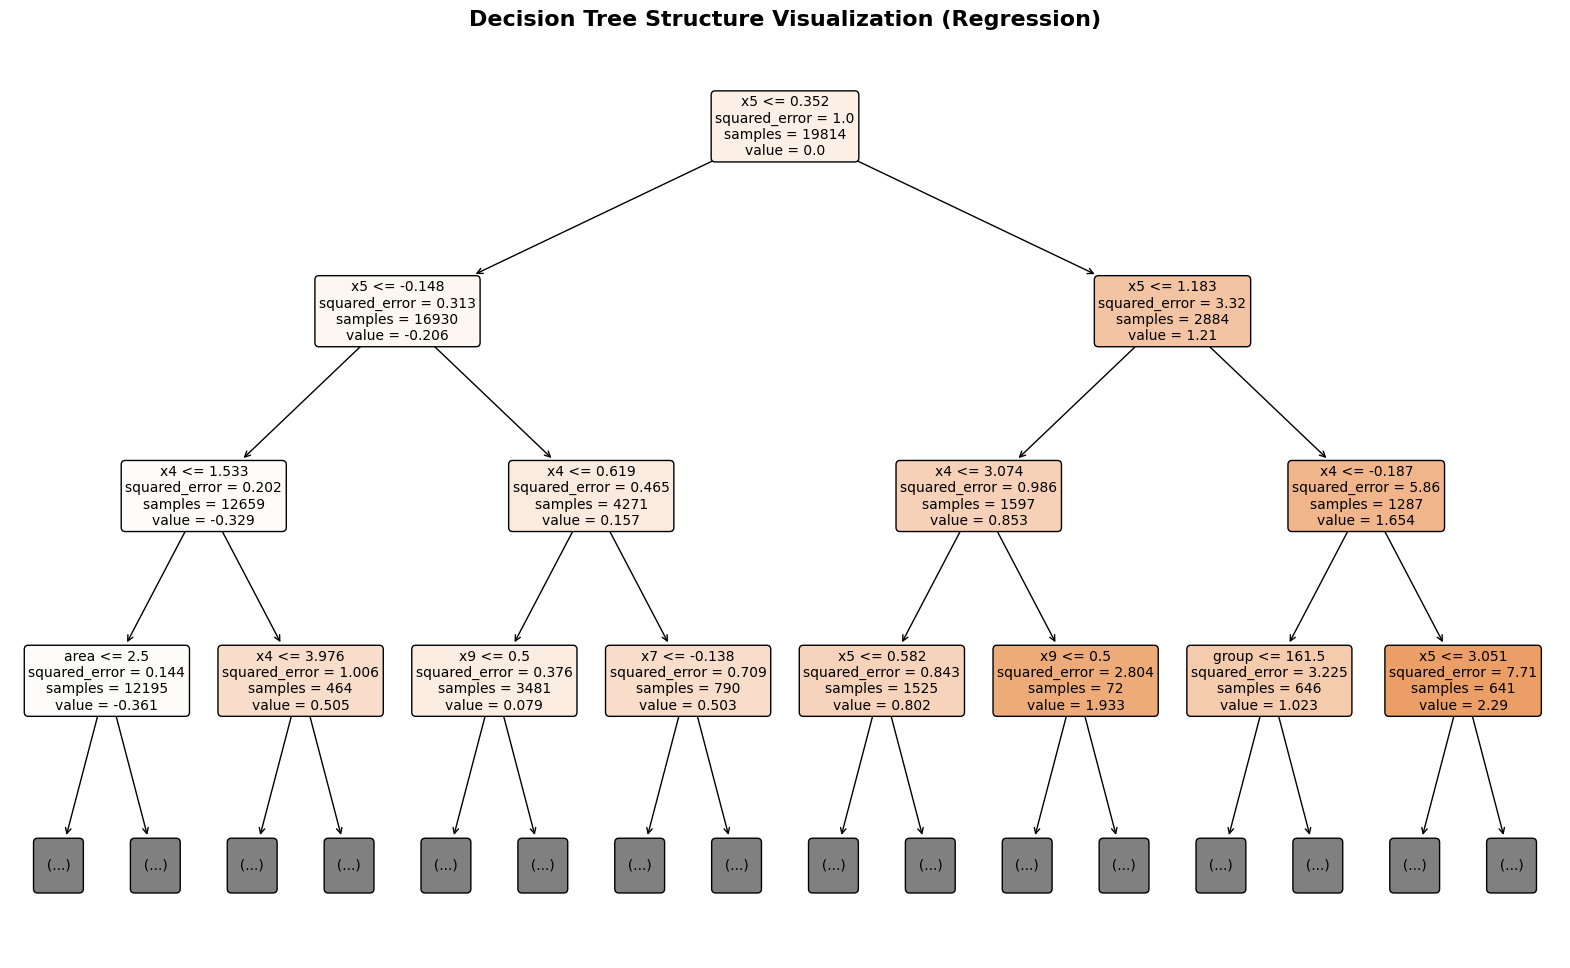

In [29]:
print("\n" + "="*60)
print("📊 의사결정나무 분기 과정 및 불순도 시각화")
print("="*60)

# 간단한 의사결정나무 모델 (시각화용)
simple_tree = DecisionTreeRegressor(max_depth=4, min_samples_split=20, random_state=42)
simple_tree.fit(X_train, y_train)

# 1. 트리 구조 시각화
plt.figure(figsize=(20, 12))
plot_tree(simple_tree,
          feature_names=all_features,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title('Decision Tree Structure Visualization (Regression)', fontsize=16, fontweight='bold')
plt.show()

📈 분석된 노드 수: 31
📊 트리 깊이: 4
🌿 잎 노드 수: 16

깊이별 통계:
   depth      mean       std  count
0      0  1.000000       NaN      1
1      1  1.816302  2.126348      2
2      2  1.878273  2.674353      4
3      3  2.102045  2.528105      8
4      4  2.090886  3.127973     16


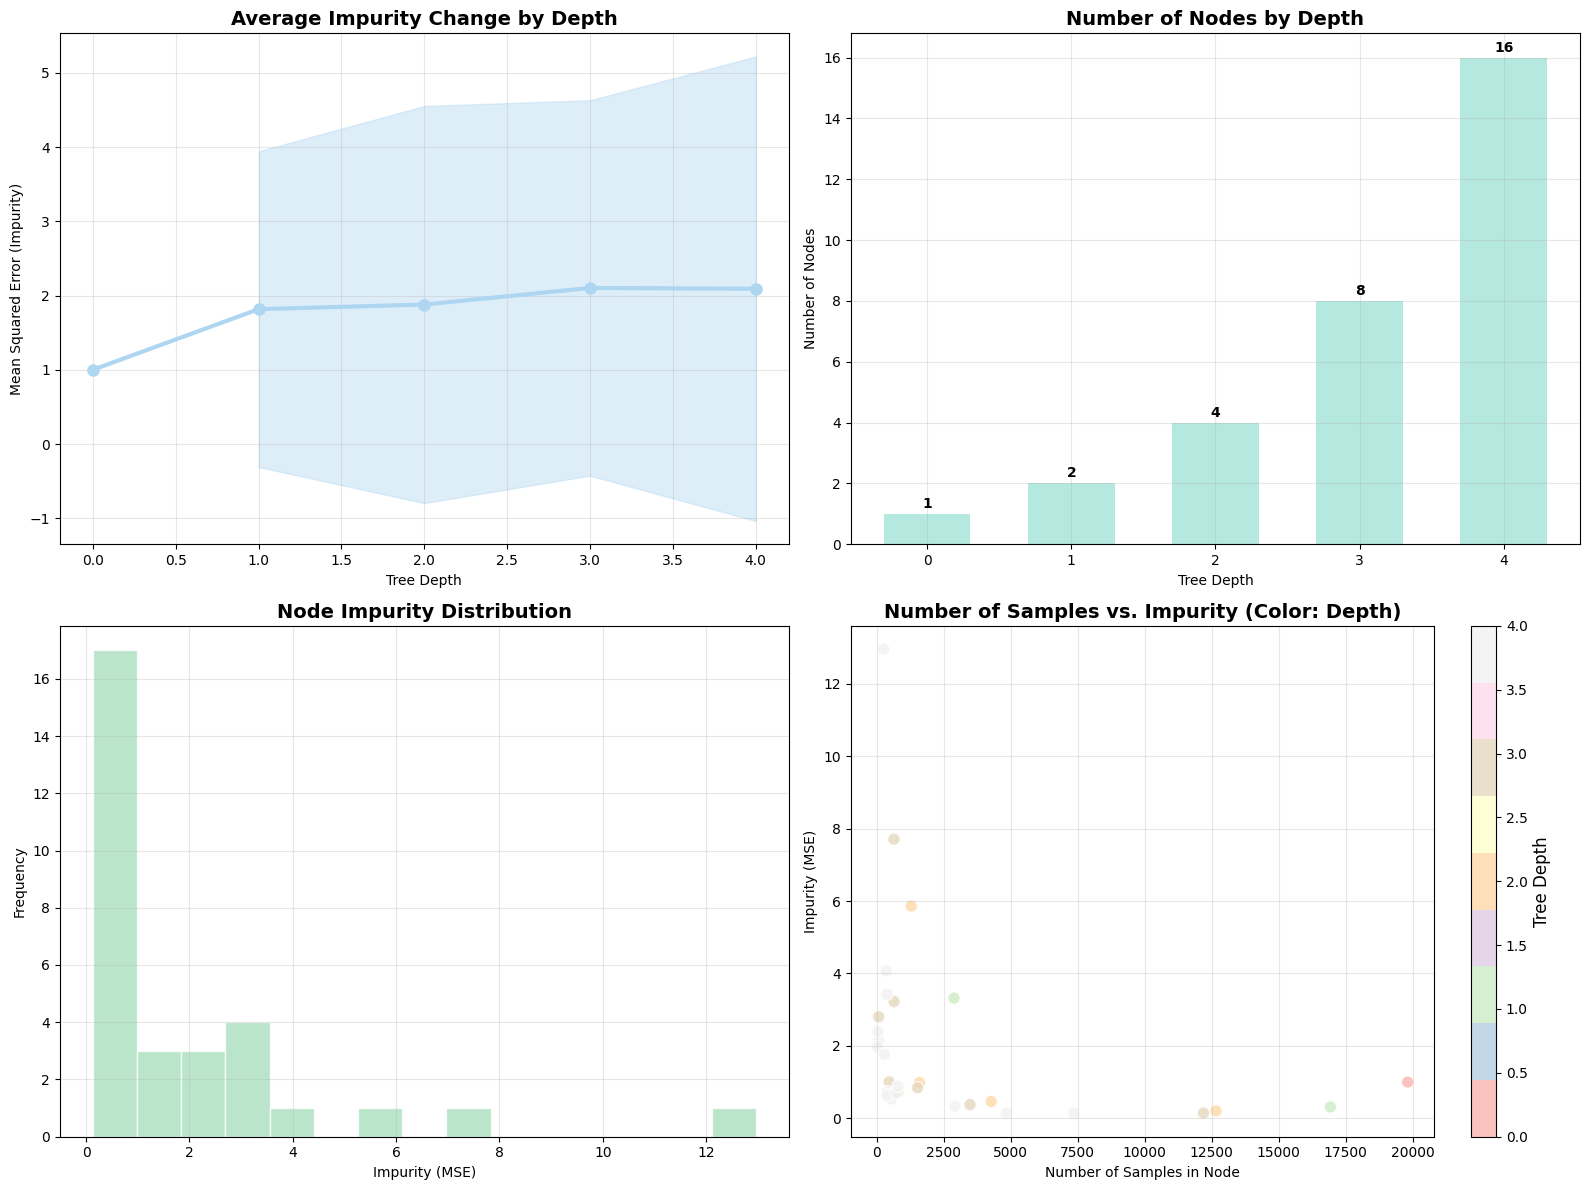


📊 상세 분석 결과:
   최대 불순도: 12.9607
   최소 불순도: 0.1323
   평균 불순도: 2.0134
   루트 노드 불순도: 1.0000

📈 변수별 분기 사용 빈도:
  x6: 5회
  x5: 5회
  x10: 2회
  area: 1회
  x8: 1회
  group: 1회


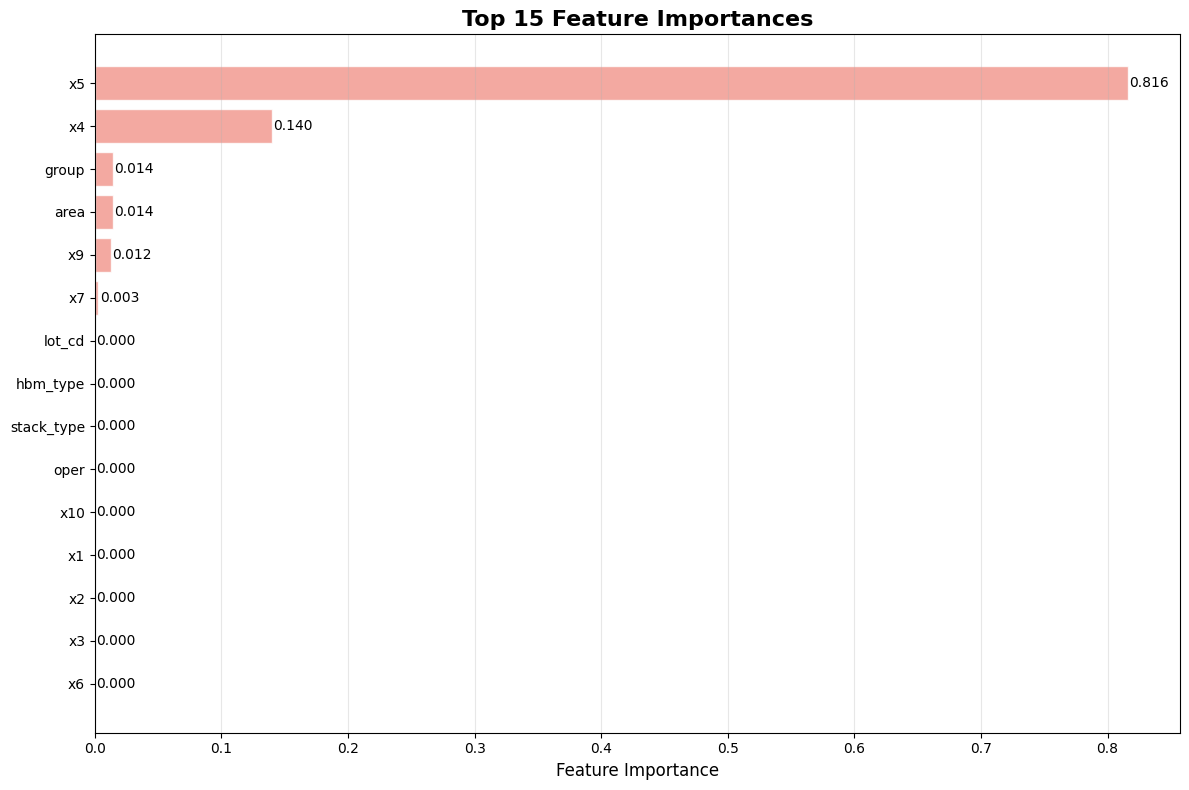

In [30]:
# 파스텔 색상 팔레트 정의
pastel_colors = {
    'blue': '#AED6F1',
    'green': '#A9DFBF',
    'pink': '#F5B7B1',
    'purple': '#D2B4DE',
    'orange': '#F8C471',
    'coral': '#F1948A',
    'mint': '#A3E4D7',
    'yellow': '#F9E79F'
}

# 간단한 의사결정나무 모델 (시각화용)
simple_tree = DecisionTreeRegressor(max_depth=4, min_samples_split=20, random_state=42)
simple_tree.fit(X_train, y_train)

def analyze_tree_impurity(tree_model, X_data, y_data):
    """트리의 불순도 변화를 분석하는 함수"""
    tree_ = tree_model.tree_

    # 각 노드의 정보 추출
    node_info = []

    def recurse(node_id, depth=0):
        if node_id != -1:  # 유효한 노드인 경우
            # 노드 정보
            impurity = tree_.impurity[node_id]
            n_samples = tree_.n_node_samples[node_id]
            value = tree_.value[node_id][0][0]

            # 분기 조건 (잎 노드가 아닌 경우)
            if tree_.children_left[node_id] != tree_.children_right[node_id]:
                feature = tree_.feature[node_id]
                threshold = tree_.threshold[node_id]
                feature_name = X_data.columns[feature]

                node_info.append({
                    'node_id': node_id,
                    'depth': depth,
                    'impurity': impurity,
                    'n_samples': n_samples,
                    'value': value,
                    'feature': feature_name,
                    'threshold': threshold,
                    'is_leaf': False
                })

                # 재귀적으로 자식 노드 방문
                recurse(tree_.children_left[node_id], depth + 1)
                recurse(tree_.children_right[node_id], depth + 1)
            else:
                # 잎 노드
                node_info.append({
                    'node_id': node_id,
                    'depth': depth,
                    'impurity': impurity,
                    'n_samples': n_samples,
                    'value': value,
                    'feature': None,
                    'threshold': None,
                    'is_leaf': True
                })

    recurse(0)
    return pd.DataFrame(node_info)

# 불순도 분석
node_analysis = analyze_tree_impurity(simple_tree, X_train, y_train)

# 데이터 확인 출력
print(f"📈 분석된 노드 수: {len(node_analysis)}")
print(f"📊 트리 깊이: {node_analysis['depth'].max()}")
print(f"🌿 잎 노드 수: {node_analysis['is_leaf'].sum()}")

# 깊이별 불순도 변화 시각화 (파스텔 색상)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 깊이별 평균 불순도 - 파스텔 블루
depth_impurity = node_analysis.groupby('depth')['impurity'].agg(['mean', 'std', 'count']).reset_index()
print(f"\n깊이별 통계:\n{depth_impurity}")

axes[0,0].plot(depth_impurity['depth'], depth_impurity['mean'], 'o-',
              linewidth=3, markersize=8, color=pastel_colors['blue'])
axes[0,0].fill_between(depth_impurity['depth'],
                       depth_impurity['mean'] - depth_impurity['std'],
                       depth_impurity['mean'] + depth_impurity['std'],
                       alpha=0.4, color=pastel_colors['blue'])
axes[0,0].set_title('Average Impurity Change by Depth', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel('Tree Depth')
axes[0,0].set_ylabel('Mean Squared Error (Impurity)')
axes[0,0].grid(True, alpha=0.3)

# 2. 깊이별 노드 수 - 파스텔 민트
axes[0,1].bar(depth_impurity['depth'], depth_impurity['count'],
             alpha=0.8, color=pastel_colors['mint'], width=0.6)
axes[0,1].set_title('Number of Nodes by Depth', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Tree Depth')
axes[0,1].set_ylabel('Number of Nodes')
axes[0,1].grid(True, alpha=0.3)
# 막대 위에 값 표시
for i, v in enumerate(depth_impurity['count']):
    axes[0,1].text(depth_impurity['depth'].iloc[i], v + 0.1, str(v),
                   ha='center', va='bottom', fontweight='bold')

# 3. 불순도 분포 - 파스텔 그린
axes[1,0].hist(node_analysis['impurity'], bins=15, alpha=0.8,
              color=pastel_colors['green'], edgecolor='white', linewidth=1)
axes[1,0].set_title('Node Impurity Distribution', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Impurity (MSE)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].grid(True, alpha=0.3)

# 4. 샘플 수 vs 불순도 - 파스텔 색상 그라디언트
scatter = axes[1,1].scatter(node_analysis['n_samples'], node_analysis['impurity'],
                           c=node_analysis['depth'], cmap='Pastel1', alpha=0.8,
                           s=80, edgecolors='white', linewidth=1)
axes[1,1].set_title('Number of Samples vs. Impurity (Color: Depth)', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Number of Samples in Node')
axes[1,1].set_ylabel('Impurity (MSE)')
axes[1,1].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1,1])
cbar.set_label('Tree Depth', fontsize=12)

plt.tight_layout()
plt.show()

# 추가 분석 정보 출력
print(f"\n📊 상세 분석 결과:")
print(f"   최대 불순도: {node_analysis['impurity'].max():.4f}")
print(f"   최소 불순도: {node_analysis['impurity'].min():.4f}")
print(f"   평균 불순도: {node_analysis['impurity'].mean():.4f}")
print(f"   루트 노드 불순도: {node_analysis[node_analysis['depth']==0]['impurity'].iloc[0]:.4f}")

# 중요 변수별 분기 빈도 분석
feature_usage = node_analysis[~node_analysis['is_leaf']]['feature'].value_counts()
print(f"\n📈 변수별 분기 사용 빈도:")
for feature, count in feature_usage.head(10).items():
    print(f"  {feature}: {count}회")

# 변수 중요도 시각화 - 파스텔 코랄
feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': simple_tree.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
bars = plt.barh(range(len(top_features)), top_features['importance'],
                color=pastel_colors['coral'], alpha=0.8, edgecolor='white', linewidth=1)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Feature Importances', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

# 막대 끝에 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 3.3 의사결정나무 Pruning 과정 시각화


✂️ 의사결정나무 Pruning 과정 시각화
📊 1단계: Pruning Path 분석 중...
   총 16699개의 alpha 임계값 발견
   Alpha 범위: 0.00000000 ~ 0.249557
   첫 5개 alpha 값: [0.00000000e+00 2.52145130e-20 2.80161256e-20 4.48258009e-20
 4.48258009e-20]

📈 2단계: 다양한 Alpha 값으로 모델 훈련 중...
   21개의 alpha 값에 대해 평가:
      Alpha 0.00000000: Train R2 = 0.9999, Val R2 = 0.2050, Nodes = 38315
      Alpha 0.00000001: Train R2 = 0.9999, Val R2 = 0.2050, Nodes = 31441
      Alpha 0.00000283: Train R2 = 0.9944, Val R2 = 0.2092, Nodes = 11279
      Alpha 0.00083991: Train R2 = 0.6989, Val R2 = 0.3811, Nodes = 279
      Alpha 0.24955696: Train R2 = 0.0000, Val R2 = -0.0000, Nodes = 1

🎯 3단계: 최적 하이퍼파라미터 선택...
   최적 Alpha: 0.00819230
   최적 Validation R2: 0.4406
   해당 Training R2: 0.4275
   최적 모델 복잡도: 21개 노드, 7 깊이

📊 4단계: Pruning 효과 시각화...


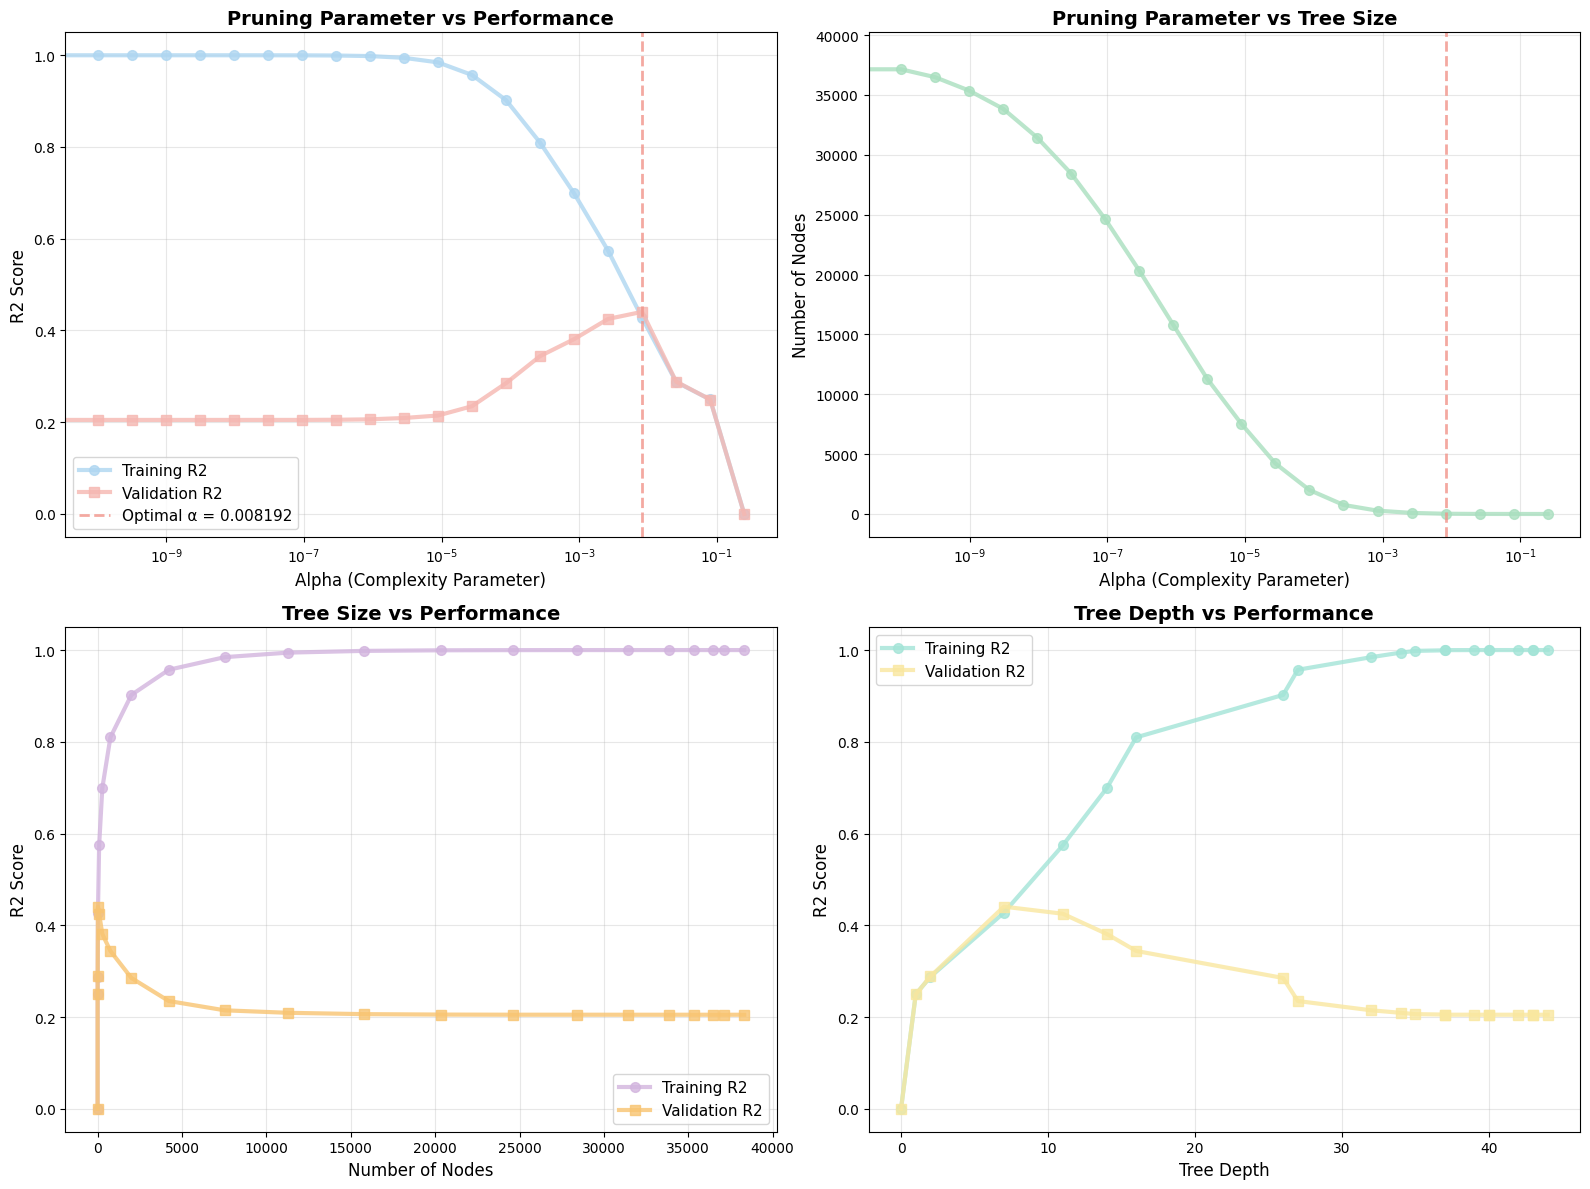


🏆 5단계: 최적 모델 재훈련 및 원본과 비교...

📊 원본 vs Pruned 트리 상세 비교:
        Model  Train R2  Validation R2  Test R2  Nodes  Depth
Original Tree    0.9999         0.2050   0.1480  38315     44
  Pruned Tree    0.4275         0.4406   0.3707     21      7

💡 Pruning 결과 분석 및 인사이트:
🔧 모델 복잡도 변화:
   노드 수: 38315 → 21 (+99.9% 감소)
   깊이: 44 → 7 (+84.1% 감소)

📈 성능 변화:
   Training R2: -0.5725
   Validation R2: +0.2356
   Test R2: +0.2227

🎯 과적합 분석 (Train R2 - Validation R2):
   Original Tree: 0.7950
   Pruned Tree: -0.0131
   과적합 개선: +0.8081

🏅 일반화 성능 (Test R2):
   ✅ Pruning이 일반화 성능을 0.2227 향상시켰습니다!

🎓 핵심 학습 포인트:
   1. Alpha 파라미터가 클수록 더 단순한 트리 생성
   2. Validation 성능을 기준으로 최적 복잡도 선택
   3. 적절한 pruning으로 과적합 방지 및 일반화 성능 향상
   4. Train-Validation 성능 차이로 과적합 정도 진단 가능


In [31]:
print("\n" + "="*60)
print("✂️ 의사결정나무 Pruning 과정 시각화")
print("="*60)

# ============================================================================
# 단계 1: Cost Complexity Pruning Path 계산
# ============================================================================
print("📊 1단계: Pruning Path 분석 중...")

# 전체 트리로부터 pruning path 계산
full_tree = DecisionTreeRegressor(random_state=42)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas  # 각 pruning 단계의 alpha 값들
impurities = path.impurities  # 각 단계의 불순도 값들

print(f"   총 {len(ccp_alphas)}개의 alpha 임계값 발견")
print(f"   Alpha 범위: {ccp_alphas.min():.8f} ~ {ccp_alphas.max():.6f}")
print(f"   첫 5개 alpha 값: {ccp_alphas[:5]}")

# ============================================================================
# 단계 2: Alpha 값 샘플링 및 모델 훈련
# ============================================================================
print(f"\n📈 2단계: 다양한 Alpha 값으로 모델 훈련 중...")

# 성능 저장 리스트 초기화
train_scores = []
val_scores = []
tree_sizes = []
tree_depths = []
alpha_values = []

# alpha=0부터 시작해서 로그 스케일로 샘플링
alpha_sample = np.logspace(np.log10(max(ccp_alphas[1], 1e-10)),
                          np.log10(ccp_alphas[-1]), 20)
alpha_sample = np.append([0], alpha_sample)  # alpha=0 추가 (가지치기 없음)

print(f"   {len(alpha_sample)}개의 alpha 값에 대해 평가:")

for i, alpha in enumerate(alpha_sample):
    # 현재 alpha로 트리 생성
    tree = DecisionTreeRegressor(ccp_alpha=alpha, random_state=42)
    tree.fit(X_train, y_train)

    # 예측 수행
    train_pred = tree.predict(X_train)
    val_pred = tree.predict(X_val)

    # 성능 지표 계산
    train_score = r2_score(y_train, train_pred)
    val_score = r2_score(y_val, val_pred)

    # 결과 저장
    train_scores.append(train_score)
    val_scores.append(val_score)
    tree_sizes.append(tree.tree_.node_count)
    tree_depths.append(tree.tree_.max_depth)
    alpha_values.append(alpha)

    # 진행상황 출력 (5개마다)
    if i % 5 == 0:
        print(f"      Alpha {alpha:.8f}: Train R2 = {train_score:.4f}, "
              f"Val R2 = {val_score:.4f}, Nodes = {tree.tree_.node_count}")

# ============================================================================
# 단계 3: 최적 Alpha 찾기
# ============================================================================
print(f"\n🎯 3단계: 최적 하이퍼파라미터 선택...")

best_alpha_idx = np.argmax(val_scores)
best_alpha = alpha_sample[best_alpha_idx]
best_val_score = val_scores[best_alpha_idx]
best_train_score = train_scores[best_alpha_idx]

print(f"   최적 Alpha: {best_alpha:.8f}")
print(f"   최적 Validation R2: {best_val_score:.4f}")
print(f"   해당 Training R2: {best_train_score:.4f}")
print(f"   최적 모델 복잡도: {tree_sizes[best_alpha_idx]}개 노드, {tree_depths[best_alpha_idx]} 깊이")

# ============================================================================
# 단계 4: Pruning 과정 시각화
# ============================================================================
print(f"\n📊 4단계: Pruning 효과 시각화...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Alpha vs Performance (most important graph)
axes[0,0].plot(alpha_sample, train_scores, 'o-', label='Training R2',
              linewidth=3, markersize=7, color=pastel_colors['blue'], alpha=0.8)
axes[0,0].plot(alpha_sample, val_scores, 's-', label='Validation R2',
              linewidth=3, markersize=7, color=pastel_colors['pink'], alpha=0.8)
axes[0,0].axvline(x=best_alpha, color=pastel_colors['coral'], linestyle='--',
                  linewidth=2, alpha=0.8, label=f'Optimal α = {best_alpha:.6f}')
axes[0,0].set_xlabel('Alpha (Complexity Parameter)', fontsize=12)
axes[0,0].set_ylabel('R2 Score', fontsize=12)
axes[0,0].set_title('Pruning Parameter vs Performance', fontweight='bold', fontsize=14)
axes[0,0].set_xscale('log')
axes[0,0].legend(fontsize=11)
axes[0,0].grid(True, alpha=0.3)

# 2. Alpha vs Tree Size
axes[0,1].plot(alpha_sample, tree_sizes, 'o-', color=pastel_colors['green'],
              linewidth=3, markersize=7, alpha=0.8)
axes[0,1].axvline(x=best_alpha, color=pastel_colors['coral'], linestyle='--',
                  linewidth=2, alpha=0.8)
axes[0,1].set_xlabel('Alpha (Complexity Parameter)', fontsize=12)
axes[0,1].set_ylabel('Number of Nodes', fontsize=12)
axes[0,1].set_title('Pruning Parameter vs Tree Size', fontweight='bold', fontsize=14)
axes[0,1].set_xscale('log')
axes[0,1].grid(True, alpha=0.3)

# 3. Tree Size vs Performance
axes[1,0].plot(tree_sizes, train_scores, 'o-', label='Training R2',
              linewidth=3, markersize=7, color=pastel_colors['purple'], alpha=0.8)
axes[1,0].plot(tree_sizes, val_scores, 's-', label='Validation R2',
              linewidth=3, markersize=7, color=pastel_colors['orange'], alpha=0.8)
axes[1,0].set_xlabel('Number of Nodes', fontsize=12)
axes[1,0].set_ylabel('R2 Score', fontsize=12)
axes[1,0].set_title('Tree Size vs Performance', fontweight='bold', fontsize=14)
axes[1,0].legend(fontsize=11)
axes[1,0].grid(True, alpha=0.3)

# 4. Tree Depth vs Performance
axes[1,1].plot(tree_depths, train_scores, 'o-', label='Training R2',
              linewidth=3, markersize=7, color=pastel_colors['mint'], alpha=0.8)
axes[1,1].plot(tree_depths, val_scores, 's-', label='Validation R2',
              linewidth=3, markersize=7, color=pastel_colors['yellow'], alpha=0.8)
axes[1,1].set_xlabel('Tree Depth', fontsize=12)
axes[1,1].set_ylabel('R2 Score', fontsize=12)
axes[1,1].set_title('Tree Depth vs Performance', fontweight='bold', fontsize=14)
axes[1,1].legend(fontsize=11)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 단계 5: 최적 모델 재훈련 및 비교
# ============================================================================
print(f"\n🏆 5단계: 최적 모델 재훈련 및 원본과 비교...")

# 최적 alpha로 모델 재훈련
best_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42)
best_tree.fit(X_train, y_train)

# 원본 트리 (pruning 없음)
original_tree = DecisionTreeRegressor(random_state=42)
original_tree.fit(X_train, y_train)

# 성능 비교 데이터 생성
comparison_data = {
    'Model': ['Original Tree', 'Pruned Tree'],
    'Train R2': [
        r2_score(y_train, original_tree.predict(X_train)),
        r2_score(y_train, best_tree.predict(X_train))
    ],
    'Validation R2': [
        r2_score(y_val, original_tree.predict(X_val)),
        r2_score(y_val, best_tree.predict(X_val))
    ],
    'Test R2': [
        r2_score(y_test, original_tree.predict(X_test)),
        r2_score(y_test, best_tree.predict(X_test))
    ],
    'Nodes': [original_tree.tree_.node_count, best_tree.tree_.node_count],
    'Depth': [original_tree.tree_.max_depth, best_tree.tree_.max_depth]
}

comparison_df = pd.DataFrame(comparison_data)

print(f"\n📊 원본 vs Pruned 트리 상세 비교:")
print("="*50)
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

# ============================================================================
# 단계 6: 결과 해석 및 인사이트
# ============================================================================
print(f"\n💡 Pruning 결과 분석 및 인사이트:")
print("="*50)

# 복잡도 감소 효과
node_reduction = ((original_tree.tree_.node_count - best_tree.tree_.node_count) /
                 original_tree.tree_.node_count * 100)
depth_reduction = ((original_tree.tree_.max_depth - best_tree.tree_.max_depth) /
                  original_tree.tree_.max_depth * 100)

print(f"🔧 모델 복잡도 변화:")
print(f"   노드 수: {original_tree.tree_.node_count} → {best_tree.tree_.node_count} "
      f"({node_reduction:+.1f}% 감소)")
print(f"   깊이: {original_tree.tree_.max_depth} → {best_tree.tree_.max_depth} "
      f"({depth_reduction:+.1f}% 감소)")

# 성능 변화 분석
train_r2_change = comparison_df.loc[1, 'Train R2'] - comparison_df.loc[0, 'Train R2']
val_r2_change = comparison_df.loc[1, 'Validation R2'] - comparison_df.loc[0, 'Validation R2']
test_r2_change = comparison_df.loc[1, 'Test R2'] - comparison_df.loc[0, 'Test R2']

print(f"\n📈 성능 변화:")
print(f"   Training R2: {train_r2_change:+.4f}")
print(f"   Validation R2: {val_r2_change:+.4f}")
print(f"   Test R2: {test_r2_change:+.4f}")

# 과적합 진단
overfitting_original = comparison_df.loc[0, 'Train R2'] - comparison_df.loc[0, 'Validation R2']
overfitting_pruned = comparison_df.loc[1, 'Train R2'] - comparison_df.loc[1, 'Validation R2']

print(f"\n🎯 과적합 분석 (Train R2 - Validation R2):")
print(f"   Original Tree: {overfitting_original:.4f}")
print(f"   Pruned Tree: {overfitting_pruned:.4f}")
print(f"   과적합 개선: {overfitting_original - overfitting_pruned:+.4f}")

# 일반화 성능
print(f"\n🏅 일반화 성능 (Test R2):")
if test_r2_change > 0:
    print(f"   ✅ Pruning이 일반화 성능을 {test_r2_change:.4f} 향상시켰습니다!")
else:
    print(f"   ⚠️ Pruning 후 일반화 성능이 {abs(test_r2_change):.4f} 감소했습니다.")

print(f"\n🎓 핵심 학습 포인트:")
print(f"   1. Alpha 파라미터가 클수록 더 단순한 트리 생성")
print(f"   2. Validation 성능을 기준으로 최적 복잡도 선택")
print(f"   3. 적절한 pruning으로 과적합 방지 및 일반화 성능 향상")
print(f"   4. Train-Validation 성능 차이로 과적합 정도 진단 가능")

## 🧠 4. 인공신경망

### 4.1 인공신경망 이용을 위한 기본 설정

In [32]:
# 디바이스 설정 (GPU 사용 가능한지 확인)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 사용 디바이스: {device}")

# PyTorch 버전 확인
print(f"🔥 PyTorch 버전: {torch.__version__}")

# 재현 가능성을 위한 시드 설정
torch.manual_seed(42)
np.random.seed(42)

🖥️ 사용 디바이스: cuda
🔥 PyTorch 버전: 2.1.0


### 4.2 Dataset & DataLoader class 정의

In [33]:
# ======================================================================
# PyTorch Dataset 클래스 정의 및 인스턴스 생성
# ======================================================================

print("="*50)
print(f"🏗️ PyTorch Dataset 클래스 정의")
print("="*50)

class SKhynixDataset(Dataset):
    def __init__(self, X, y, transform=None):
        """
        Args:
            X (numpy.ndarray or pandas.DataFrame): 입력 특성
            y (numpy.ndarray or pandas.Series): 타겟 변수
            transform (callable, optional): 데이터 변환 함수
        """
        # pandas DataFrame/Series인 경우 numpy로 변환
        if hasattr(X, 'values'):
            self.X = X.values
        else:
            self.X = X

        if hasattr(y, 'values'):
            self.y = y.values
        else:
            self.y = y

        # 데이터 타입을 float32로 변환 (PyTorch 기본)
        self.X = self.X.astype(np.float32)
        self.y = self.y.astype(np.float32)

        print(f"   📊 Dataset 생성 완료:")
        print(f"      샘플 수: {len(self.X)}")
        print(f"      특성 수: {self.X.shape[1]}")
        print(f"      X shape: {self.X.shape}")
        print(f"      y shape: {self.y.shape}")

    def __len__(self):
        """데이터셋 크기 반환"""
        return len(self.X)

    def __getitem__(self, idx):
        """인덱스에 해당하는 데이터 반환"""
        # 특정 인덱스의 데이터 추출
        sample_x = self.X[idx]
        sample_y = self.y[idx]

        # PyTorch 텐서로 변환
        sample_x = torch.FloatTensor(sample_x)
        sample_y = torch.FloatTensor([sample_y])  # 스칼라를 1D 텐서로

        return sample_x, sample_y

# Train Dataset
train_dataset = SKhynixDataset(X_train, y_train)

# Validation Dataset
val_dataset = SKhynixDataset(X_val, y_val)

# Test Dataset
test_dataset = SKhynixDataset(X_test, y_test)


🏗️ PyTorch Dataset 클래스 정의
   📊 Dataset 생성 완료:
      샘플 수: 19814
      특성 수: 16
      X shape: (19814, 16)
      y shape: (19814,)
   📊 Dataset 생성 완료:
      샘플 수: 5661
      특성 수: 16
      X shape: (5661, 16)
      y shape: (5661,)
   📊 Dataset 생성 완료:
      샘플 수: 2831
      특성 수: 16
      X shape: (2831, 16)
      y shape: (2831,)


In [34]:
# ======================================================================
# PyTorch DataLoader 클래스 래핑
# ======================================================================

batch_size = 32
num_workers = 0

# 훈련용 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,                          # 훈련시 데이터 섞기
    num_workers=num_workers,               # 멀티프로세싱 워커 수
    drop_last=True,                        # 마지막 불완전 배치 제거 (일관된 배치 크기)
)

# 검증용 DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,                         # 검증시에는 섞지 않음
    num_workers=num_workers,
    drop_last=False,                       # 검증에서는 모든 데이터 사용
)

# 테스트용 DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,                         # 테스트시에는 섞지 않음
    num_workers=num_workers,
    drop_last=False,                       # 테스트에서는 모든 데이터 사용
)

print(f"✅ DataLoader 생성 완료!")
print(f"   Train: {len(train_loader)} 배치")
print(f"   Val:   {len(val_loader)} 배치")
print(f"   Test:  {len(test_loader)} 배치")

✅ DataLoader 생성 완료!
   Train: 619 배치
   Val:   177 배치
   Test:  89 배치


### 4.3 신경망 모델 정의

In [35]:
# ======================================================================
# 모델 정의 (단층 vs 다층 퍼셉트론)
# ======================================================================
print("="*50)
print(f"🧠 신경망 모델 정의")
print("="*50)

class SingleLayerPerceptron(nn.Module):
    """
    단층 퍼셉트론 (Single Layer Perceptron)
    - 입력층 → 선형층 → 출력층
    - 활성화 함수 없음 (순수 선형 변환)
    - 선형 관계만 학습 가능
    """
    def __init__(self, input_size):
        super(SingleLayerPerceptron, self).__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        # 순전파 과정
        return self.linear(x)

    def get_weights_bias(self):
        # 모델 가중치 및 bias 반환
        return self.linear.weight.data, self.linear.bias.data

class MultiLayerPerceptron(nn.Module):
    """
    다층 퍼셉트론 (Multi Layer Perceptron)
    - 입력층 → 은닉층1 → 은닉층2 → 출력층
    - ReLU 활성화 함수 사용
    - 비선형 관계 학습 가능
    """
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, dropout_rate=0.2):
        super(MultiLayerPerceptron, self).__init__()

        # 층별 정의
        self.layer1 = nn.Linear(input_size, hidden1_size)
        self.layer2 = nn.Linear(hidden1_size, hidden2_size)
        self.layer3 = nn.Linear(hidden2_size, 1)

        # 활성화 함수 및 정규화
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # 첫 번째 은닉층
        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        # 두 번째 은닉층
        x = self.layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        # 출력층
        x = self.layer3(x)
        return x

    def get_layer_info(self):
        # 층별 정보 반환
        info = {}
        for name, module in self.named_modules():
            if isinstance(module, nn.Linear):
                info[name] = {
                    'weight_shape': module.weight.shape,
                    'bias_shape': module.bias.shape if module.bias is not None else None,
                    'parameters': module.weight.numel() + (module.bias.numel() if module.bias is not None else 0)
                }
        return info

# 모델 인스턴스 생성
input_size = len(all_features)

# 단층 퍼셉트론
slp_model = SingleLayerPerceptron(input_size).to(device)

# 다층 퍼셉트론
mlp_model = MultiLayerPerceptron(input_size,
                                hidden1_size=64,
                                hidden2_size=32,
                                dropout_rate=0.2).to(device)

print(f"\n📊 모델 구조 비교:")
print(f"\n1️⃣ 단층 퍼셉트론 (Single Layer Perceptron):")
print(slp_model)

print(f"\n2️⃣ 다층 퍼셉트론 (Multi Layer Perceptron):")
print(mlp_model)

# 파라미터 수 비교
slp_params = sum(p.numel() for p in slp_model.parameters())
mlp_params = sum(p.numel() for p in mlp_model.parameters())

print(f"\n📈 파라미터 수 비교:")
print(f"   단층 퍼셉트론: {slp_params:,}개")
print(f"   다층 퍼셉트론: {mlp_params:,}개")
print(f"   비율: {mlp_params/slp_params:.1f}배")

# 다층 퍼셉트론 상세 정보
print(f"\n🔍 다층 퍼셉트론 층별 상세:")
mlp_info = mlp_model.get_layer_info()
for layer_name, info in mlp_info.items():
    print(f"   {layer_name}: {info['weight_shape']} → {info['parameters']:,}개 파라미터")


🧠 신경망 모델 정의

📊 모델 구조 비교:

1️⃣ 단층 퍼셉트론 (Single Layer Perceptron):
SingleLayerPerceptron(
  (linear): Linear(in_features=16, out_features=1, bias=True)
)

2️⃣ 다층 퍼셉트론 (Multi Layer Perceptron):
MultiLayerPerceptron(
  (layer1): Linear(in_features=16, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

📈 파라미터 수 비교:
   단층 퍼셉트론: 17개
   다층 퍼셉트론: 3,201개
   비율: 188.3배

🔍 다층 퍼셉트론 층별 상세:
   layer1: torch.Size([64, 16]) → 1,088개 파라미터
   layer2: torch.Size([32, 64]) → 2,080개 파라미터
   layer3: torch.Size([1, 32]) → 33개 파라미터


### 4.4 손실함수 및 옵티마이저 설정

In [36]:
print("="*50)
print(f"⚙️ 6단계: 손실함수 및 옵티마이저 설정")
print("="*50)

# 손실함수 (MSE Loss)
criterion = nn.MSELoss()

# 옵티마이저 (Adam)
learning_rate = 0.0001
optimize_slp = optim.Adam(slp_model.parameters(), lr=learning_rate)
optimize_mlp = optim.Adam(mlp_model.parameters(), lr=learning_rate)

print("\n")
print(f"📉 손실함수: {criterion}")
print(f"📚 학습률: {learning_rate}")
print(f"🔧 옵티마이저: {optimize_slp}")

⚙️ 6단계: 손실함수 및 옵티마이저 설정


📉 손실함수: MSELoss()
📚 학습률: 0.0001
🔧 옵티마이저: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


### 4.5 모델 학습

In [37]:
# ======================================================================
# SLP 모델 훈련
# ======================================================================

print(f"\n🎯 7단계: 모델 훈련")
print("="*50)

# 훈련 과정 기록용 리스트
slp_train_losses = []
slp_val_losses = []
slp_train_r2_scores = []
slp_val_r2_scores = []

num_epochs = 20
log_epochs = 5

print(f"🏃훈련 시작 (에포크: {num_epochs})")

for epoch in range(num_epochs):
    # ========== 훈련 단계 ==========
    slp_model.train()  # 훈련 모드
    epoch_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        # 데이터를 디바이스로 이동
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 1. 그래디언트 초기화
        optimize_slp.zero_grad()

        # 2. 순전파
        predictions = slp_model(batch_X).squeeze()

        # 3. 손실 계산
        loss = criterion(predictions, batch_y.squeeze())

        # 4. 역전파
        loss.backward()

        # 5. 파라미터 업데이트
        optimize_slp.step()

        epoch_train_loss += loss.item()

    # 평균 훈련 손실
    avg_train_loss = epoch_train_loss / len(train_loader)

    # ========== 검증 단계 ==========
    slp_model.eval()  # 평가 모드
    epoch_val_loss = 0.0

    with torch.no_grad():  # 그래디언트 계산 비활성화
        for batch_X, batch_y in val_loader:
            # 데이터를 디바이스로 이동
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = slp_model(batch_X).squeeze()
            loss = criterion(predictions, batch_y.squeeze())
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)

    # ========== R2 점수 계산 ==========
    with torch.no_grad():
        # 전체 데이터로 예측 (DataLoader 사용)
        slp_model.eval()

        # Train 예측
        train_predictions = []
        train_targets = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            pred = slp_model(batch_x).squeeze().cpu().numpy()
            target = batch_y.squeeze().cpu().numpy()
            train_predictions.extend(pred)
            train_targets.extend(target)

        # Validation 예측
        val_predictions = []
        val_targets = []
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            pred = slp_model(batch_x).squeeze().cpu().numpy()
            target = batch_y.squeeze().cpu().numpy()
            val_predictions.extend(pred)
            val_targets.extend(target)

        train_r2 = r2_score(train_targets, train_predictions)
        val_r2 = r2_score(val_targets, val_predictions)

    # 기록 저장
    slp_train_losses.append(avg_train_loss)
    slp_val_losses.append(avg_val_loss)
    slp_train_r2_scores.append(train_r2)
    slp_val_r2_scores.append(val_r2)

    # 진행상황 출력
    if (epoch + 1) % log_epochs == 0:
        print(f"   Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | "
              f"Train R2: {train_r2:.4f} | Val R2: {val_r2:.4f}")

print(f"\n✅ 모델 학습 완료!")


🎯 7단계: 모델 훈련
🏃훈련 시작 (에포크: 20)
   Epoch [  5/20] | Train Loss: 139.941280 | Val Loss: 99.172075 | Train R2: -96.8973 | Val R2: -90.2748
   Epoch [ 10/20] | Train Loss: 6.607004 | Val Loss: 4.115308 | Train R2: -2.9990 | Val R2: -2.7879
   Epoch [ 15/20] | Train Loss: 0.878967 | Val Loss: 0.935615 | Train R2: 0.1408 | Val R2: 0.1387
   Epoch [ 20/20] | Train Loss: 0.734712 | Val Loss: 0.777095 | Train R2: 0.2733 | Val R2: 0.2845

✅ 모델 학습 완료!


In [38]:
# ======================================================================
# MLP 모델 훈련
# ======================================================================

print(f"\n🎯 7단계: 모델 훈련")
print("="*50)

# 훈련 과정 기록용 리스트
mlp_train_losses = []
mlp_val_losses = []
mlp_train_r2_scores = []
mlp_val_r2_scores = []

num_epochs = 20
log_epochs = 5

print(f"훈련 시작 (에포크: {num_epochs})")

for epoch in range(num_epochs):
    # ========== 훈련 단계 ==========
    mlp_model.train()  # 훈련 모드
    epoch_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        # 데이터를 디바이스로 이동
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 1. 그래디언트 초기화
        optimize_mlp.zero_grad()

        # 2. 순전파
        predictions = mlp_model(batch_X).squeeze()

        # 3. 손실 계산
        loss = criterion(predictions, batch_y.squeeze())

        # 4. 역전파
        loss.backward()

        # 5. 파라미터 업데이트
        optimize_mlp.step()

        epoch_train_loss += loss.item()

    # 평균 훈련 손실
    avg_train_loss = epoch_train_loss / len(train_loader)

    # ========== 검증 단계 ==========
    mlp_model.eval()  # 평가 모드
    epoch_val_loss = 0.0

    with torch.no_grad():  # 그래디언트 계산 비활성화
        for batch_X, batch_y in val_loader:
            # 데이터를 디바이스로 이동
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = mlp_model(batch_X).squeeze()
            loss = criterion(predictions, batch_y.squeeze())
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)

    # ========== R2 점수 계산 ==========
    with torch.no_grad():
        # 전체 데이터로 예측 (DataLoader 사용)
        mlp_model.eval()

        # Train 예측
        train_predictions = []
        train_targets = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            pred = mlp_model(batch_x).squeeze().cpu().numpy()
            target = batch_y.squeeze().cpu().numpy()
            train_predictions.extend(pred)
            train_targets.extend(target)

        # Validation 예측
        val_predictions = []
        val_targets = []
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            pred = mlp_model(batch_x).squeeze().cpu().numpy()
            target = batch_y.squeeze().cpu().numpy()
            val_predictions.extend(pred)
            val_targets.extend(target)

        train_r2 = r2_score(train_targets, train_predictions)
        val_r2 = r2_score(val_targets, val_predictions)

    # 기록 저장
    mlp_train_losses.append(avg_train_loss)
    mlp_val_losses.append(avg_val_loss)
    mlp_train_r2_scores.append(train_r2)
    mlp_val_r2_scores.append(val_r2)

    # 진행상황 출력
    if (epoch + 1) % log_epochs == 0:
        print(f"   Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | "
              f"Train R2: {train_r2:.4f} | Val R2: {val_r2:.4f}")

print(f"\n✅ 모델 학습 완료!")


🎯 7단계: 모델 훈련
훈련 시작 (에포크: 20)
   Epoch [  5/20] | Train Loss: 1.487537 | Val Loss: 1.095162 | Train R2: -0.0123 | Val R2: -0.0082
   Epoch [ 10/20] | Train Loss: 1.031273 | Val Loss: 1.088334 | Train R2: -0.0029 | Val R2: -0.0020
   Epoch [ 15/20] | Train Loss: 1.003343 | Val Loss: 1.085485 | Train R2: 0.0004 | Val R2: 0.0007
   Epoch [ 20/20] | Train Loss: 0.998570 | Val Loss: 1.080248 | Train R2: 0.0062 | Val R2: 0.0055

✅ 모델 학습 완료!


📊훈련 과정 비교 시각화


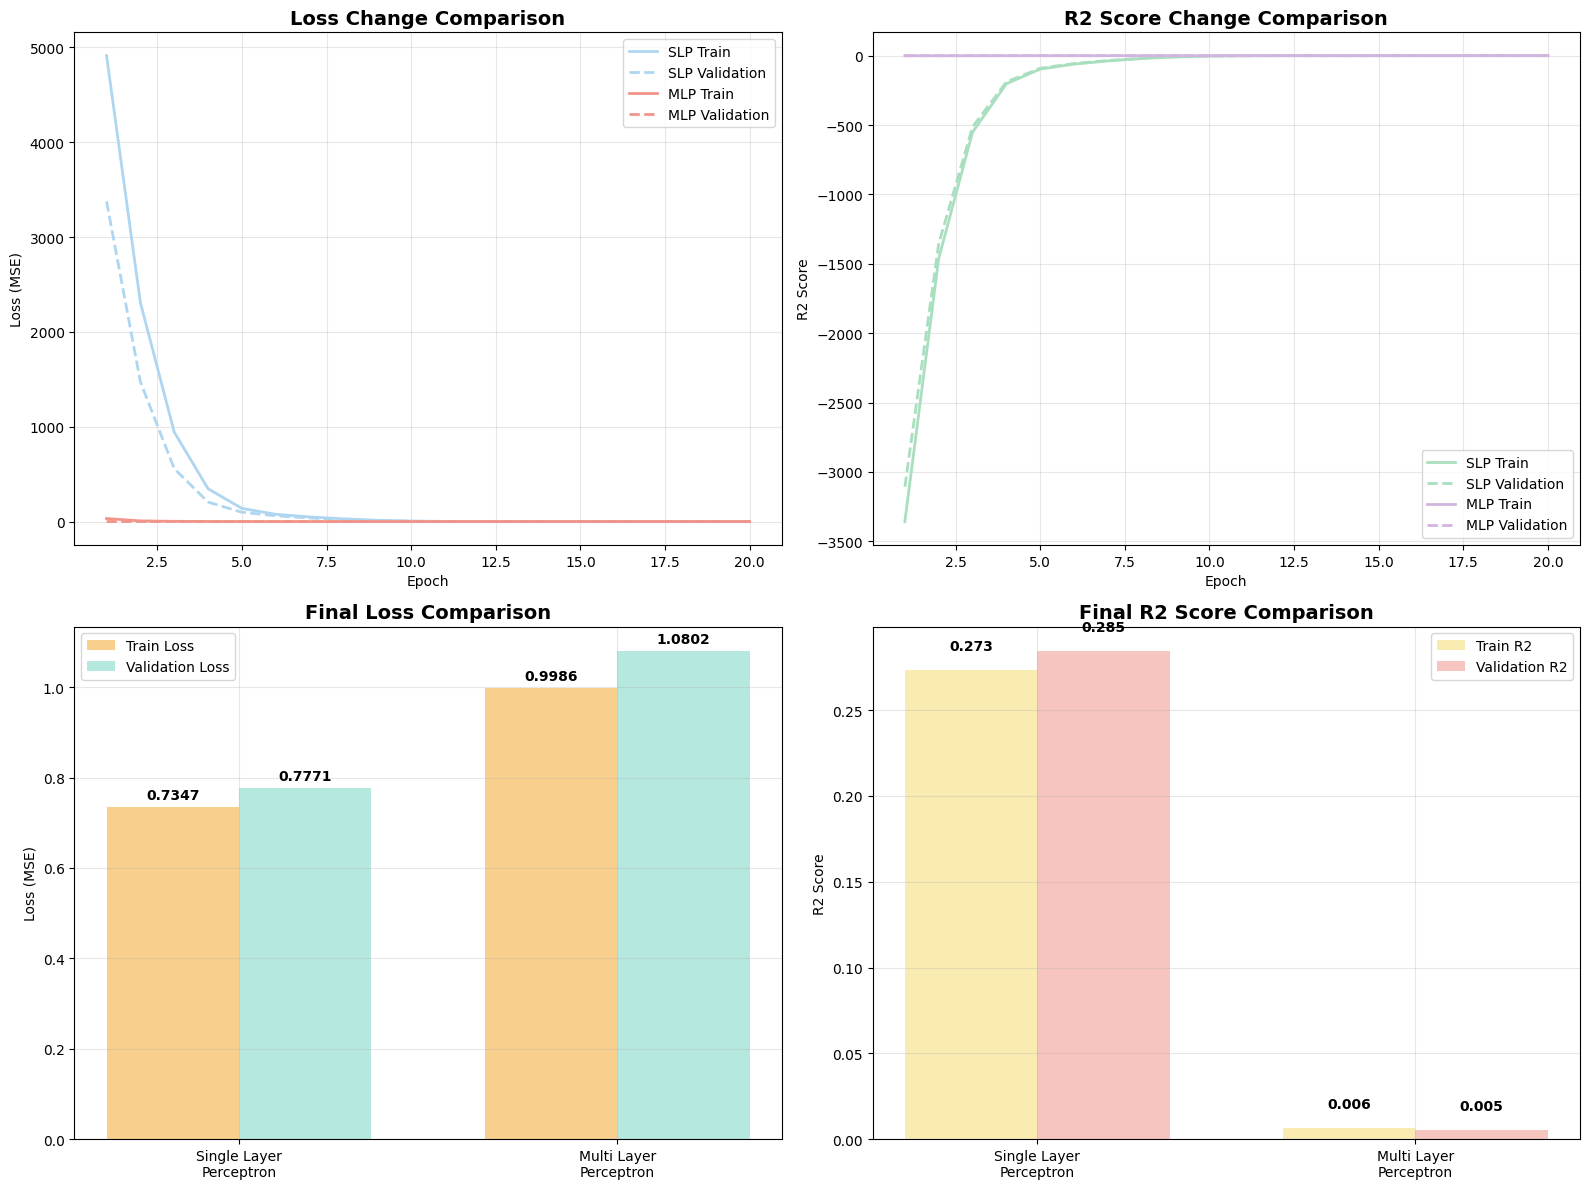


 훈련 요약:
모델                   최종 Train R2     최종 Val R2       최종 Train Loss   최종 Val Loss    
-------------------------------------------------------------------------------------
단층 퍼셉트론              0.2733          0.2845          0.734712        0.777095       
다층 퍼셉트론              0.0062          0.0055          0.998570        1.080248       


In [39]:
# ======================================================================
# 훈련 과정 비교 시각화
# ======================================================================

print("="*50)
print(f"📊훈련 과정 비교 시각화")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loss 비교
epochs_slp = range(1, len(slp_train_losses) + 1)
epochs_mlp = range(1, len(mlp_train_losses) + 1)

axes[0,0].plot(epochs_slp, slp_train_losses, label='SLP Train',
              color=pastel_colors['blue'], linewidth=2, linestyle='-')
axes[0,0].plot(epochs_slp, slp_val_losses, label='SLP Validation',
              color=pastel_colors['blue'], linewidth=2, linestyle='--')
axes[0,0].plot(epochs_mlp, mlp_train_losses, label='MLP Train',
              color=pastel_colors['coral'], linewidth=2, linestyle='-')
axes[0,0].plot(epochs_mlp, mlp_val_losses, label='MLP Validation',
              color=pastel_colors['coral'], linewidth=2, linestyle='--')
axes[0,0].set_title('Loss Change Comparison', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss (MSE)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. R2 Score 비교
axes[0,1].plot(epochs_slp, slp_train_r2_scores, label='SLP Train',
              color=pastel_colors['green'], linewidth=2, linestyle='-')
axes[0,1].plot(epochs_slp, slp_val_r2_scores, label='SLP Validation',
              color=pastel_colors['green'], linewidth=2, linestyle='--')
axes[0,1].plot(epochs_mlp, mlp_train_r2_scores, label='MLP Train',
              color=pastel_colors['purple'], linewidth=2, linestyle='-')
axes[0,1].plot(epochs_mlp, mlp_val_r2_scores, label='MLP Validation',
              color=pastel_colors['purple'], linewidth=2, linestyle='--')
axes[0,1].set_title('R2 Score Change Comparison', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('R2 Score')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. 최종 Loss 비교 (막대 그래프)
models = ['Single Layer\nPerceptron', 'Multi Layer\nPerceptron']
final_train_loss = [slp_train_losses[-1], mlp_train_losses[-1]]
final_val_loss = [slp_val_losses[-1], mlp_val_losses[-1]]

x_pos = np.arange(len(models))
width = 0.35

bars1 = axes[1,0].bar(x_pos - width/2, final_train_loss, width, label='Train Loss',
                     color=pastel_colors['orange'], alpha=0.8)
bars2 = axes[1,0].bar(x_pos + width/2, final_val_loss, width, label='Validation Loss',
                     color=pastel_colors['mint'], alpha=0.8)

# 막대 위에 값 표시
for i, (train_loss, val_loss) in enumerate(zip(final_train_loss, final_val_loss)):
    axes[1,0].text(i - width/2, train_loss + (max(final_train_loss + final_val_loss) * 0.01),
                  f'{train_loss:.4f}', ha='center', va='bottom', fontweight='bold')
    axes[1,0].text(i + width/2, val_loss + (max(final_train_loss + final_val_loss) * 0.01),
                  f'{val_loss:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1,0].set_title('Final Loss Comparison', fontweight='bold', fontsize=14)
axes[1,0].set_ylabel('Loss (MSE)')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(models)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. 최종 R2 비교 (막대 그래프)
final_train_r2 = [slp_train_r2_scores[-1], mlp_train_r2_scores[-1]]
final_val_r2 = [slp_val_r2_scores[-1], mlp_val_r2_scores[-1]]

bars3 = axes[1,1].bar(x_pos - width/2, final_train_r2, width, label='Train R2',
                     color=pastel_colors['yellow'], alpha=0.8)
bars4 = axes[1,1].bar(x_pos + width/2, final_val_r2, width, label='Validation R2',
                     color=pastel_colors['pink'], alpha=0.8)

# 막대 위에 값 표시
for i, (train_r2, val_r2) in enumerate(zip(final_train_r2, final_val_r2)):
    axes[1,1].text(i - width/2, train_r2 + 0.01, f'{train_r2:.3f}',
                  ha='center', va='bottom', fontweight='bold')
    axes[1,1].text(i + width/2, val_r2 + 0.01, f'{val_r2:.3f}',
                  ha='center', va='bottom', fontweight='bold')

axes[1,1].set_title('Final R2 Score Comparison', fontweight='bold', fontsize=14)
axes[1,1].set_ylabel('R2 Score')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(models)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 훈련 요약 정보 출력
print(f"\n 훈련 요약:")
print(f"{'모델':<20} {'최종 Train R2':<15} {'최종 Val R2':<15} {'최종 Train Loss':<15} {'최종 Val Loss':<15}")
print("-" * 85)
print(f"{'단층 퍼셉트론':<20} {slp_train_r2_scores[-1]:<15.4f} {slp_val_r2_scores[-1]:<15.4f} "
      f"{slp_train_losses[-1]:<15.6f} {slp_val_losses[-1]:<15.6f}")
print(f"{'다층 퍼셉트론':<20} {mlp_train_r2_scores[-1]:<15.4f} {mlp_val_r2_scores[-1]:<15.4f} "
      f"{mlp_train_losses[-1]:<15.6f} {mlp_val_losses[-1]:<15.6f}")

🔍 모델별 파라미터 분석
🎯 단층 퍼셉트론 학습된 파라미터:
특성                   가중치         
-----------------------------------
lot_cd               0.1911      
hbm_type             0.2075      
stack_type           -0.0586     
oper                 0.0001      
area                 -0.0089     
group                -0.0002     
x10                  0.0678      
x1                   0.0165      
x2                   0.0440      
x3                   0.0307      
... (총 16개 특성)
Bias                 0.0249      

🧠 다층 퍼셉트론 층별 가중치 통계:
층               평균           표준편차         최소값          최대값         
-----------------------------------------------------------------
layer1          -0.0155      0.1484       -0.5152      0.3220      
layer2          -0.0104      0.0728       -0.2220      0.3570      
layer3          0.0325       0.0821       -0.1381      0.1442      


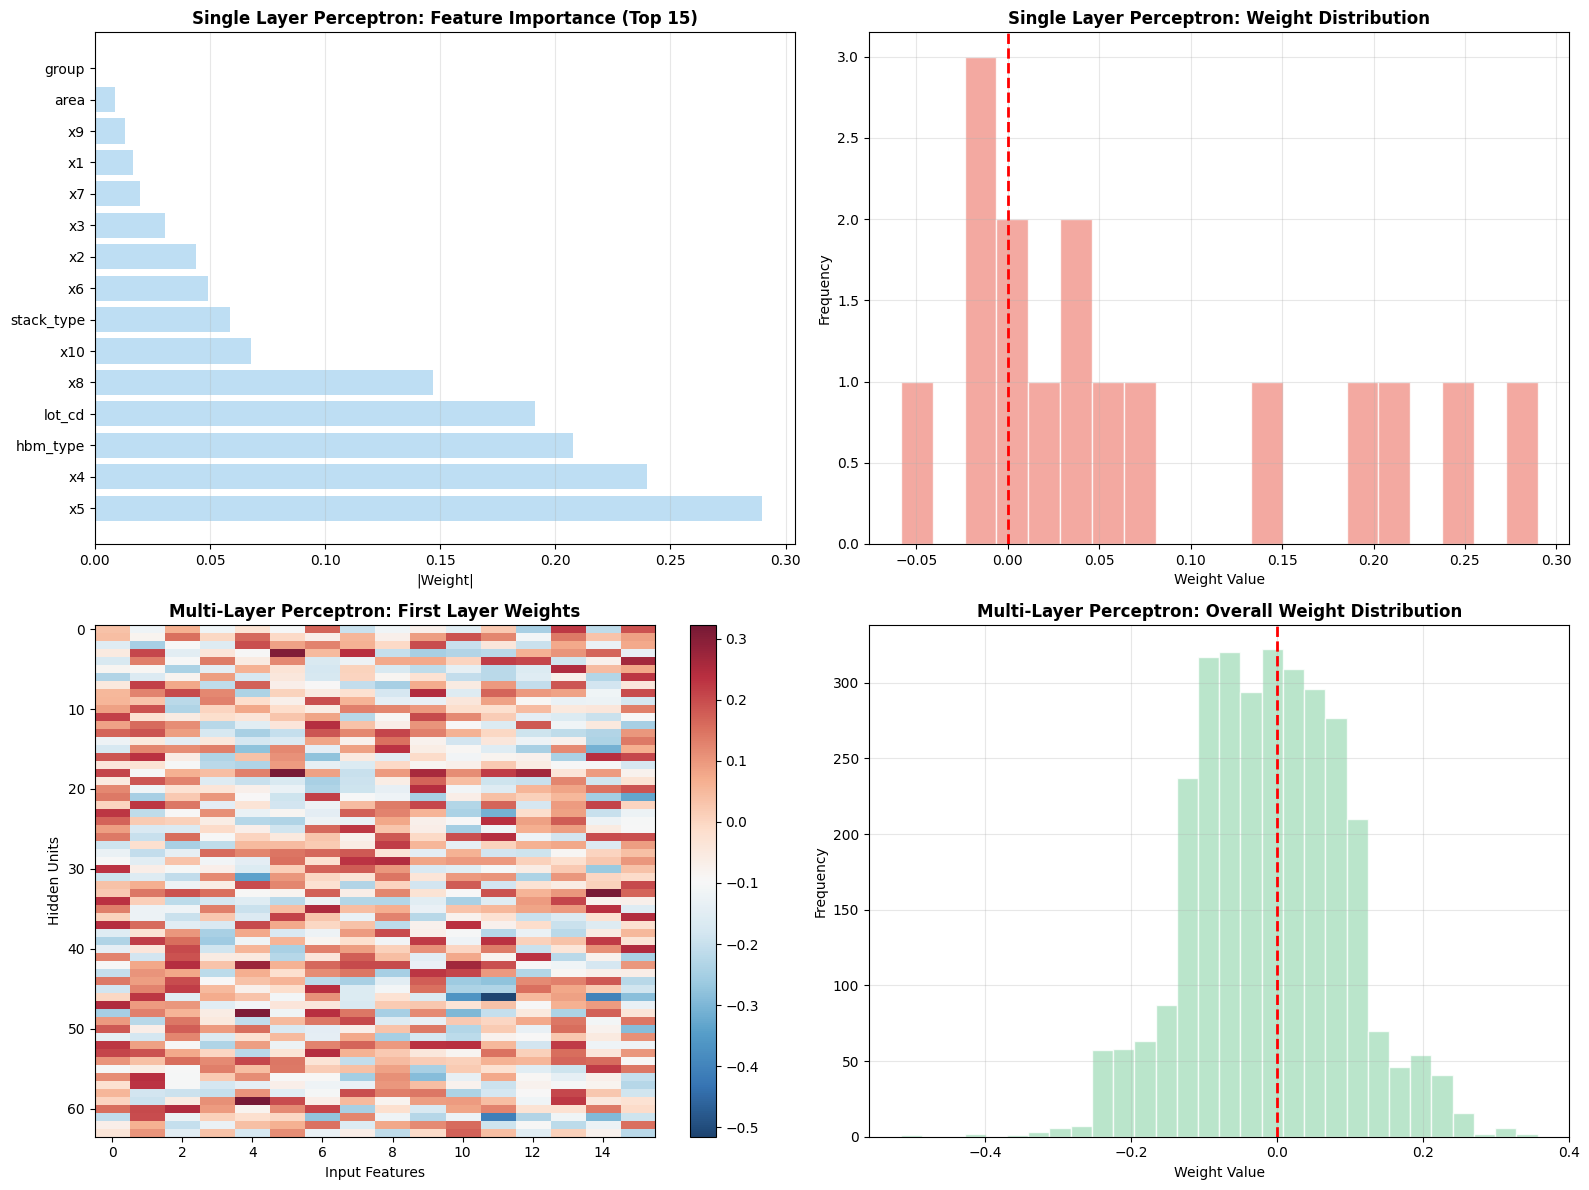

In [40]:
# ======================================================================
# 모델별 파라미터 분석
# ======================================================================

print("="*50)
print(f"🔍 모델별 파라미터 분석")
print("="*50)

# 단층 퍼셉트론 가중치 분석
slp_weights, slp_bias = slp_model.get_weights_bias()
slp_weights = slp_weights.cpu().numpy().flatten()
slp_bias = slp_bias.cpu().numpy()[0]

print(f"🎯 단층 퍼셉트론 학습된 파라미터:")
print(f"{'특성':<20} {'가중치':<12}")
print("-" * 35)

for i, (feature, weight) in enumerate(zip(all_features[:min(10, len(all_features))], slp_weights[:10])):
    print(f"{feature:<20} {weight:<12.4f}")
if len(all_features) > 10:
    print(f"... (총 {len(all_features)}개 특성)")
print(f"{'Bias':<20} {slp_bias:<12.4f}")

# 다층 퍼셉트론 층별 가중치 분석
print(f"\n🧠 다층 퍼셉트론 층별 가중치 통계:")
print(f"{'층':<15} {'평균':<12} {'표준편차':<12} {'최소값':<12} {'최대값':<12}")
print("-" * 65)

for name, module in mlp_model.named_modules():
    if isinstance(module, nn.Linear):
        weights = module.weight.data.cpu().numpy()
        print(f"{name:<15} {np.mean(weights):<12.4f} {np.std(weights):<12.4f} "
              f"{np.min(weights):<12.4f} {np.max(weights):<12.4f}")

# 가중치 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 단층 퍼셉트론 가중치 중요도
abs_weights = np.abs(slp_weights)
sorted_indices = np.argsort(abs_weights)[::-1][:15]  # 상위 15개만

axes[0,0].barh(range(len(sorted_indices)), abs_weights[sorted_indices],
               color=pastel_colors['blue'], alpha=0.8)
axes[0,0].set_yticks(range(len(sorted_indices)))
axes[0,0].set_yticklabels([all_features[i] for i in sorted_indices])
axes[0,0].set_title('Single Layer Perceptron: Feature Importance (Top 15)', fontweight='bold')
axes[0,0].set_xlabel('|Weight|')
axes[0,0].grid(True, alpha=0.3, axis='x')

# 2. 단층 퍼셉트론 가중치 분포
axes[0,1].hist(slp_weights, bins=20, color=pastel_colors['coral'], alpha=0.8, edgecolor='white')
axes[0,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Single Layer Perceptron: Weight Distribution', fontweight='bold')
axes[0,1].set_xlabel('Weight Value')
axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# 3. 다층 퍼셉트론 첫 번째 층 가중치 히트맵
layer1_weights = mlp_model.layer1.weight.data.cpu().numpy()
im = axes[1,0].imshow(layer1_weights, cmap='RdBu_r', aspect='auto', alpha=0.9)
axes[1,0].set_title('Multi-Layer Perceptron: First Layer Weights', fontweight='bold')
axes[1,0].set_xlabel('Input Features')
axes[1,0].set_ylabel('Hidden Units')
plt.colorbar(im, ax=axes[1,0])

# 4. 다층 퍼셉트론 모든 층 가중치 분포
all_mlp_weights = []
for name, module in mlp_model.named_modules():
    if isinstance(module, nn.Linear):
        weights = module.weight.data.cpu().numpy().flatten()
        all_mlp_weights.extend(weights)

axes[1,1].hist(all_mlp_weights, bins=30, color=pastel_colors['green'], alpha=0.8, edgecolor='white')
axes[1,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Multi-Layer Perceptron: Overall Weight Distribution', fontweight='bold')
axes[1,1].set_xlabel('Weight Value')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.6 모델 평가

In [41]:
# ======================================================================
# 모델별 평가 및 예측 비교
# ======================================================================

print("="*50)
print(f"📈 모델별 평가 및 예측 비교")
print("="*50)

"""모델 평가 함수"""
def evaluate_model(model, test_loader):

    predictions, targets = [], []
    model.eval()

    with torch.no_grad():
        # Test 예측
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            pred = model(batch_x).squeeze().cpu().numpy()
            target = batch_y.squeeze().cpu().numpy()
            predictions.extend(pred)
            targets.extend(target)

    # NumPy 배열로 변환
    for split in predictions:
        predictions = np.array(predictions)
        targets = np.array(targets)

    mse = mean_squared_error(targets, predictions)
    mae = mean_absolute_error(targets, predictions)
    r2 = r2_score(targets, predictions)
    rmse = np.sqrt(mse)

    print(f"   Test evaluation metric:")
    print(f"     MSE:  {mse:.6f}")
    print(f"     RMSE: {rmse:.6f}")
    print(f"     MAE:  {mae:.6f}")
    print(f"     R2:   {r2:.6f}")

    metric = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

    return predictions, targets, metric


# 각 모델 평가
print(f"🎯 단층 퍼셉트론 최종 성능 평가:")
slp_predictions, slp_targets, slp_metric = evaluate_model(slp_model, test_loader)

print(f"\n🧠 다층 퍼셉트론 최종 성능 평가:")
mlp_predictions, mlp_targets, mlp_metric = evaluate_model(mlp_model, test_loader)

📈 모델별 평가 및 예측 비교
🎯 단층 퍼셉트론 최종 성능 평가:
   Test evaluation metric:
     MSE:  0.806937
     RMSE: 0.898297
     MAE:  0.499260
     R2:   0.254306

🧠 다층 퍼셉트론 최종 성능 평가:
   Test evaluation metric:
     MSE:  1.076719
     RMSE: 1.037650
     MAE:  0.618154
     R2:   0.005000


🎨 예측 결과 비교 시각화


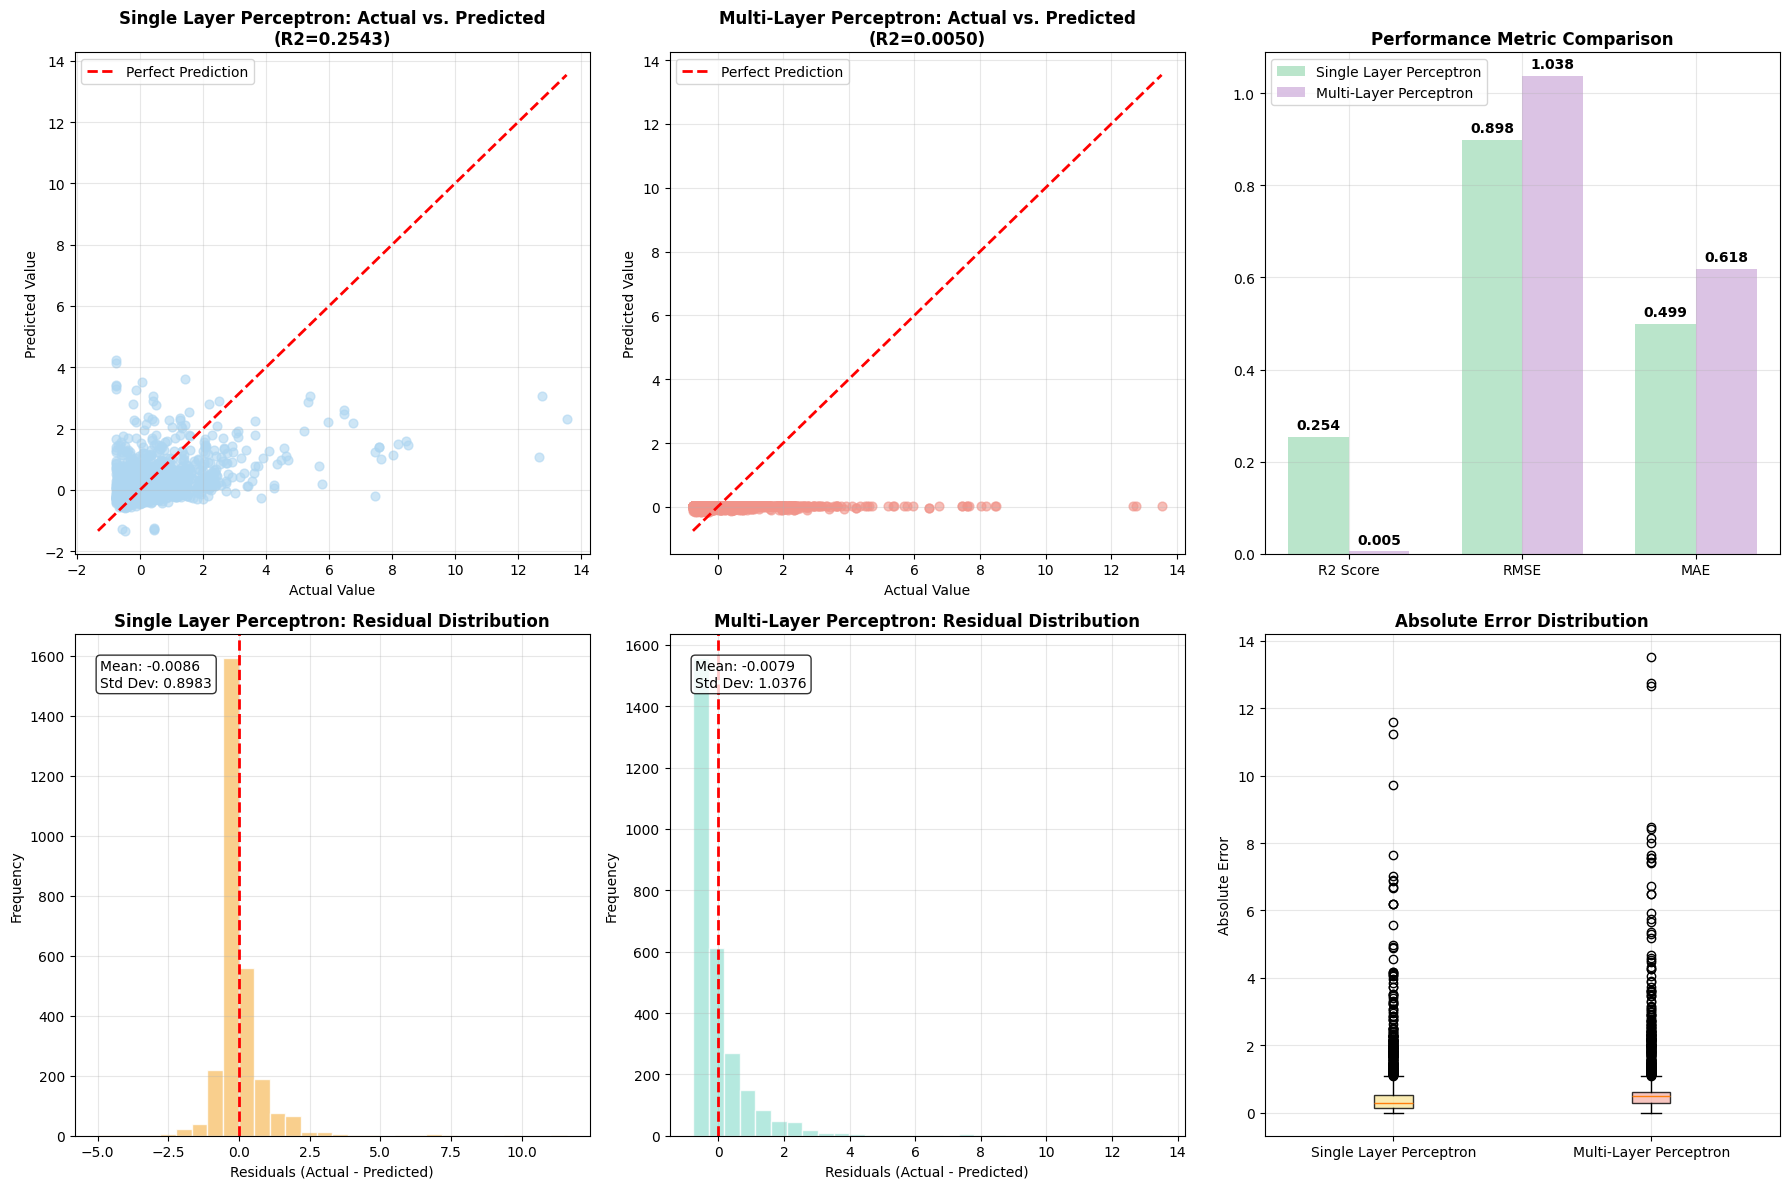


📊 잔차 분석 요약:
모델              잔차 평균        잔차 표준편차         MAE       
-------------------------------------------------------
단층 퍼셉트론         -0.008634    0.898255        0.499260  
다층 퍼셉트론         -0.007860    1.037621        0.618154  


In [42]:
# ======================================================================
# 예측 결과 비교 시각화
# ======================================================================

print("="*50)
print(f"🎨 예측 결과 비교 시각화")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Actual vs. Predicted (Single Layer Perceptron)
axes[0,0].scatter(slp_targets, slp_predictions, color=pastel_colors['blue'], alpha=0.6, s=40)
min_val = min(slp_targets.min(), slp_predictions.min())
max_val = max(slp_targets.max(), slp_predictions.max())
axes[0,0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0,0].set_title(f'Single Layer Perceptron: Actual vs. Predicted\n(R2={slp_metric["R2"]:.4f})', fontweight='bold')
axes[0,0].set_xlabel('Actual Value')
axes[0,0].set_ylabel('Predicted Value')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Actual vs. Predicted (Multi-Layer Perceptron)
axes[0,1].scatter(mlp_targets, mlp_predictions, color=pastel_colors['coral'], alpha=0.6, s=40)
min_val = min(mlp_targets.min(), mlp_predictions.min())
max_val = max(mlp_targets.max(), mlp_predictions.max())
axes[0,1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0,1].set_title(f'Multi-Layer Perceptron: Actual vs. Predicted\n(R2={mlp_metric["R2"]:.4f})', fontweight='bold')
axes[0,1].set_xlabel('Actual Value')
axes[0,1].set_ylabel('Predicted Value')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Performance Metric Comparison (Bar Chart)
metrics = ['R2', 'RMSE', 'MAE']
slp_values = [slp_metric['R2'], slp_metric['RMSE'], slp_metric['MAE']]
mlp_values = [mlp_metric['R2'], mlp_metric['RMSE'], mlp_metric['MAE']]

x_pos = np.arange(len(metrics))
width = 0.35

bars1 = axes[0,2].bar(x_pos - width/2, slp_values, width, label='Single Layer Perceptron',
                     color=pastel_colors['green'], alpha=0.8)
bars2 = axes[0,2].bar(x_pos + width/2, mlp_values, width, label='Multi-Layer Perceptron',
                     color=pastel_colors['purple'], alpha=0.8)

# 막대 위에 값 표시
for i, (slp_val, mlp_val) in enumerate(zip(slp_values, mlp_values)):
    axes[0,2].text(i - width/2, slp_val + (max(slp_values + mlp_values) * 0.01),
                  f'{slp_val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    axes[0,2].text(i + width/2, mlp_val + (max(slp_values + mlp_values) * 0.01),
                  f'{mlp_val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

axes[0,2].set_title('Performance Metric Comparison', fontweight='bold')
axes[0,2].set_xticks(x_pos)
axes[0,2].set_xticklabels(['R2 Score', 'RMSE', 'MAE'])
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Residual Distribution (Single Layer Perceptron)
slp_residuals = slp_targets - slp_predictions
axes[1,0].hist(slp_residuals, bins=30, color=pastel_colors['orange'], alpha=0.8, edgecolor='white')
axes[1,0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('Single Layer Perceptron: Residual Distribution', fontweight='bold')
axes[1,0].set_xlabel('Residuals (Actual - Predicted)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].grid(True, alpha=0.3)

# 잔차 통계 표시
slp_residual_mean = np.mean(slp_residuals)
slp_residual_std = np.std(slp_residuals)
axes[1,0].text(0.05, 0.95, f'Mean: {slp_residual_mean:.4f}\nStd Dev: {slp_residual_std:.4f}',
              transform=axes[1,0].transAxes, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 5. Residual Distribution (Multi-Layer Perceptron)
mlp_residuals = mlp_targets - mlp_predictions
axes[1,1].hist(mlp_residuals, bins=30, color=pastel_colors['mint'], alpha=0.8, edgecolor='white')
axes[1,1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Multi-Layer Perceptron: Residual Distribution', fontweight='bold')
axes[1,1].set_xlabel('Residuals (Actual - Predicted)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

# 잔차 통계 표시
mlp_residual_mean = np.mean(mlp_residuals)
mlp_residual_std = np.std(mlp_residuals)
axes[1,1].text(0.05, 0.95, f'Mean: {mlp_residual_mean:.4f}\nStd Dev: {mlp_residual_std:.4f}',
              transform=axes[1,1].transAxes, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 6. Absolute Error Distribution
slp_abs_errors = np.abs(slp_residuals)
mlp_abs_errors = np.abs(mlp_residuals)

bp = axes[1,2].boxplot([slp_abs_errors, mlp_abs_errors],
                      labels=['Single Layer Perceptron', 'Multi-Layer Perceptron'],
                      patch_artist=True)

# 박스 색상 수동 설정
colors = [pastel_colors['yellow'], pastel_colors['pink']]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1,2].set_title('Absolute Error Distribution', fontweight='bold')
axes[1,2].set_ylabel('Absolute Error')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 잔차 분석 요약
print(f"\n📊 잔차 분석 요약:")
print(f"{'모델':<15} {'잔차 평균':<12} {'잔차 표준편차':<15} {'MAE':<10}")
print("-" * 55)
print(f"{'단층 퍼셉트론':<15} {slp_residual_mean:<12.6f} {slp_residual_std:<15.6f} {slp_metric['MAE']:<10.6f}")
print(f"{'다층 퍼셉트론':<15} {mlp_residual_mean:<12.6f} {mlp_residual_std:<15.6f} {mlp_metric['MAE']:<10.6f}")